## Analysis of Results

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Any, List
import pandas as pd
import numpy as np
import yaml
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter


In [2]:
# Global matplotlib settings
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['savefig.format'] = 'png'
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['font.size'] = 12.5
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12.5
mpl.rcParams['ytick.labelsize'] = 12.5
mpl.rcParams['legend.fontsize'] = 12.5
mpl.rcParams['figure.titlesize'] = 16
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['grid.linewidth'] = 0.8
mpl.rcParams['lines.linewidth'] = 2.0

# Font sizes dictionary for easy reference
FONT_SIZES = {
    'title': 16,
    'axis_label': 14,
    'tick_label': 12.5,
    'legend': 12.5,
    'annotation': 12,
    'zone_label': 14,
}

# Figure sizes (width, height in inches)
FIGSIZE_STANDARD = (10, 6)  # Standard wide plot
FIGSIZE_LARGE = (12, 6)     # Larger plots with more detail
FIGSIZE_TALL = (10, 8)      # Plots needing more vertical space

print("✓ figure settings loaded")
print(f"  - DPI: {mpl.rcParams['figure.dpi']}")
print(f"  - Default format: {mpl.rcParams['savefig.format']}")
print(f"  - Font family: {mpl.rcParams['font.family']}")

✓ figure settings loaded
  - DPI: 300.0
  - Default format: png
  - Font family: ['serif']


Info about scenario

In [3]:
# Policy name mapping 
POLICY_NAME_MAP = {
    "eom": "EOM-ref",
    "pricecap": "EOM-cap",
    "NoCBP": "CM-NoCBP",
    "FBMC": "CM-FBMC",
    "NTC": "CM-NTC",
    "implicit": "CM-Implicit"
}

def map_policy_name(design_key: str) -> str:
    """Convert internal design key to display name"""
    return POLICY_NAME_MAP.get(design_key, design_key)

def map_policy_names(design_list: list) -> list:
    """Convert list of design keys to display names"""
    return [POLICY_NAME_MAP.get(d, d) for d in design_list]

#### Data extraction

In [4]:
# pip install pyyaml pandas numpy matplotlib scipy

In [5]:
# change name of policies in plots to be more descriptive
# POLICY_NAME_MAP = {EOM-ref, EOM-cap, CM-NoCBP, CM-FBMC, CM-NTC, CM-Implicit}

In [6]:
def read_inputs(base_dir: str | Path) -> Dict[str, Any]:
    base_dir = Path(base_dir)
    inp = base_dir / "Input"
    # Load parameters from YAML config
    with open(inp / "config.yaml", "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    H = int(data["General"]["nTimesteps"])

    # Load input files
    load = pd.read_csv(inp / "load.csv", sep=";")
    pv = pd.read_csv(inp / "pv.csv", sep=";")
    wind_on = pd.read_csv(inp / "wind_onshore.csv", sep=";")
    nptdf = pd.read_csv(inp / "nodal_ptdf.csv", sep=";")
    lines = pd.read_csv(inp / "lines.csv", sep=";")
    scarcity_df = pd.read_csv(inp / "scarcity.csv", sep=";")

    # Load weights from new format (zone-specific weights)
    weights_path = inp / "weights.csv"
    weights_dict = {}
    if weights_path.is_file():
        df_w = pd.read_csv(weights_path, sep=";")  # Remove index_col=0
        # Store weights for each zone
        for zone in ["A", "B", "C"]:
            if zone in df_w.columns:
                W = df_w[zone].astype(float).to_numpy()[:H]
                if W.size < H:
                    W = np.pad(W, (0, H - W.size), mode="constant", constant_values=1.0)
                weights_dict[zone] = W
            else:
                print(f"Zone {zone} not found in weights file. Using uniform weights.")
                weights_dict[zone] = np.ones(H)
    else:
        # Fallback to uniform weights
        print("Weights file not found. Using uniform weights for all zones.")
        for zone in ["A", "B", "C"]:
            weights_dict[zone] = np.ones(H)

    return {
        "data": data,
        "load": load,
        "pv": pv,
        "wind_on": wind_on,
        "nptdf": nptdf,
        "lines": lines,
        "weights": weights_dict,
        "scarcity": scarcity_df,
    }


if __name__ == "__main__":
    inputs = read_inputs(Path().resolve())
    print(inputs.keys())
# print(inputs["load"][:5])
print("Zone A weights:", inputs["weights"]["A"][:5])
print("Zone B weights:", inputs["weights"]["B"][:5])
print("Zone C weights:", inputs["weights"]["C"][:5])


dict_keys(['data', 'load', 'pv', 'wind_on', 'nptdf', 'lines', 'weights', 'scarcity'])
Zone A weights: [420. 419. 416. 416. 416.]
Zone B weights: [420. 419. 416. 416. 416.]
Zone C weights: [420. 419. 416. 416. 416.]


In [7]:
# Load analysis data
def load_analysis_data(base_dir: str | Path) -> Dict[str, pd.DataFrame]:
    base_dir = Path(base_dir)
    analysis_dir = base_dir / "analysis_data"
    categories = ["eom", "explicit_FBMC", "explicit_NTC", "implicit", "pricecap", "NoCBP"]
    data = {}

    for category in categories:
        category_path = analysis_dir / category
        if category_path.is_dir():
            for file in category_path.glob("*.csv"):
                key = f"{file.stem}"
                data[key] = pd.read_csv(file, sep=";")
    return data

if __name__ == "__main__":
    analysis_data = load_analysis_data(Path().resolve())
    print(analysis_data.keys())
    
analysis_data["planner_zone_A_eom"][:5]

dict_keys(['mcp_zone_A_eom', 'mcp_zone_B_eom', 'mcp_zone_C_eom', 'planner_zone_A_eom', 'planner_zone_B_eom', 'planner_zone_C_eom', 'mcp_zone_A_FBMC', 'mcp_zone_B_FBMC', 'mcp_zone_C_FBMC', 'planner_zone_A_FBMC', 'planner_zone_B_FBMC', 'planner_zone_C_FBMC', 'mcp_zone_A_NTC', 'mcp_zone_B_NTC', 'mcp_zone_C_NTC', 'planner_zone_A_NTC', 'planner_zone_B_NTC', 'planner_zone_C_NTC', 'mcp_zone_A_implicit', 'mcp_zone_B_implicit', 'mcp_zone_C_implicit', 'planner_zone_A_implicit', 'planner_zone_B_implicit', 'planner_zone_C_implicit', 'mcp_zone_A_pricecap', 'mcp_zone_B_pricecap', 'mcp_zone_C_pricecap', 'planner_zone_A_pricecap', 'planner_zone_B_pricecap', 'planner_zone_C_pricecap', 'mcp_zone_A_NoCBP', 'mcp_zone_B_NoCBP', 'mcp_zone_C_NoCBP', 'planner_zone_A_NoCBP', 'planner_zone_B_NoCBP', 'planner_zone_C_NoCBP'])


,Timestep,EOM_price,Gen_A_Baseload,new_Capacity_Gen_A_Baseload,Capacity_Gen_A_Baseload,Gen_A_MidMerit,new_Capacity_Gen_A_MidMerit,Capacity_Gen_A_MidMerit,Gen_A_PV,new_Capacity_Gen_A_PV,...,new_Capacity_Gen_A_Peak,Capacity_Gen_A_Peak,Gen_A_WindOnshore,new_Capacity_Gen_A_WindOnshore,Capacity_Gen_A_WindOnshore,Cons_A,Inelastic_Cons_A,Elastic_Cons_A,NetworkManager,ENS_Cons_A
0,1.0,84.74,6979.28,6979.28,6979.28,929.23,1510.78,1510.78,0.0,0.0,...,3654.51,3654.51,886.06,0.0,13700.0,8735.16,6994.06,1741.11,-59.40,0.0
1,2.0,74.87,6859.30,6979.28,6979.28,621.07,1510.78,1510.78,0.0,0.0,...,3654.51,3654.51,1010.89,0.0,13700.0,8537.05,6834.75,1702.29,45.78,0.0
2,3.0,72.69,6585.81,6979.28,6979.28,552.70,1510.78,1510.78,0.0,0.0,...,3654.51,3654.51,1138.92,0.0,13700.0,8563.05,6855.43,1707.63,285.62,0.0
3,4.0,71.43,6429.02,6979.28,6979.28,513.51,1510.78,1510.78,0.0,0.0,...,3654.51,3654.51,1277.63,0.0,13700.0,8729.52,6988.60,1740.91,509.36,0.0
4,5.0,71.30,6412.11,6979.28,6979.28,509.28,1510.78,1510.78,0.0,0.0,...,3654.51,3654.51,1465.21,0.0,13700.0,9188.09,7355.72,1832.37,801.49,0.0


#### Capacity plots

In [8]:
# select either "planner" or "mcp" data by changing the key construction below
def extract_total_planner_capacity(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]

    records = []
    for design_key in design_keys:
        for zone in zones:
            # Construct the key
            key = f"planner_zone_{zone}_{design_key}"
            if key not in data:
                print(f"Key not found: {key}")  # Debugging statement
                continue
            df = data[key]
            row = {"Zone": zone, "Design": design_key}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                row[g] = df[col].iloc[0] if col in df.columns else 0  # Use the first value
            records.append(row)

        # Add "Com" (combined)
        total = {"Zone": "Com", "Design": design_key}
        for g in gen_types:
            total[g] = sum(r[g] for r in records if r["Design"] == design_key)
        records.append(total)

    return pd.DataFrame(records)

In [9]:
installed_capacity_planner = extract_total_planner_capacity(analysis_data)
# print(installed_capacity)

# add a sum to the installed capacity dataframe
installed_capacity_planner_sum = installed_capacity_planner.copy()
installed_capacity_planner_sum['Total'] = installed_capacity_planner_sum[['Baseload', 'MidMerit', 'Peak']].sum(axis=1)
print(installed_capacity_planner_sum)

   Zone    Design  Baseload  MidMerit      Peak     Total
0     A       eom   6979.28   1510.78   3654.51  12144.57
1     B       eom   6979.28   1510.78   3654.51  12144.57
2     C       eom   6979.28   1510.78   5189.52  13679.58
3   Com       eom  20937.84   4532.34  12498.54  37968.72
4     A      FBMC   6980.94   1514.05   7656.67  16151.66
5     B      FBMC   6980.94   1514.05   6214.97  14709.96
6     C      FBMC   6980.94   1514.05   8398.23  16893.22
7   Com      FBMC  20942.82   4542.15  22269.87  47754.84
8     A       NTC   6980.94   1514.05   9187.00  17681.99
9     B       NTC   6980.94   1514.05   6768.25  15263.24
10    C       NTC   6980.94   1514.05   8828.03  17323.02
11  Com       NTC  20942.82   4542.15  24783.28  50268.25
12    A  implicit   6961.00   1500.78   3479.55  11941.33
13    B  implicit   7005.87   1528.76   5560.10  14094.73
14    C  implicit   6974.10   1508.95   5622.29  14105.34
15  Com  implicit  20940.97   4538.49  14661.94  40141.40
16    A  price

In [10]:
# select either "planner" or "mcp" data by changing the key construction below
def extract_total_capacity(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]

    records = []
    for design_key in design_keys:
        for zone in zones:
            # Construct the key
            key = f"mcp_zone_{zone}_{design_key}"
            if key not in data:
                print(f"Key not found: {key}")  # Debugging statement
                continue
            df = data[key]
            row = {"Zone": zone, "Design": design_key}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                row[g] = df[col].iloc[0] if col in df.columns else 0  # Use the first value
            records.append(row)

        # Add "Com" (combined)
        total = {"Zone": "Com", "Design": design_key}
        for g in gen_types:
            total[g] = sum(r[g] for r in records if r["Design"] == design_key)
        records.append(total)

    return pd.DataFrame(records)

In [11]:
installed_capacity = extract_total_capacity(analysis_data)
# print(installed_capacity)

# add a sum to the installed capacity dataframe
installed_capacity_sum = installed_capacity.copy()
installed_capacity_sum['Total'] = installed_capacity_sum[['Baseload', 'MidMerit', 'Peak']].sum(axis=1)
print(installed_capacity_sum)

   Zone    Design      Baseload     MidMerit          Peak         Total
0     A       eom   6853.401116  1428.716521   4034.687235  12316.804872
1     B       eom   6847.471393  1427.782222   4033.905598  12309.159212
2     C       eom   6848.773458  1427.986373   4033.980585  12310.740416
3   Com       eom  20549.645966  4284.485117  12102.573417  36936.704500
4     A      FBMC   6854.987922  1431.256870   8966.967779  17253.212571
5     B      FBMC   6847.742823  1430.107352   5723.338009  14001.188184
6     C      FBMC   6851.336711  1430.683445   8218.382792  16500.402949
7   Com      FBMC  20554.067456  4292.047667  22908.688581  47754.803704
8     A       NTC   6854.696750  1431.233156   8273.840789  16559.770696
9     B       NTC   6847.769326  1430.102948   5719.279379  13997.151653
10    C       NTC   6851.559795  1430.741694   8915.543227  17197.844717
11  Com       NTC  20554.025872  4292.077799  22908.663395  47754.767066
12    A  implicit   6831.747264  1418.505833   3691

In [12]:
def extract_capacity_changes(df: pd.DataFrame, ref_design="eom") -> pd.DataFrame:
    zones = ["A", "B", "C", "Com"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    deltas = []

    base_df = df[df["Design"] == ref_design]

    for design in df["Design"].unique():
        if design == ref_design:
            continue
        for zone in zones:
            base = base_df[(base_df["Zone"] == zone)]
            current = df[(df["Zone"] == zone) & (df["Design"] == design)]
            delta = {"Zone": zone, "Design": design}
            for g in gen_types:
                base_val = base[g].values[0] if not base.empty else 0
                curr_val = current[g].values[0] if not current.empty else 0
                delta[g] = curr_val - base_val
            deltas.append(delta)

    return pd.DataFrame(deltas)

In [13]:
def plot_capacity_bars(df: pd.DataFrame, ylabel: str):
    zones = ["A", "B", "C", "Com"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    # colors = {"Baseload": "royalblue", "MidMerit": "green", "Peak": "mediumpurple"}
    colors = {
        "Baseload": "#0072B2",         # Dark Blue
        "MidMerit": "#009E73",         # Bluish-Green
        "Peak": "#CC79A7",             # Rose
    }
    
    # Spacing configuration
    group_gap = 1.5  # Gap between design groups (adjust as needed)
    
    # Prepare data with custom x-positions
    x_labels = []
    data = {g: [] for g in gen_types}
    x_positions = []
    
    # Calculate positions with gaps between design groups
    pos = 0
    for design in design_order:
        design_start_pos = pos
        for zone in zones:
            x_positions.append(pos)
            x_labels.append(f"{zone}")
            subset = df[(df["Design"] == design) & (df["Zone"] == zone)]
            for g in gen_types:
                val = subset[g].values[0] if not subset.empty else 0
                data[g].append(val)
            pos += 1
        
        # Add extra space after each design group (except the last)
        if design != design_order[-1]:
            pos += group_gap
    
    width = 0.6
    bottom = np.zeros(len(x_labels))

    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    for g in gen_types:
        ax.bar(x_positions, data[g], width, label=g, bottom=bottom, color=colors[g])
        bottom += np.array(data[g])

    # Axis setup
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES['axis_label'])
    ax.set_ylim(0, bottom.max() * 1.1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['axis_label'])
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()

    # Format y-axis ticks in GW
    def GW_formatter(x, pos):
        return f'{x/1e3:.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(GW_formatter))
    
    # Add market design labels as text
    for i, design in enumerate(design_order):
        start_idx = i * len(zones)
        if i < len(design_order) - 1:
            midpoint = (x_positions[start_idx] + x_positions[start_idx + len(zones) - 1]) / 2
        else:
            midpoint = (x_positions[start_idx] + x_positions[-1]) / 2
        ax.text(midpoint, -0.1, map_policy_name(design), ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')
    
    # Add vertical separators between market designs (in the gaps)
    for i in range(1, len(design_order)):
        start_idx = i * len(zones)
        separator_pos = (x_positions[start_idx-1] + x_positions[start_idx]) / 2
        ax.axvline(separator_pos, color='gray', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for design labels
    plt.show()

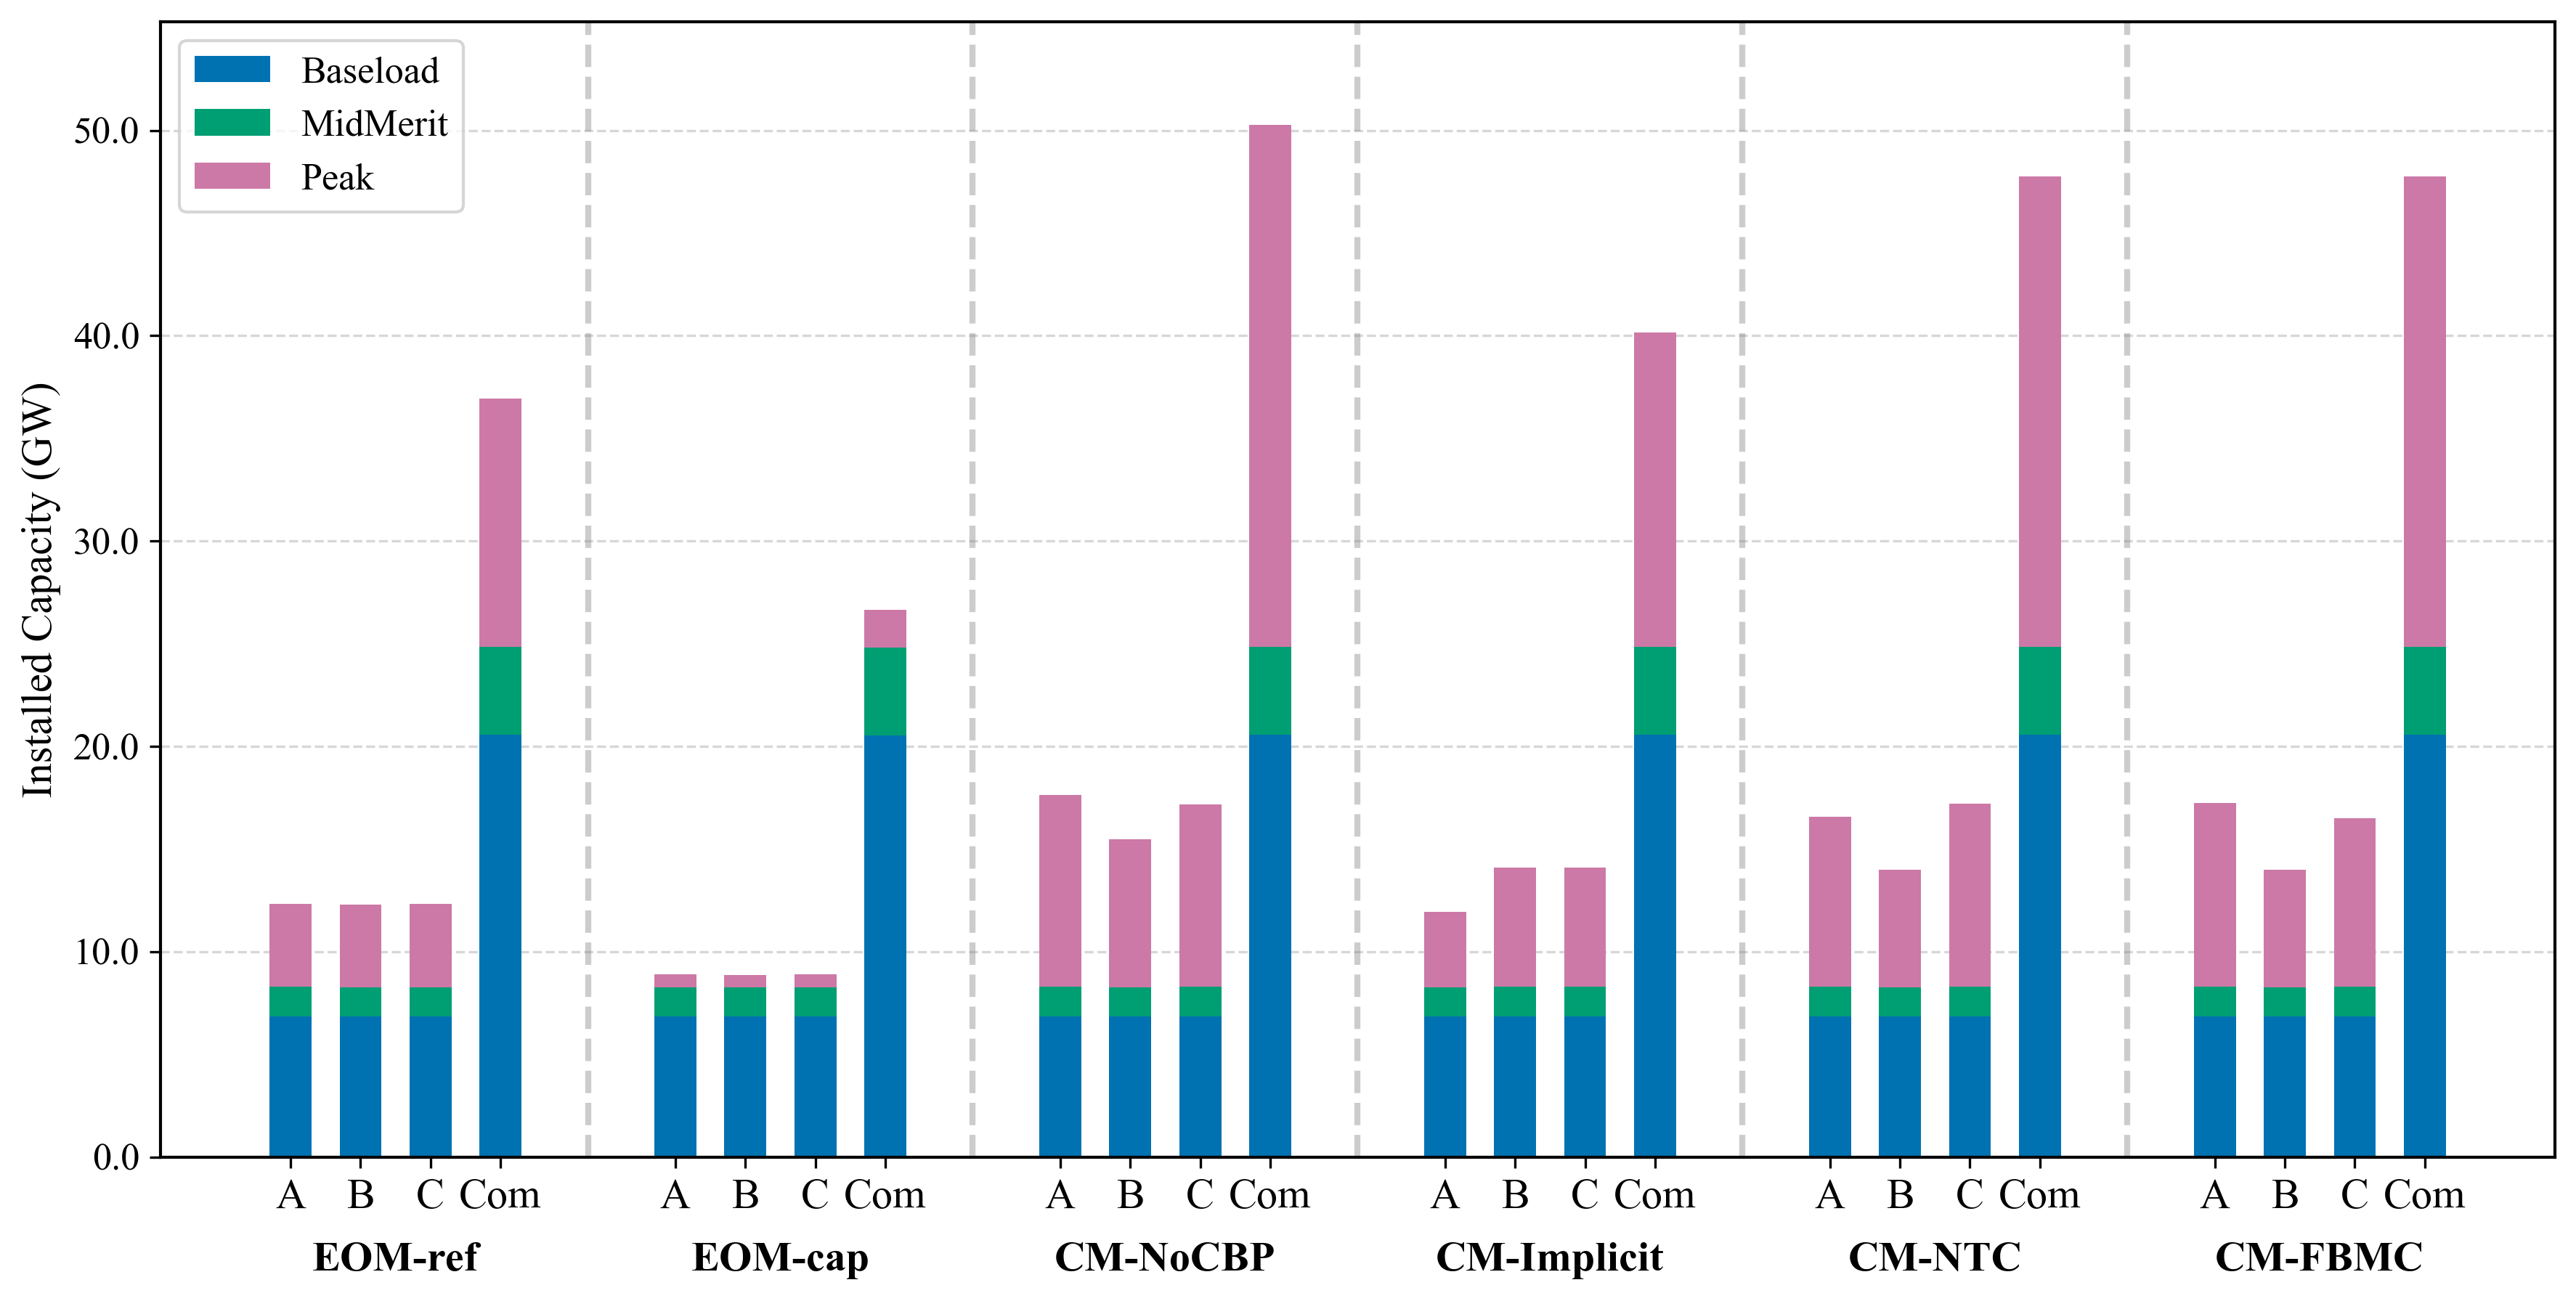

In [14]:
# Extract capacity data
capacity_data = extract_total_capacity(analysis_data)

# Plot total capacity
plot_capacity_bars(capacity_data, "Installed Capacity (GW)")


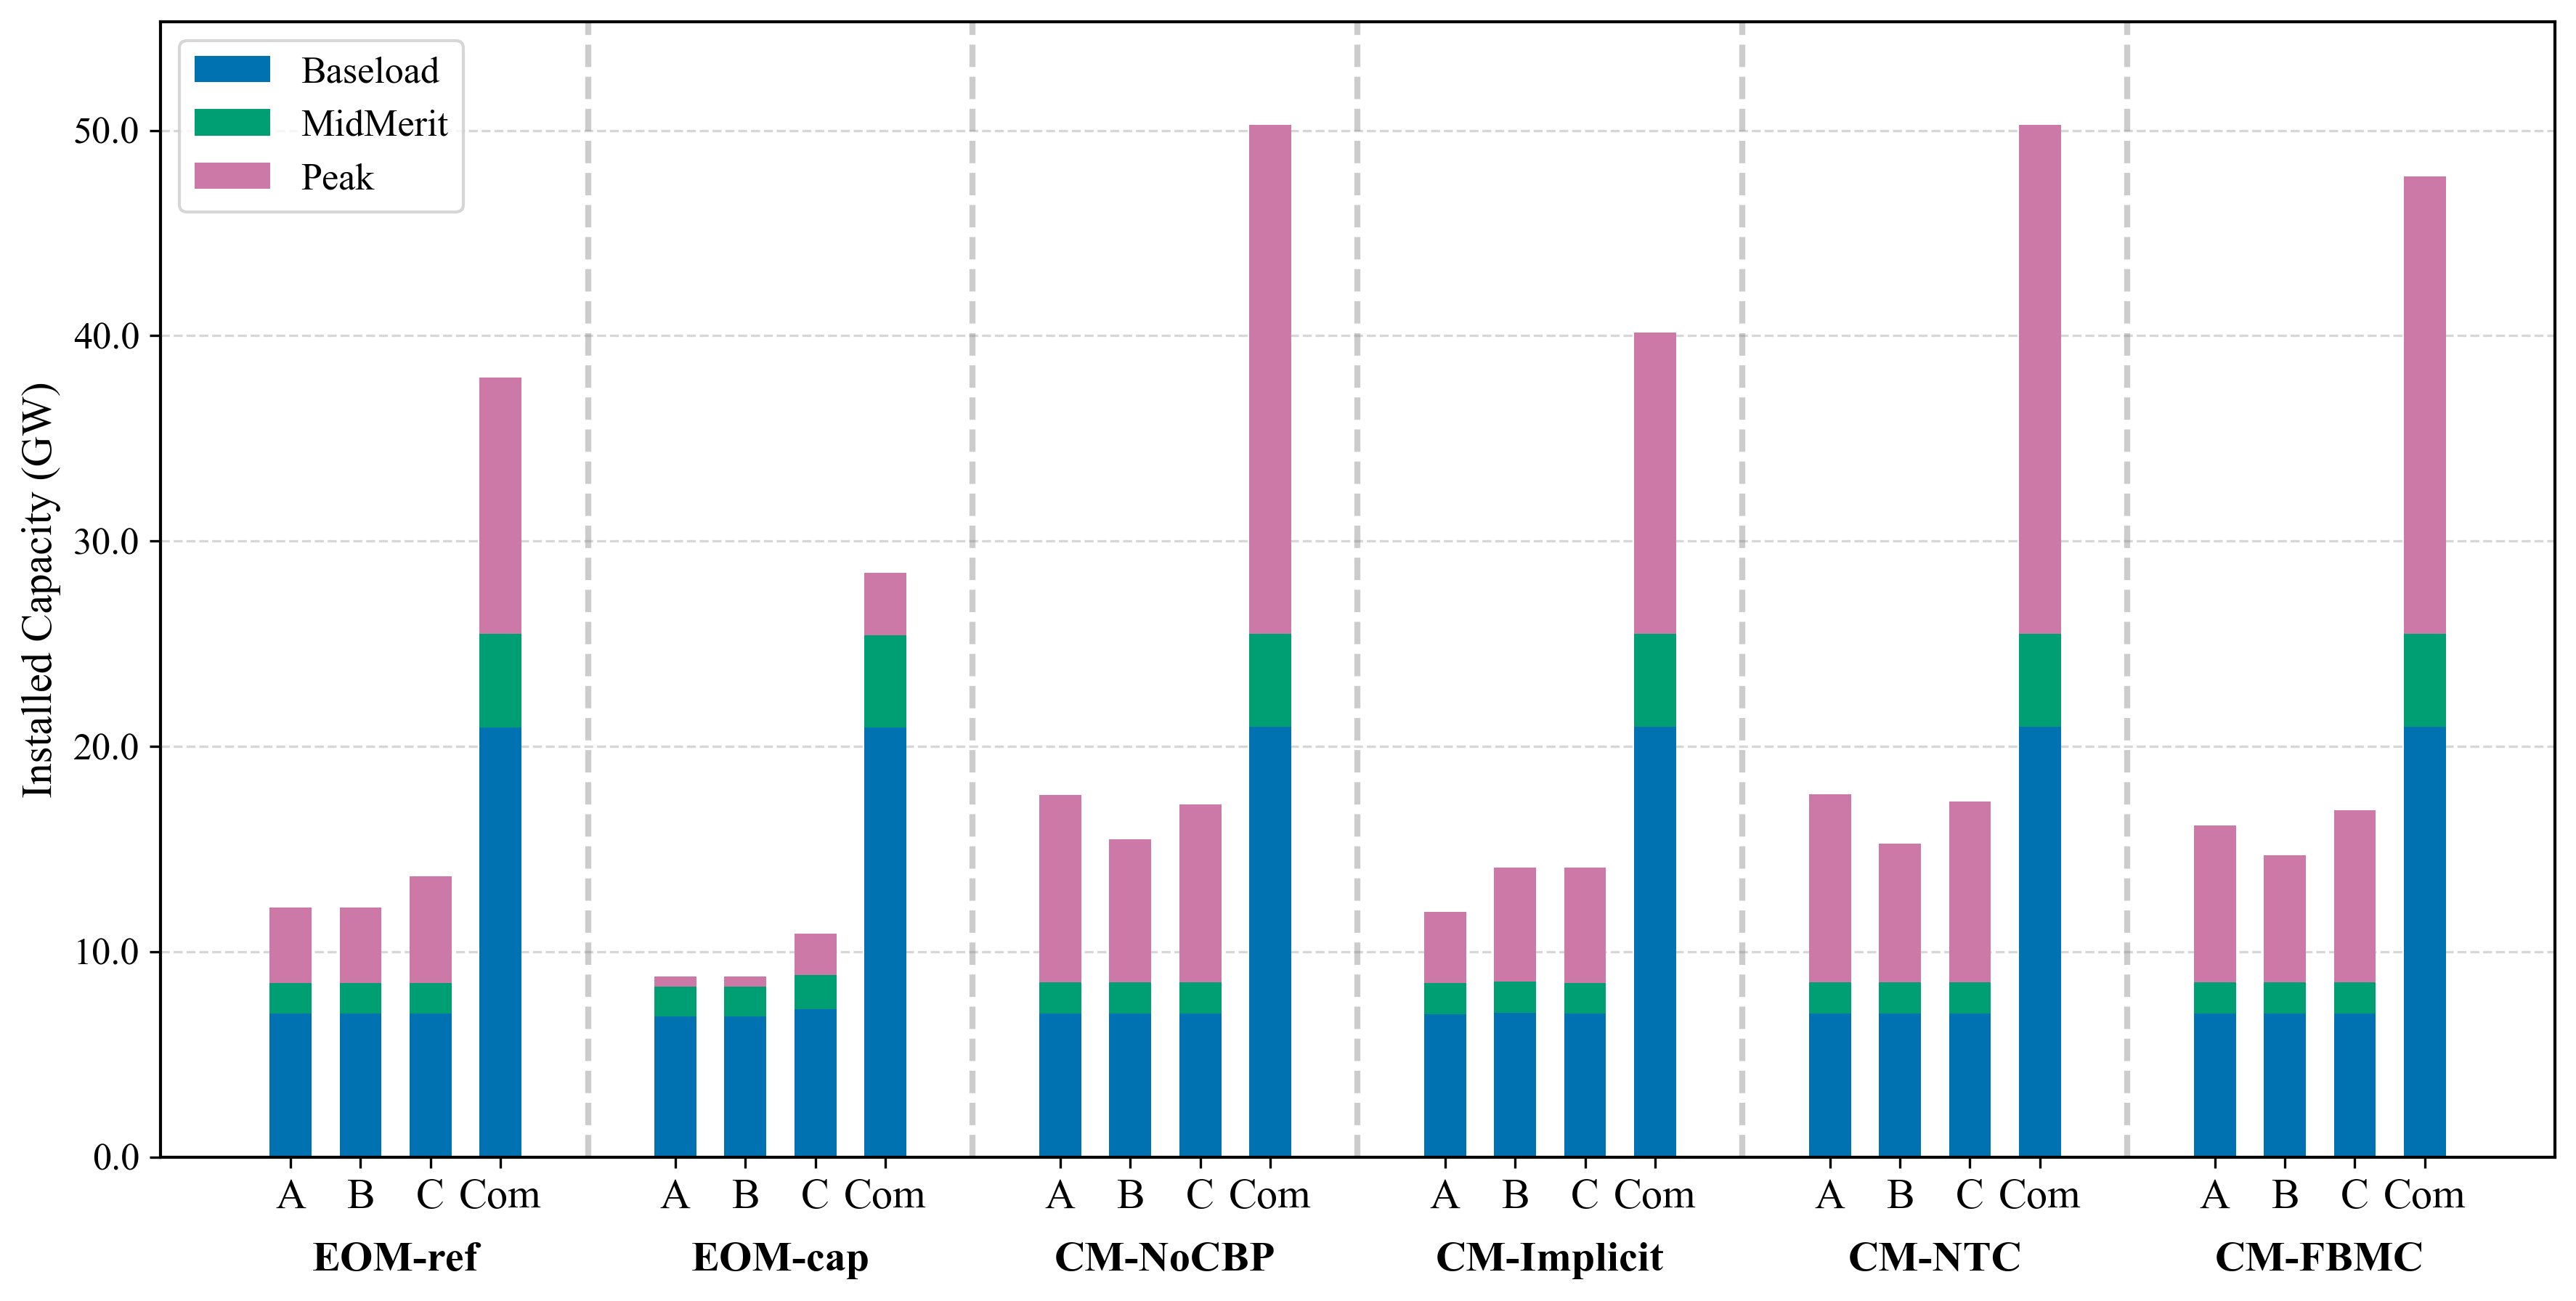

In [15]:
# Extract planner capacity data
planner_capacity_data = extract_total_planner_capacity(analysis_data)
plot_capacity_bars(planner_capacity_data, "Installed Capacity (GW)")

In [16]:
def extract_planner_mcp_diffs(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    zones = ["A", "B", "C"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    design_keys = ["eom", "FBMC", "NTC", "implicit", "pricecap", "NoCBP"]
    
    deltas = []
    
    for design in design_keys:
        for zone in zones:
            planner_key = f"planner_zone_{zone}_{design}"
            mcp_key = f"mcp_zone_{zone}_{design}"
            
            if planner_key not in data or mcp_key not in data:
                print(f"Key not found: {planner_key} or {mcp_key}")
                continue
                
            planner_df = data[planner_key]
            mcp_df = data[mcp_key]
            
            delta = {"Zone": zone, "Design": design}
            for g in gen_types:
                col = f"Capacity_Gen_{zone}_{g}"
                
                planner_val = planner_df[col].iloc[0] if col in planner_df.columns else 0
                mcp_val = mcp_df[col].iloc[0] if col in mcp_df.columns else 0

                delta[g] = mcp_val - planner_val

            deltas.append(delta)
    
    # Add "Com" (combined) for each design
    for design in design_keys:
        design_deltas = [d for d in deltas if d["Design"] == design]
        if not design_deltas:
            continue
            
        com_delta = {"Zone": "Com", "Design": design}
        for g in gen_types:
            com_delta[g] = sum(d[g] for d in design_deltas)
        deltas.append(com_delta)
    
    return pd.DataFrame(deltas)

In [17]:
def plot_cap_bars(df: pd.DataFrame, ylabel: str, allow_negatives=True):
    zones = ["A", "B", "C", "Com"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    # colors = {"Baseload": "royalblue", "MidMerit": "green", "Peak": "mediumpurple"}
    colors = {
        "Baseload": "#0072B2",         # Dark Blue
        "MidMerit": "#009E73",         # Bluish-Green
        "Peak": "#CC79A7",             # Rose
    }
    # Spacing configuration
    group_gap = 1.5  # Gap between design groups (adjust as needed)
    
    # Prepare data with custom x-positions
    x_labels = []
    data = {g: [] for g in gen_types}
    x_positions = []
    
    # Calculate positions with gaps between design groups
    pos = 0
    for design in design_order:
        for zone in zones:
            x_positions.append(pos)
            x_labels.append(f"{zone}")
            subset = df[(df["Design"] == design) & (df["Zone"] == zone)]
            for g in gen_types:
                val = subset[g].values[0] if not subset.empty else 0
                data[g].append(val)
            pos += 1
        
        # Add extra space after each design group (except the last)
        if design != design_order[-1]:
            pos += group_gap
    
    width = 0.6
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    # Handle positive and negative values differently for proper stacking
    if allow_negatives:
        # For data with positive and negative values
        bottom_pos = np.zeros(len(x_labels))
        bottom_neg = np.zeros(len(x_labels))
        
        for g in gen_types:
            data_array = np.array(data[g])
            mask_pos = data_array >= 0
            mask_neg = data_array < 0
            
            # Plot positive values (stack upward)
            ax.bar(np.array(x_positions)[mask_pos], data_array[mask_pos], 
                  width, bottom=bottom_pos[mask_pos], color=colors[g], label=g if g not in ax.get_legend_handles_labels()[1] else "")
            bottom_pos[mask_pos] += data_array[mask_pos]
            
            # Plot negative values (stack downward)
            ax.bar(np.array(x_positions)[mask_neg], data_array[mask_neg], 
                  width, bottom=bottom_neg[mask_neg], color=colors[g])
            bottom_neg[mask_neg] += data_array[mask_neg]
        
        # Calculate proper y-axis limits to show both positive and negative values
        y_max = bottom_pos.max() * 1.1 if bottom_pos.max() > 0 else 1
        y_min = bottom_neg.min() * 1.1 if bottom_neg.min() < 0 else -1
        ax.set_ylim(y_min, y_max)
        
    else:
        # Original implementation for positive-only data
        bottom = np.zeros(len(x_labels))
        for g in gen_types:
            ax.bar(x_positions, data[g], width, label=g, bottom=bottom, color=colors[g])
            bottom += np.array(data[g])
        ax.set_ylim(0, bottom.max() * 1.1)

    # Add zero line if we have negative values
    if allow_negatives:
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

    # Axis setup
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES['axis_label'])
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['axis_label'])
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend()
    
        # Format y-axis ticks in GW
    def GW_formatter(x, pos):
        return f'{x/1e3:.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(GW_formatter))
    
    # Add market design labels as text (adjusted for new spacing)
    for i, design in enumerate(design_order):
        start_idx = i * len(zones)
        if i < len(design_order) - 1:
            midpoint = (x_positions[start_idx] + x_positions[start_idx + len(zones) - 1]) / 2
        else:
            midpoint = (x_positions[start_idx] + x_positions[-1]) / 2
        ax.text(midpoint, -0.1, map_policy_name(design), ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')
    
    # Add vertical separators between market designs (in the gaps)
    for i in range(1, len(design_order)):
        start_idx = i * len(zones)
        separator_pos = (x_positions[start_idx-1] + x_positions[start_idx]) / 2
        ax.axvline(separator_pos, color='gray', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # Make room for design labels
    plt.show()

   Zone    Design   Baseload   MidMerit          Peak
0     A      FBMC   1.586806   2.540349   4932.280544
1     B      FBMC   0.271430   2.325130   1689.432412
2     C      FBMC   2.563254   2.697072   4184.402208
3   Com      FBMC   4.421490   7.562550  10806.115164
4     A       NTC   1.295635   2.516635   4239.153554
5     B       NTC   0.297933   2.320726   1685.373781
6     C       NTC   2.786338   2.755321   4881.562643
7   Com       NTC   4.379906   7.592682  10806.089978
8     A  implicit -21.653852 -10.210688   -343.569921
9     B  implicit  12.684144   7.565753   1765.343944
10    C  implicit  11.765999   7.474532   1775.379854
11  Com  implicit   2.796292   4.829597   3197.153878
12    A  pricecap  -4.401971  -8.126208  -3414.776327
13    B  pricecap  -6.143982  -8.730330  -3414.980395
14    C  pricecap  -4.455576  -8.414043  -3414.837661
15  Com  pricecap -15.001528 -25.270582 -10244.594383
16    A     NoCBP   0.379359   2.373375   5310.323353
17    B     NoCBP   0.515529

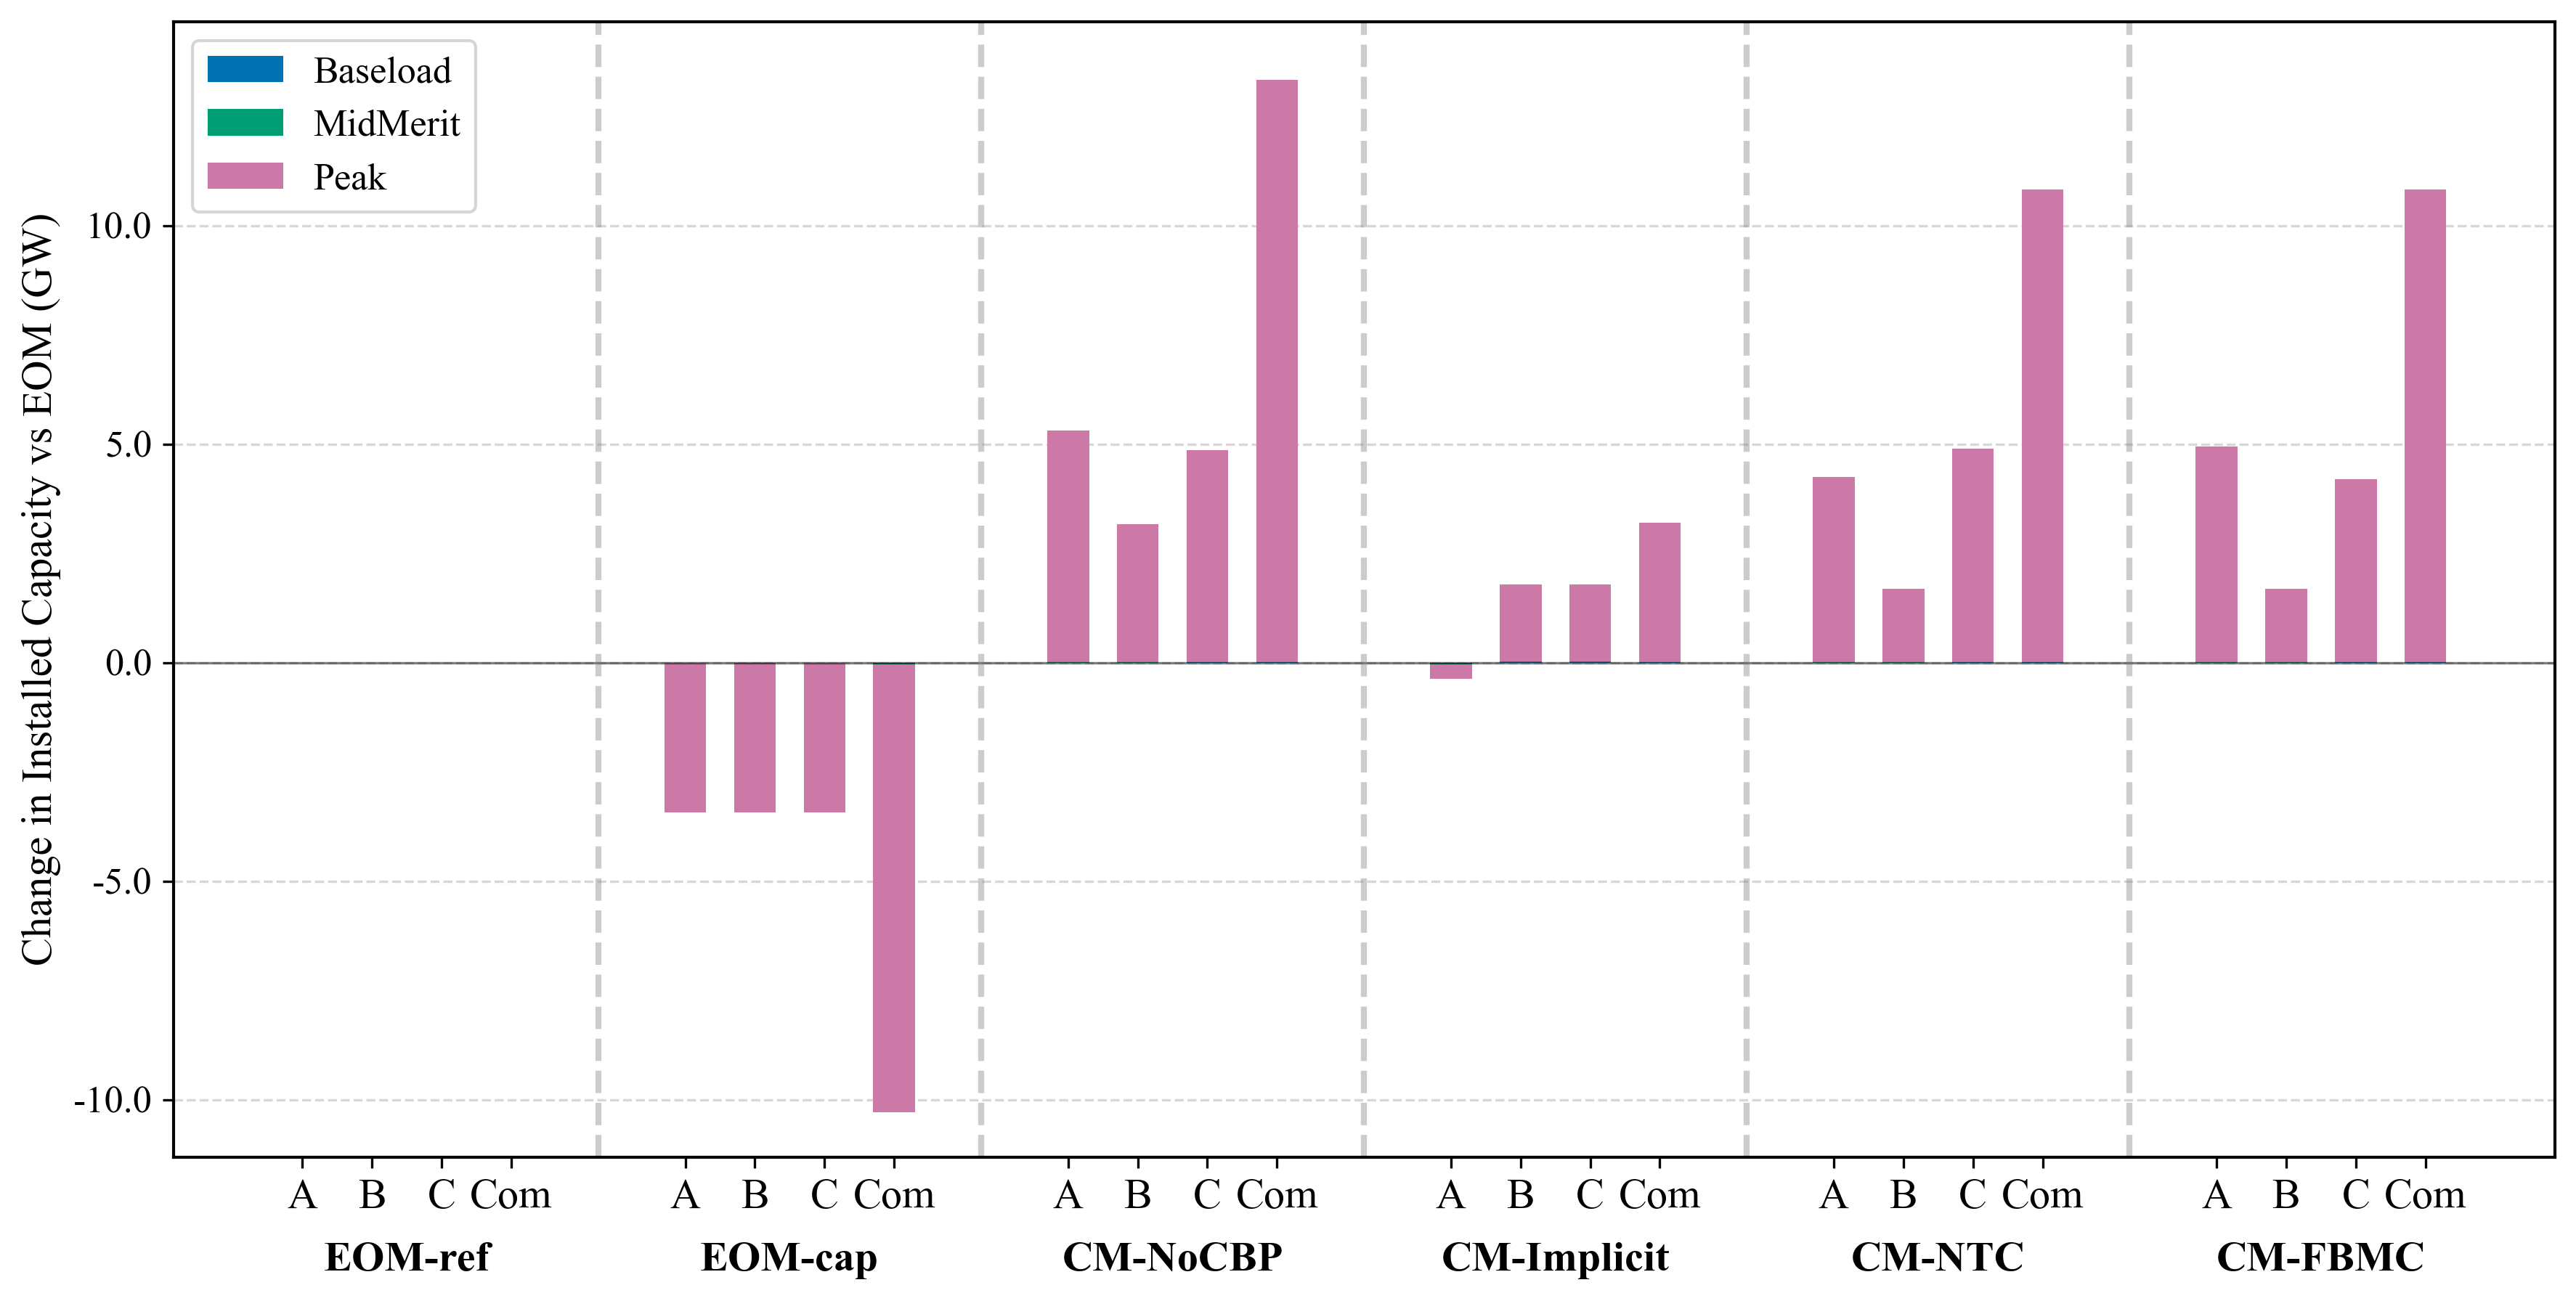

In [18]:
# plot capacity changes
capacity_changes = extract_capacity_changes(capacity_data)
print(capacity_changes)
plot_cap_bars(capacity_changes,"Change in Installed Capacity vs EOM (GW)")

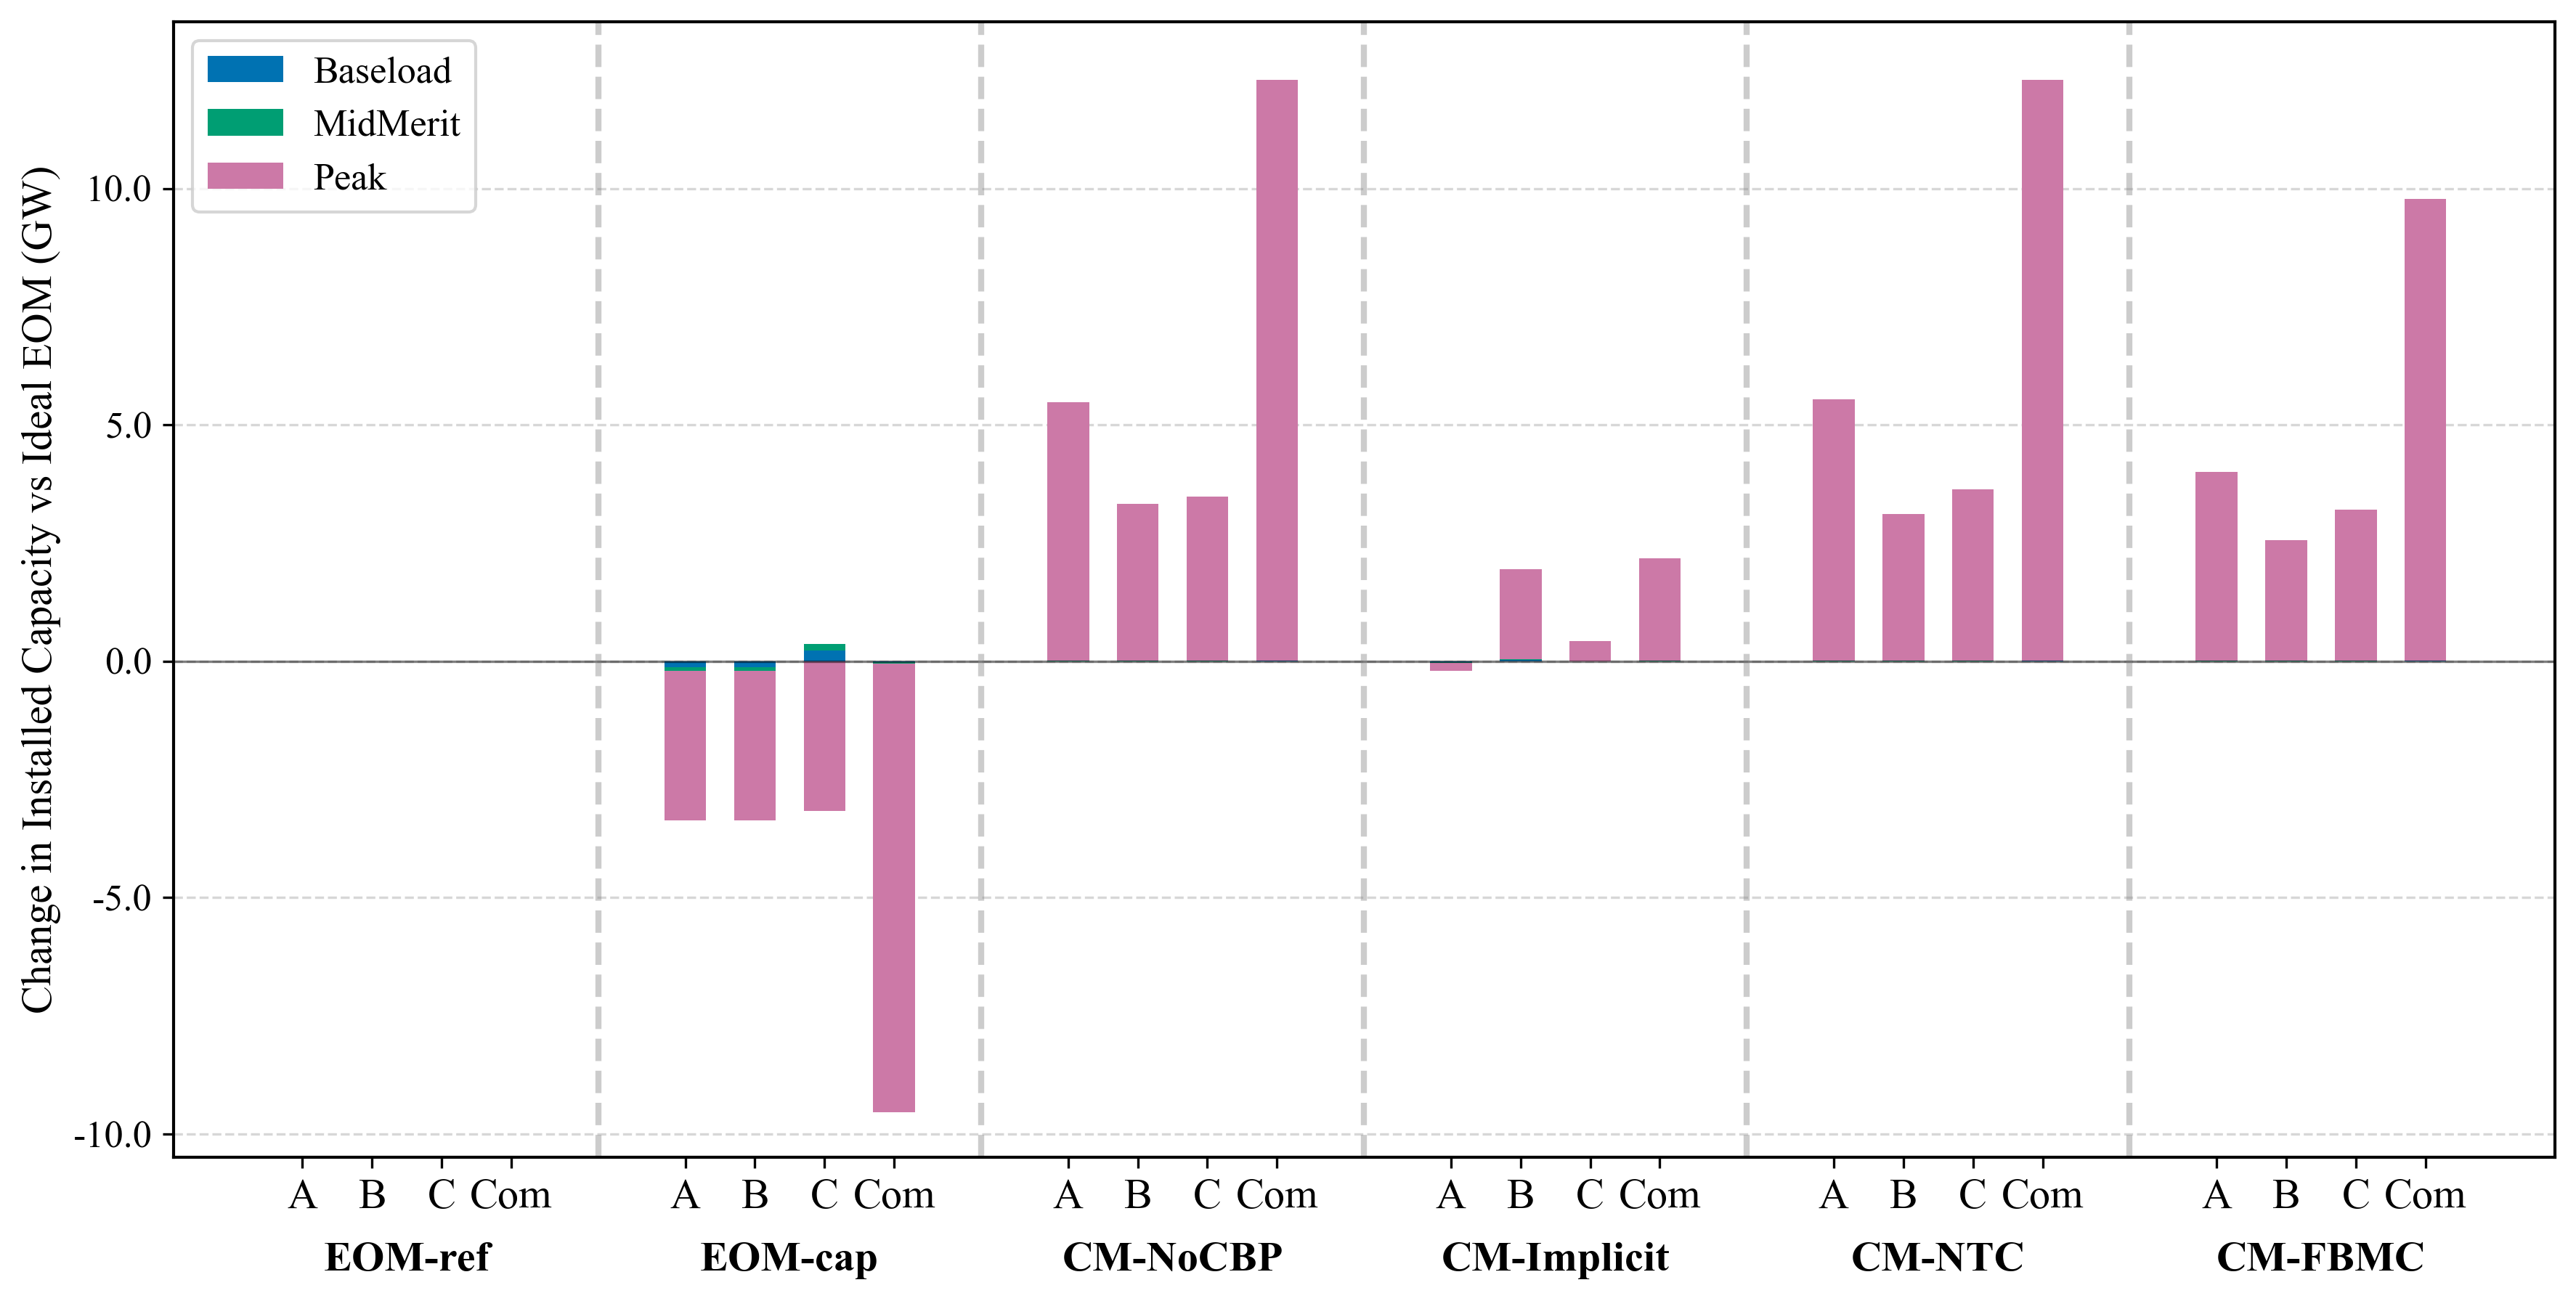

In [19]:
# plot capacity changes
planner_capacity_data = extract_capacity_changes(planner_capacity_data)
plot_cap_bars(planner_capacity_data, "Change in Installed Capacity vs Ideal EOM (GW)")

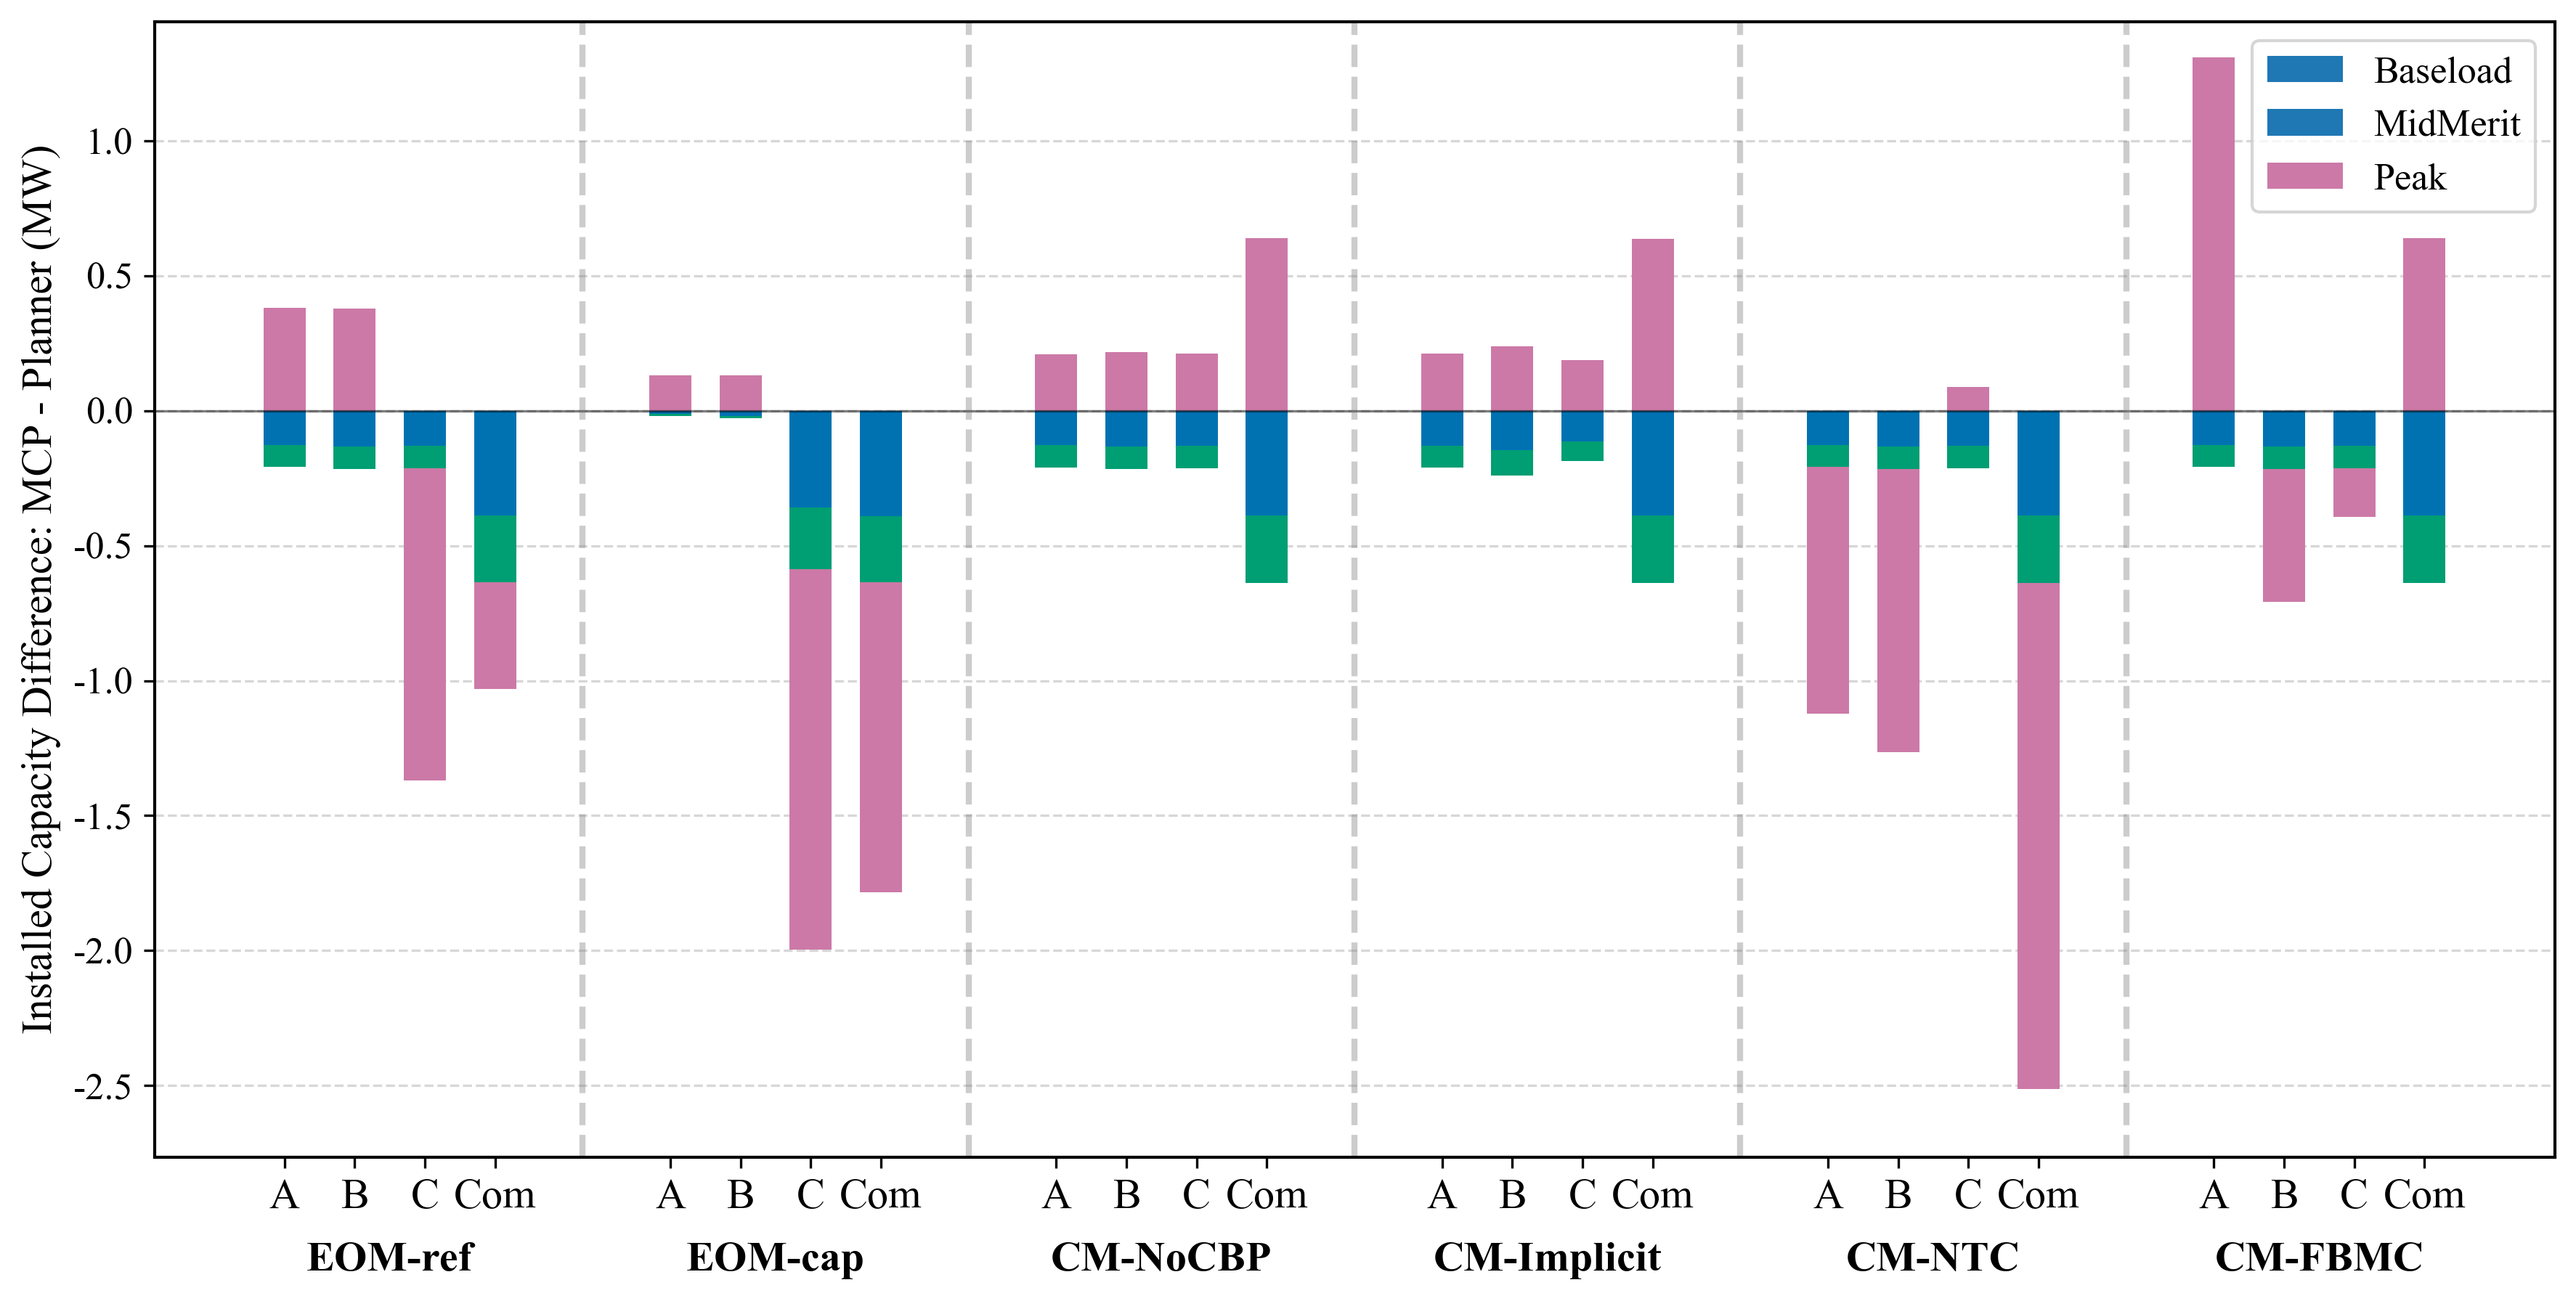

In [20]:
# Extract differences between planner and MCP models
planner_mcp_diffs = extract_planner_mcp_diffs(analysis_data)
plot_cap_bars(planner_mcp_diffs, "Installed Capacity Difference: MCP - Planner (MW)")

#### Merit order

In [21]:
def plot_merit_order_curve(
    analysis_data: dict,
    inputs: dict,
    hour: int,
    zone: str,
    market_design: str,
    source_type: str = "mcp"
):
    """
    Plot merit order curve showing generator offers, demand, and market clearing price.
    Properly handles quadratic cost curves: MC = a*g + b
    
    Parameters:
    - hour: timestep to analyze
    - zone: zone name (A, B, or C)
    - market_design: market design type (eom, FBMC, NTC, etc.)
    - source_type: "mcp" or "planner"
    """
    # Get the data key
    key = f"{source_type}_zone_{zone}_{market_design}"
    if key not in analysis_data:
        print(f"Error: {key} not found in analysis data")
        return
    
    df = analysis_data[key]
    hour = hour - 1
    # Get market clearing price and demand at this hour
    eom_price = df.at[hour, "EOM_price"]
    demand = abs(df.at[hour, f"Cons_{zone}"]) - df.at[hour, f"NetworkManager"]
    
    # Get generator parameters from config
    gen_types = ["WindOnshore", "PV", "Baseload", "MidMerit", "Peak"]
    gen_data = []
    
    for gen in gen_types:
        # Get ACTUAL GENERATION at this hour
        gen_col = f"Gen_{zone}_{gen}"
        generation = df.at[hour, gen_col] if gen_col in df.columns else 0
        
        if generation <= 0:
            continue
            
        # Get cost parameters from config
        if zone in inputs["data"]["Generators"] and gen in inputs["data"]["Generators"][zone]:
            gen_params = inputs["data"]["Generators"][zone][gen]
            a = gen_params.get("a", 0)  # Quadratic term
            b = gen_params.get("b", 0)  # Linear term (marginal cost at zero)
            
            # Get installed capacity
            capacity_col = f"Capacity_Gen_{zone}_{gen}"
            capacity = df.at[hour, capacity_col] if capacity_col in df.columns else 0
            
            gen_data.append({
                "Generator": gen,
                "Generation": generation,
                "Capacity": capacity,
                "a": a,
                "b": b
            })
    
    # Sort generators by their STARTING marginal cost (MC at g=0)
    gen_data = sorted(gen_data, key=lambda x: x["b"])
    
    # Build supply curve accounting for quadratic costs
    cumulative_generation = 0
    x_supply = [0]
    y_supply = [0]
    
    # Check if Peak generator is at capacity (for scarcity pricing)
    peak_at_capacity = False
    for gen in gen_data:
        if gen["Generator"] == "Peak" and gen["Capacity"] > 0:
            # Check if peak is producing at or near capacity (within 1% tolerance)
            if gen["Generation"] >= gen["Capacity"] * 0.99:
                peak_at_capacity = True
                break
    
    for gen in gen_data:
        # Starting point: cumulative generation before this generator
        x_start = cumulative_generation
        # Ending point: cumulative generation after this generator
        x_end = cumulative_generation + gen["Generation"]
        

        mc_start = gen["b"]
        # MC at end of this generator (g=generation for this generator): MC = a*generation + b
        mc_end = gen["a"] * gen["Generation"] + gen["b"]
        
        # Add both start and end points for smooth curve
        x_supply.append(x_start)
        y_supply.append(mc_start)
        x_supply.append(x_end)
        y_supply.append(mc_end)
        
        cumulative_generation = x_end
    
    # Add vertical scarcity line if Peak generator is at capacity
    if peak_at_capacity:
        # Add vertical line from last marginal cost to market clearing price
        x_supply.append(cumulative_generation)
        y_supply.append(eom_price)
    
    # Create plot
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    # Plot supply curve (merit order) - use default line style for smooth quadratic segments
    ax.plot(x_supply, y_supply, 'b-', linewidth=2, label='Supply Curve (Merit Order)')
    
    
    # Determine x-axis limit to ensure demand line is visible
    max_x = max(cumulative_generation, demand) * 1.1
    
    # Plot demand as vertical line
    ax.axvline(x=demand, color='red', linestyle='--', linewidth=2.5, 
               label=f'Demand ({demand:.0f} MW)', zorder=3)
    
    # Plot market clearing price as horizontal line
    max_price = max(max(y_supply) if y_supply else 0, eom_price) * 1.1
    ax.axhline(y=eom_price, color='green', linestyle='--', linewidth=2.5, 
               label=f'Market Clearing Price ({eom_price:.2f} €/MWh)', zorder=3)
    
    # Mark intersection point (where supply meets demand)
    ax.plot(demand, eom_price, 'ko', markersize=10, label='Market Equilibrium', zorder=5)
    
    # # Add shaded area for consumer surplus
    # if demand <= cumulative_generation and eom_price > 0:
    #     ax.fill_betweenx([0, eom_price], 0, demand, alpha=0.2, color='green', 
    #                      label='Consumer Surplus')
    
    # Formatting
    ax.set_xlabel('Generation / Demand (MW)', fontsize=FONT_SIZES['axis_label'])
    ax.set_ylabel('Price (€/MWh)', fontsize=FONT_SIZES['axis_label'])
    ax.set_title(f'Merit Order Curve - Zone {zone}, Hour {hour+1}, {market_design.upper()}', 
                 fontsize=FONT_SIZES['zone_label'])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=FONT_SIZES['tick_label'])
    
    # Set axis limits
    ax.set_xlim(0, max_x)
    ax.set_ylim(0, max_price)
    
    # Add generator labels on the supply curve
    cumulative = 0
    for gen in gen_data:
        mid_point = cumulative + gen["Generation"] / 2
        # Calculate marginal cost at midpoint for label placement
        # MC at midpoint of THIS generator's output
        g_mid = gen["Generation"] / 2
        mc_mid = gen["a"] * g_mid + gen["b"]
        y_pos = mc_mid + max_price * 0.02
        
        # Don't place labels too high if there's scarcity pricing
        if y_pos > max_price * 0.9:
            y_pos = mc_mid - max_price * 0.02
            
        ax.text(mid_point, y_pos, 
                gen["Generator"], 
                ha='center', va='bottom', fontsize=FONT_SIZES['annotation'], 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        cumulative += gen["Generation"]
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n--- Merit Order Summary ---")
    print(f"Zone: {zone} | Hour: {hour+1} | Design: {market_design}")
    print(f"Demand: {demand:.2f} MW")
    print(f"Total Generation: {cumulative_generation:.2f} MW")
    print(f"Market Clearing Price: {eom_price:.2f} €/MWh")
    print(f"Peak at Capacity: {'Yes' if peak_at_capacity else 'No'}")
    print(f"\nGenerator Stack (sorted by starting marginal cost):")
    cumulative = 0
    for gen in gen_data:
        # CORRECTED: Use individual generator output for MC calculation
        mc_start = gen["b"]
        mc_end = gen["a"] * gen["Generation"] + gen["b"]
        
        cumulative += gen["Generation"]
        utilization = (gen["Generation"] / gen["Capacity"] * 100) if gen["Capacity"] > 0 else 0
        print(f"  {gen['Generator']:12s}: {gen['Generation']:8.2f} MW (Cap: {gen['Capacity']:8.2f} MW, {utilization:5.1f}%) | "
              f"MC: {mc_start:6.2f} → {mc_end:6.2f} €/MWh | "
              f"Cumulative: {cumulative:.2f} MW")
    
    return fig, ax

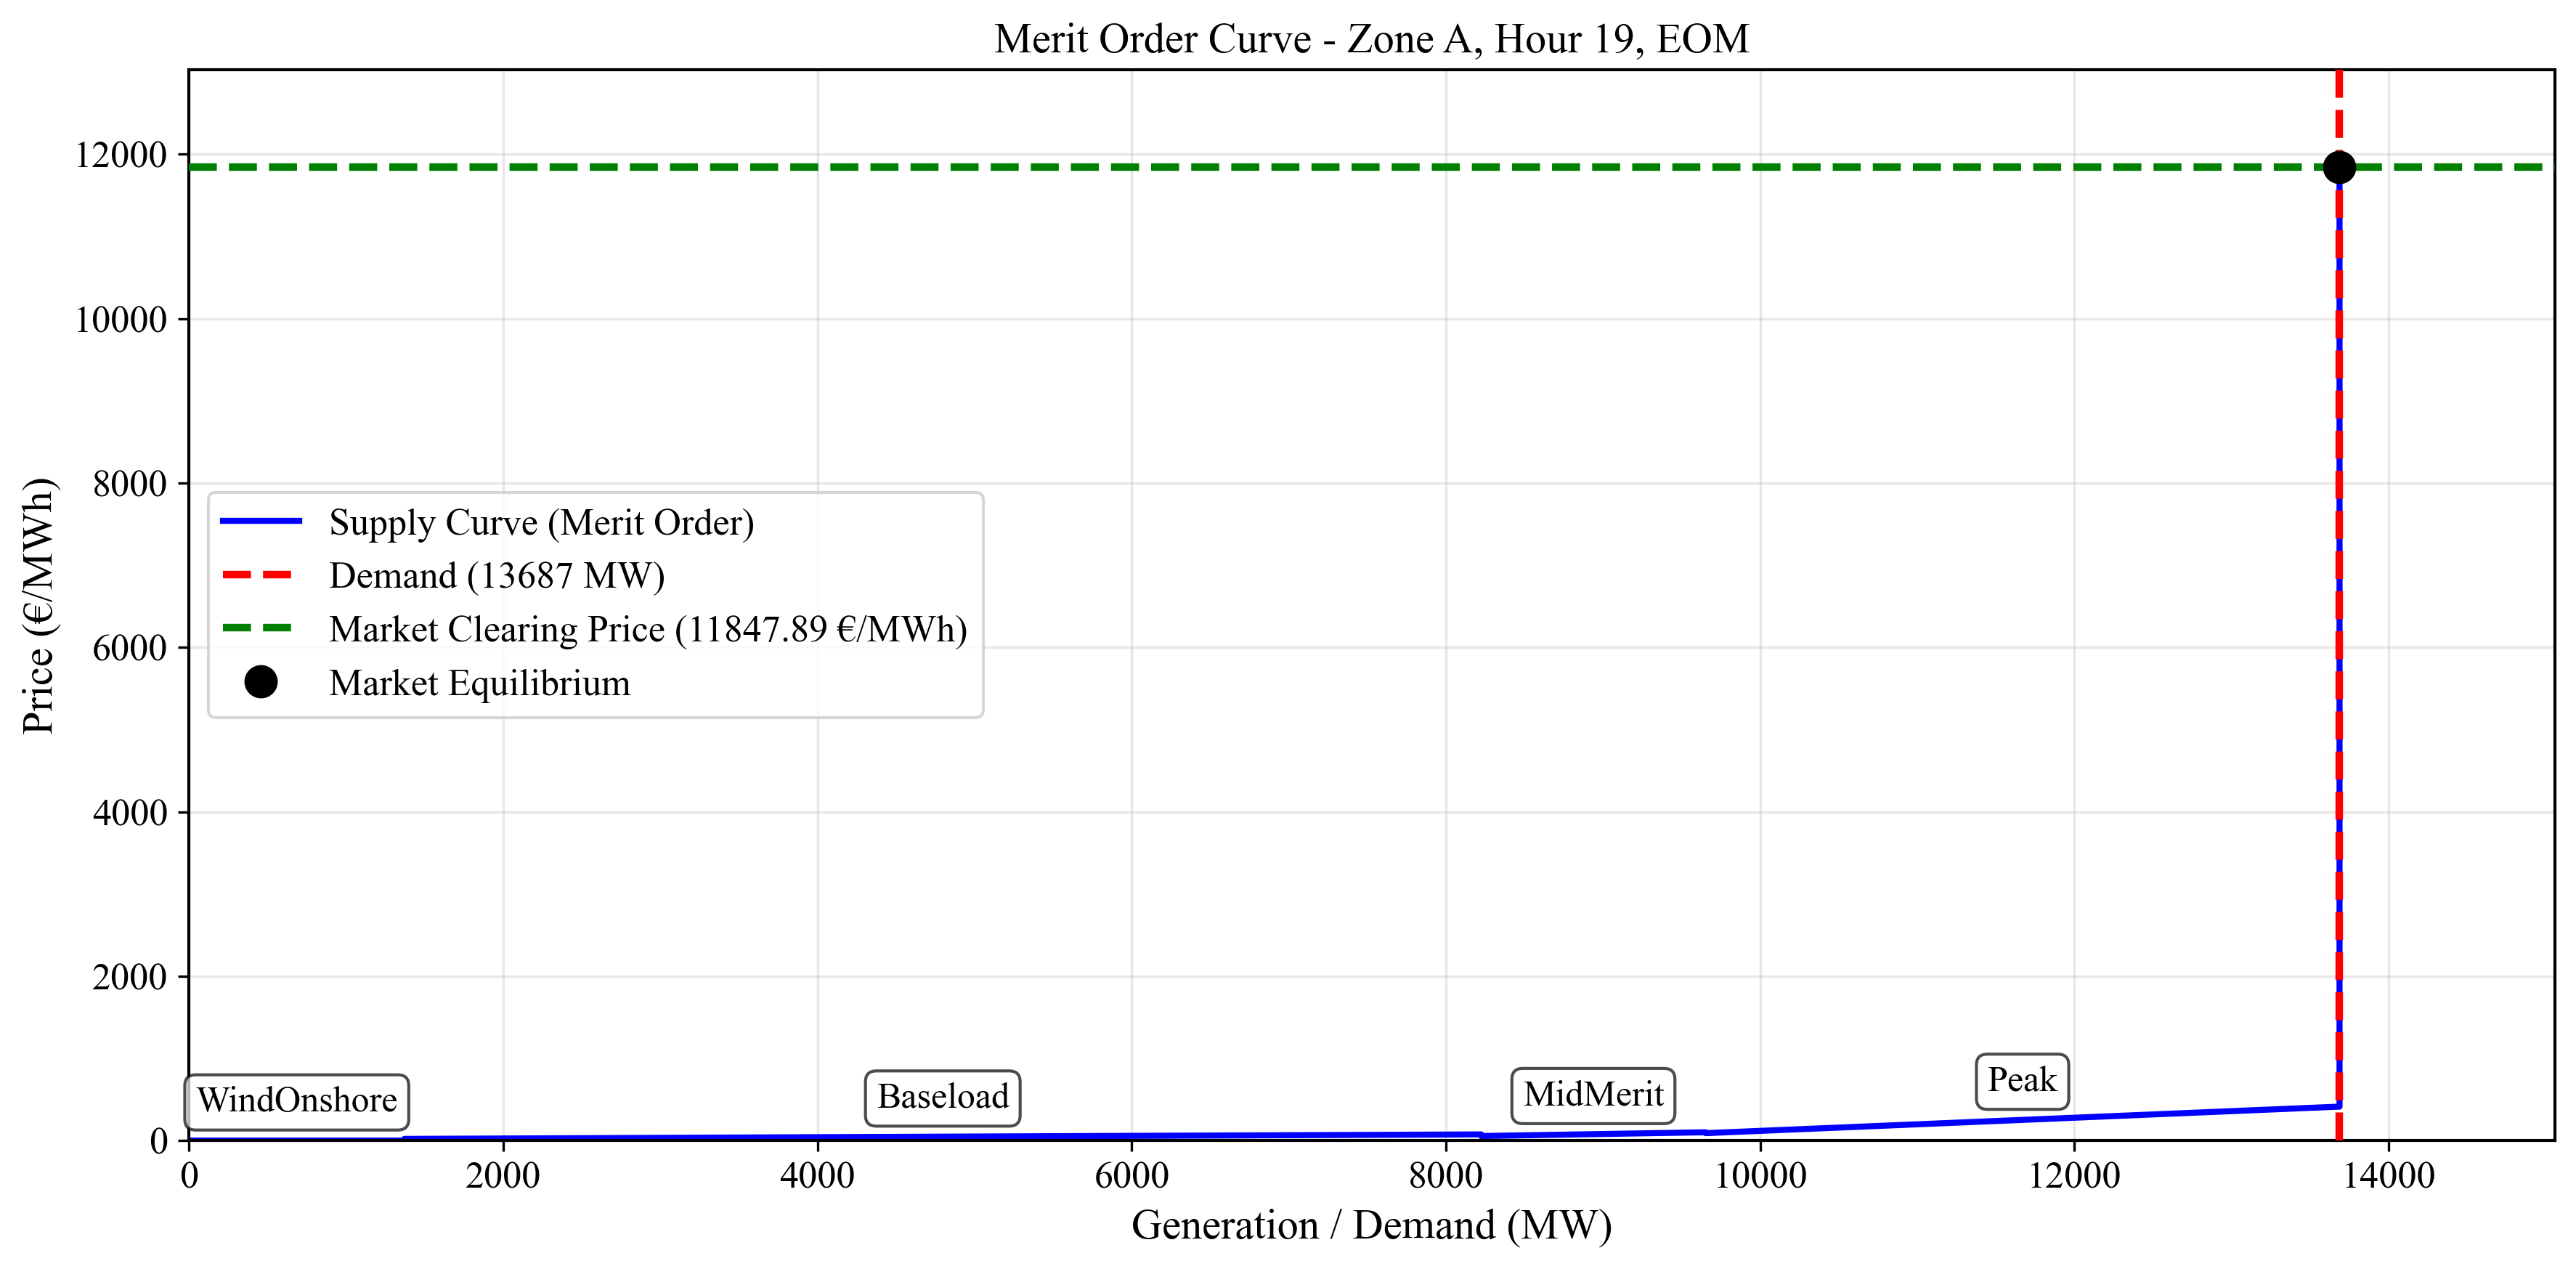


--- Merit Order Summary ---
Zone: A | Hour: 19 | Design: eom
Demand: 13686.94 MW
Total Generation: 13686.94 MW
Market Clearing Price: 11847.89 €/MWh
Peak at Capacity: Yes

Generator Stack (sorted by starting marginal cost):
  WindOnshore :  1370.14 MW (Cap: 13700.00 MW,  10.0%) | MC:   0.00 →   0.00 €/MWh | Cumulative: 1370.14 MW
  Baseload    :  6853.40 MW (Cap:  6853.40 MW, 100.0%) | MC:  20.00 →  74.83 €/MWh | Cumulative: 8223.54 MW
  MidMerit    :  1428.72 MW (Cap:  1428.72 MW, 100.0%) | MC:  55.00 → 100.72 €/MWh | Cumulative: 9652.25 MW
  Peak        :  4034.69 MW (Cap:  4034.69 MW, 100.0%) | MC:  90.00 → 412.77 €/MWh | Cumulative: 13686.94 MW


In [22]:
# MCP merit order curve
fig, ax = plot_merit_order_curve(
    analysis_data=analysis_data,
    inputs=inputs,
    hour=19,  # Hour with high scarcity price
    zone="A",
    market_design="eom",
    source_type="mcp"
)

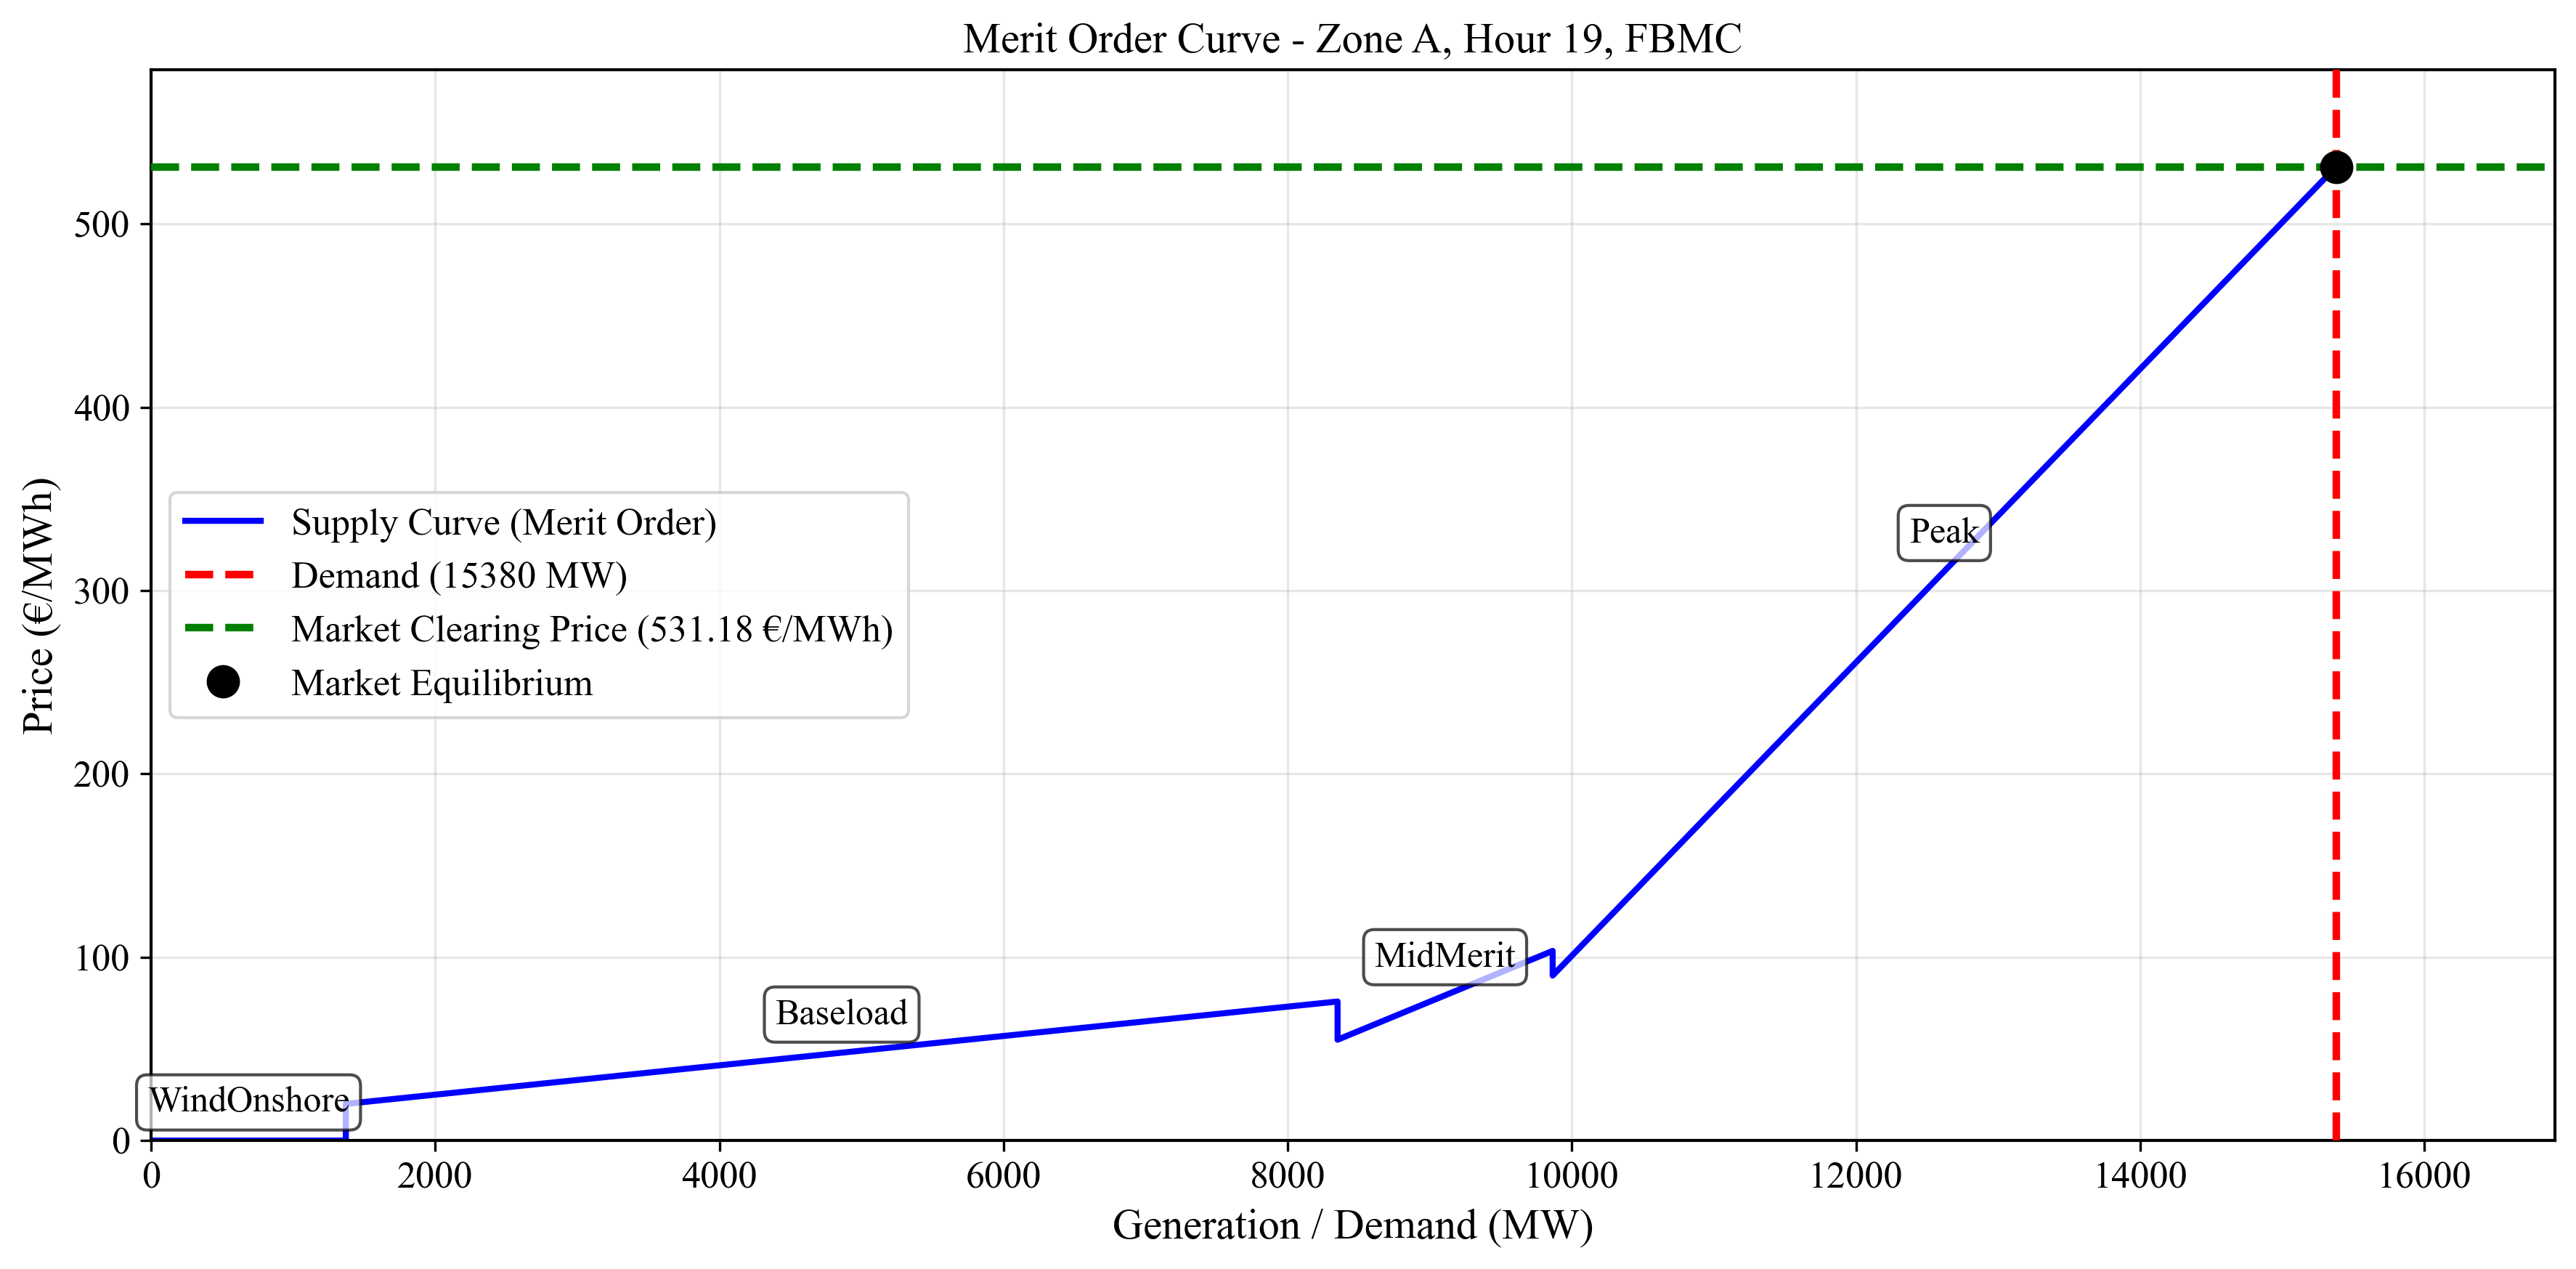


--- Merit Order Summary ---
Zone: A | Hour: 19 | Design: FBMC
Demand: 15379.88 MW
Total Generation: 15379.88 MW
Market Clearing Price: 531.18 €/MWh
Peak at Capacity: No

Generator Stack (sorted by starting marginal cost):
  WindOnshore :  1370.14 MW (Cap: 13700.00 MW,  10.0%) | MC:   0.00 →   0.00 €/MWh | Cumulative: 1370.14 MW
  Baseload    :  6980.94 MW (Cap:  6980.94 MW, 100.0%) | MC:  20.00 →  75.85 €/MWh | Cumulative: 8351.08 MW
  MidMerit    :  1514.05 MW (Cap:  1514.05 MW, 100.0%) | MC:  55.00 → 103.45 €/MWh | Cumulative: 9865.13 MW
  Peak        :  5514.75 MW (Cap:  7656.67 MW,  72.0%) | MC:  90.00 → 531.18 €/MWh | Cumulative: 15379.88 MW


In [23]:
# planner merit order curve
fig, ax = plot_merit_order_curve(
    analysis_data=analysis_data,
    inputs=inputs,
    hour=19,  # Hour with high scarcity price
    zone="A",
    market_design="FBMC",
    source_type="planner"
)

#### Network flows

In [24]:
def plot_net_positions(data: Dict[str, pd.DataFrame], source_type: str = "planner"):
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    colors = {"import": "#C0C0C0", "export": "#CC79A7"}
    bar_width = 0.7  # Wider single bar

    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

    # Set positions for bars (one position per zone per design)
    n_designs = len(design_keys)
    n_zones = len(zones)
    total_groups = n_designs * n_zones
    indices = np.arange(total_groups)

    imports = []
    exports = []

    # Build grouped data
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            net_import = 0
            net_export = 0

            if key in data and "NetworkManager" in data[key].columns:
                flows = data[key]["NetworkManager"].values
                net_import = flows[flows >= 0].sum()
                net_export = abs(flows[flows < 0].sum())  # Make exports positive for plotting

            imports.append(net_import)
            exports.append(-net_export)  # Store as negative for plotting below x-axis

    # Plotting both imports and exports in one bar
    ax.bar(indices, imports, bar_width, label="Net import", color=colors["import"])
    ax.bar(indices, exports, bar_width, label="Net export", color=colors["export"])

    ## Annotate values on bars
    # for idx, (imp, exp) in enumerate(zip(imports, exports)):
    #     if imp > 0:
    #         ax.text(idx, imp/2, f"{abs(imp):.1f}", ha='center', va='top', fontsize=FONT_SIZES['annotation'])
    #     if exp < 0:
    #         ax.text(idx, exp/2, f"{abs(exp):.1f}", ha='center', va='bottom', fontsize=FONT_SIZES['annotation'])

    # Add vertical design group labels
    for i, design in enumerate(design_keys):
        center = i * len(zones) + 1  # Middle of each group
        max_val = max([max(imports), abs(min(exports))]) if imports or exports else 1
        ax.text(center, max_val + 2.5, map_policy_name(design), ha='center', va='bottom', fontsize=FONT_SIZES['zone_label'])

    # Gridlines and axis setup
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Energy flows [GWh]", fontsize=FONT_SIZES['axis_label'])
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Set x-ticks as zone names within each design
    ax.set_xticks(indices)
    ax.set_xticklabels(zones * len(design_keys))

    # Add vertical lines between groups
    for i in range(1, n_designs):
        ax.axvline(i * n_zones - 0.5, color='gray', linestyle='--', alpha=0.6)

    ax.legend(loc='upper left')
    
    # Set symmetric y-limits for better visual comparison
    y_limit = max(max(imports), abs(min(exports))) * 1.1
    ax.set_ylim(-y_limit, y_limit)
    
    # Format y-axis ticks in GW
    def GW_formatter(x, pos):
        return f'{x/1e3:.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(GW_formatter))
    
    plt.tight_layout()

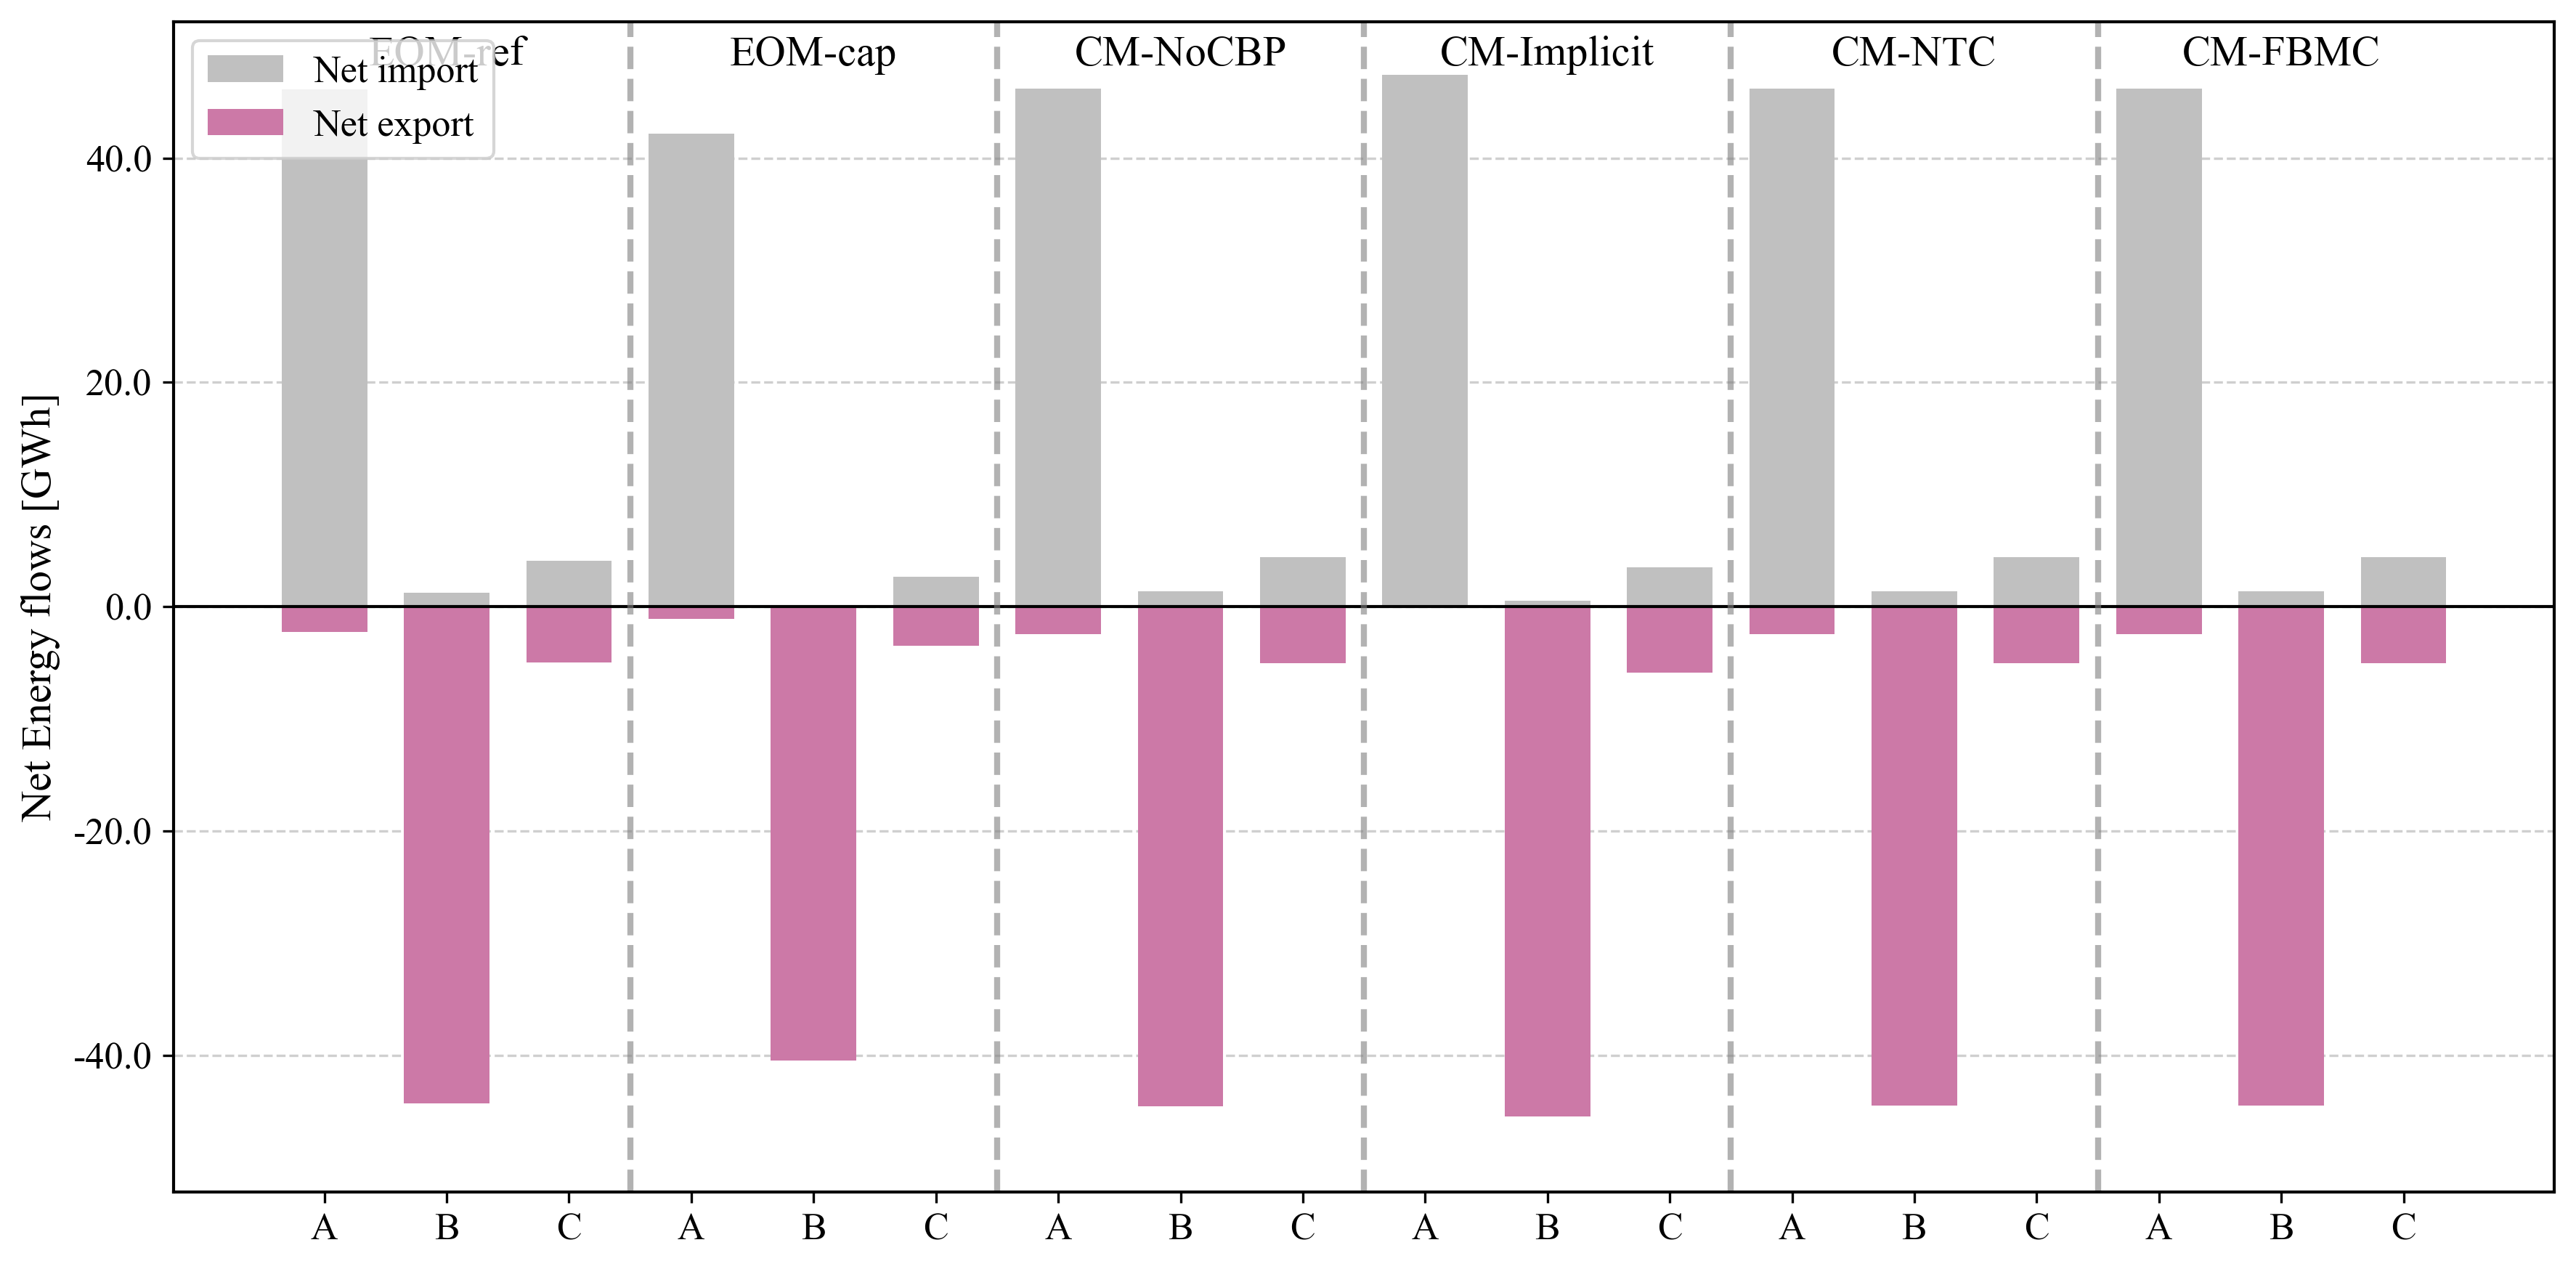

In [25]:
plot_net_positions(analysis_data, source_type="mcp")

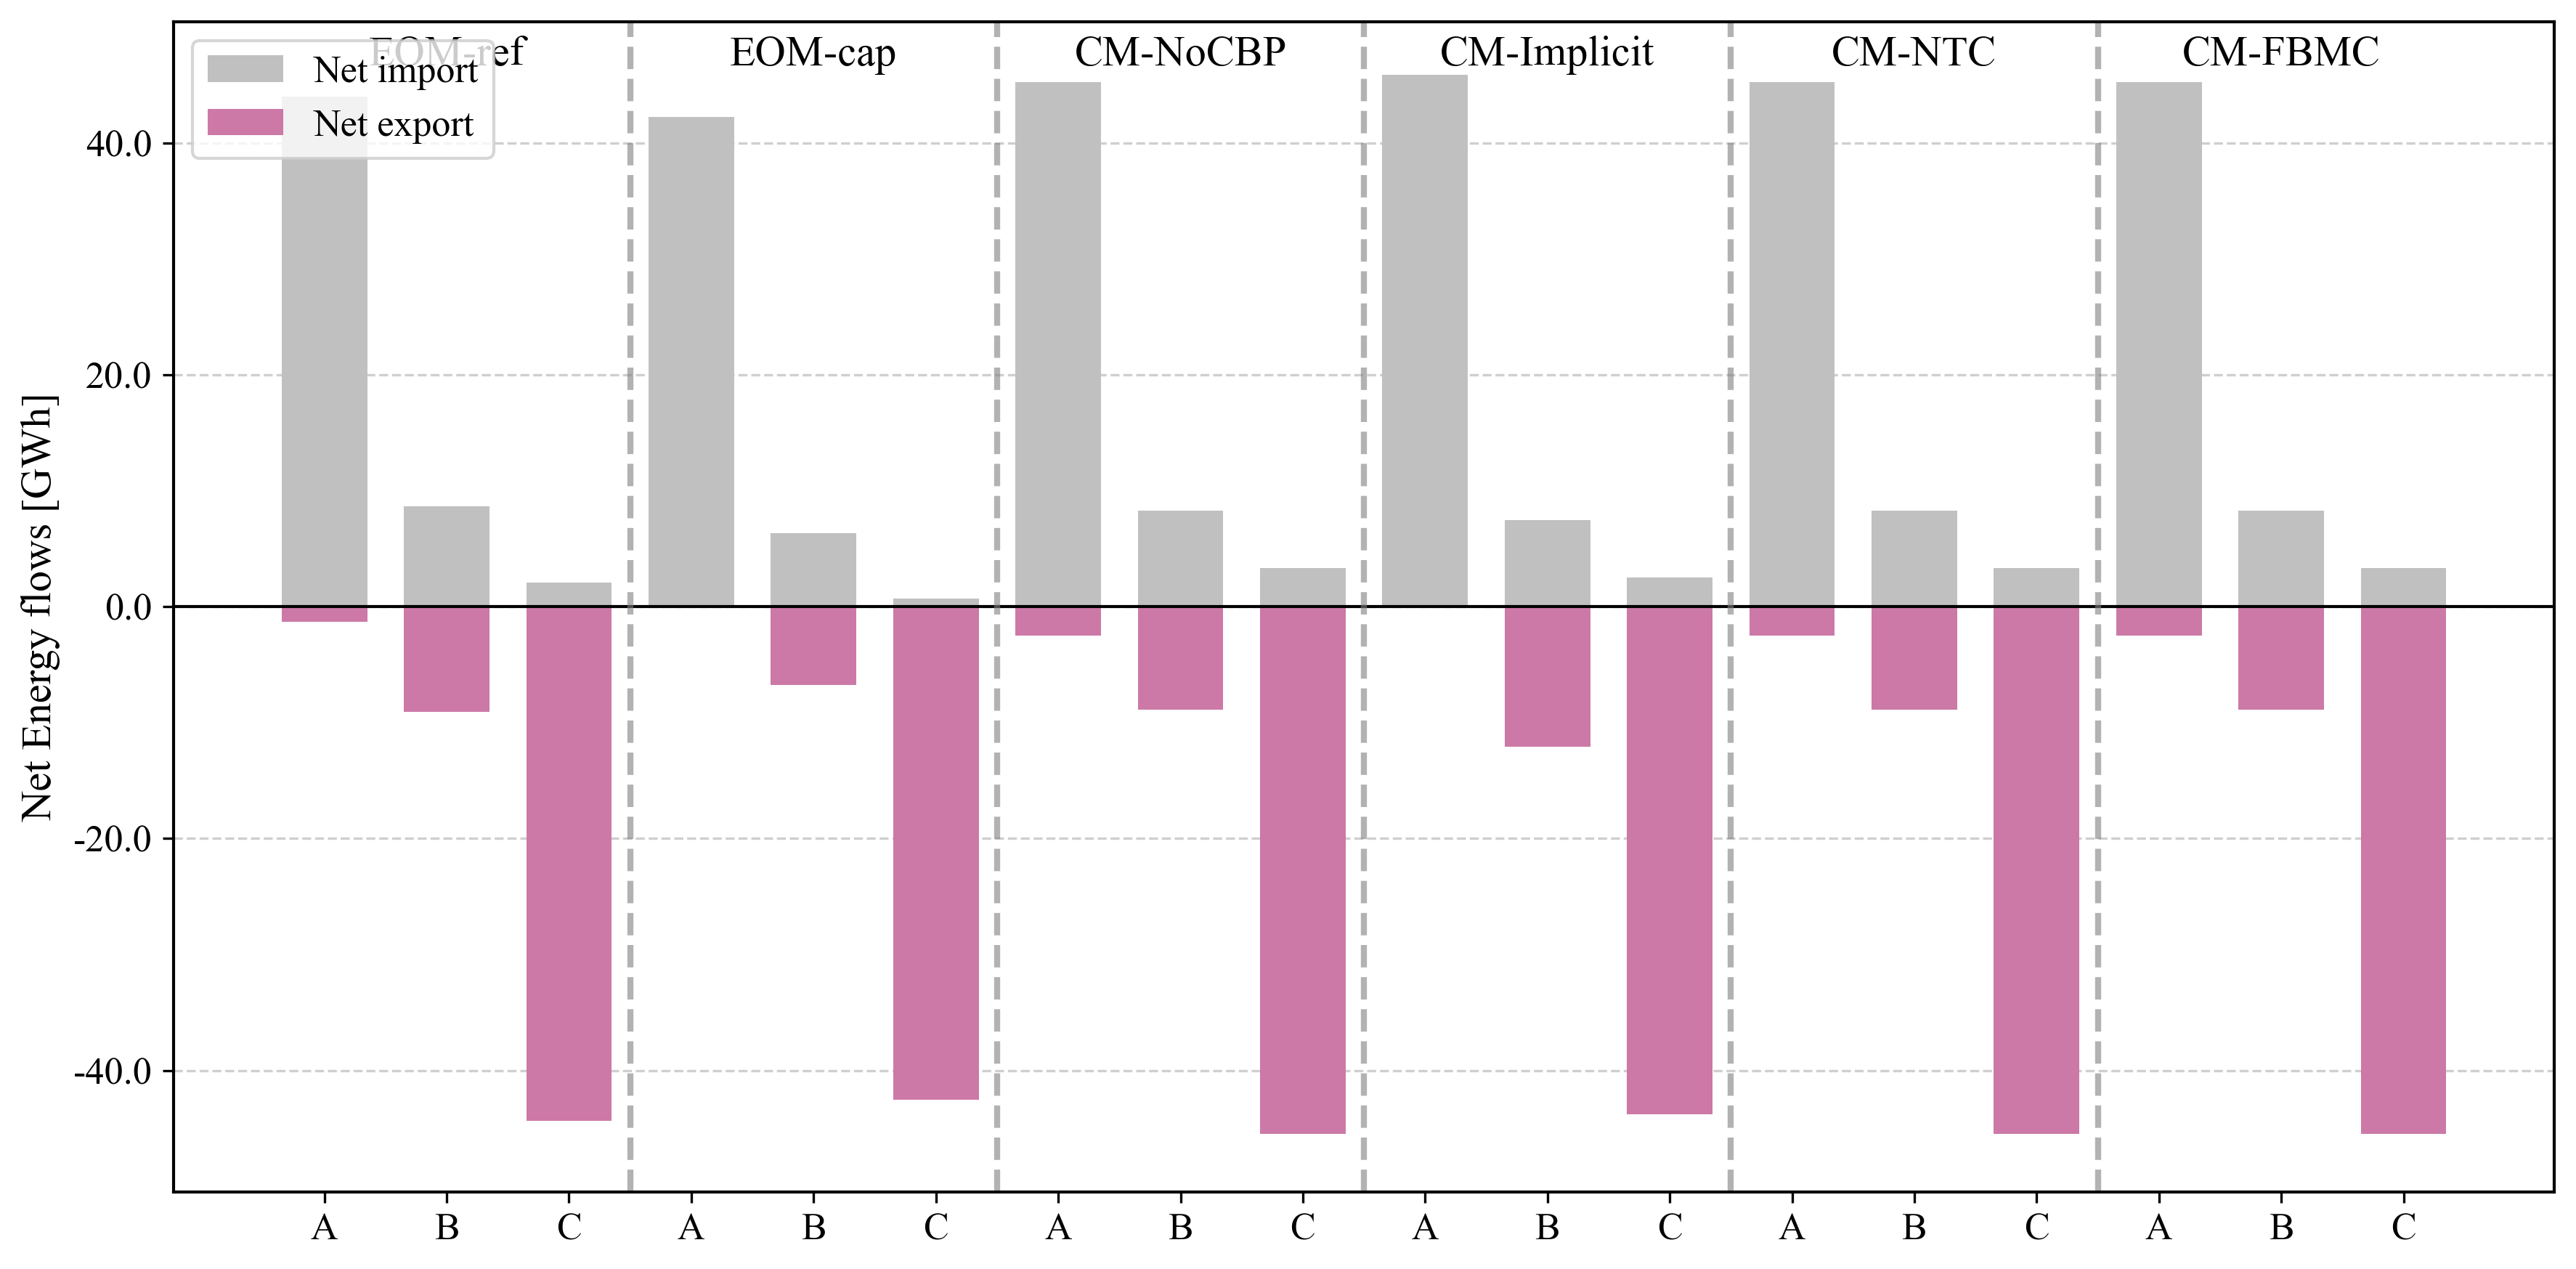

In [26]:
# Visualize net positions by zone
plot_net_positions(analysis_data, source_type="planner")

In [27]:
# Congestion Rent
# implicit:
# zone A :
# zone B :
# zone C :


# ATC:
# zone A :
# zone B :
# zone C :

# FBMC:
# zone A :
# zone B :
# zone C :


In [28]:
def compare_scarcity_imports(data: Dict[str, pd.DataFrame], source_type: str = "mcp"):
    """
    Compare net imports during scarcity hours (peak load) across all market designs.
    Each zone's scarcity hour = its peak consumption hour.
    
    Parameters:
    - data: Dictionary of analysis dataframes
    - source_type: "mcp" or "planner"
    
    Returns:
    - DataFrame with net position during scarcity hour by zone and design
    """
    zones = ["A", "B", "C"]
    design_keys = ["eom", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for design in design_keys:
        for zone in zones:
            # Use zone-specific file
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in data:
                print(f"Warning: {key} not found")
                continue
            
            df = data[key]
            
            # Get consumption column for this zone
            cons_col = f"Cons_{zone}"
            if cons_col not in df.columns or "NetworkManager" not in df.columns:
                print(f"Warning: Missing columns in {key}")
                continue
            
            # Find peak consumption hour (use abs() since consumption is negative)
            peak_index = df[cons_col].abs().idxmax()
            
            # Get timestep number
            if "Timestep" in df.columns:
                peak_hour = df.at[peak_index, "Timestep"]
            else:
                peak_hour = peak_index + 1
            
            # Get net position at peak hour
            # NetworkManager: positive = import, negative = export
            net_position = df.at[peak_index, "NetworkManager"]
            
            # Split into import and export for plotting
            net_import = max(0, net_position)
            net_export = max(0, -net_position)
            
            # Get peak consumption value
            peak_consumption = abs(df.at[peak_index, cons_col])
            
            # Get price at scarcity hour
            eom_price = df.at[peak_index, "EOM_price"] if "EOM_price" in df.columns else 0
            
            records.append({
                "Zone": zone,
                "Design": design,
                "PeakHour": peak_hour,
                "PeakConsumption": peak_consumption,
                "NetPosition": net_position,  # Positive = import, negative = export
                "NetImport": net_import,      # For plotting (always positive)
                "NetExport": net_export,      # For plotting (always positive)
                "ScarcityPrice": eom_price
            })
    
    return pd.DataFrame(records)


In [29]:
def plot_scarcity_imports(scarcity_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot net imports/exports during scarcity hours by zone and market design.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

    zones = ["A", "B", "C"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]

    # Colors matching plot_net_positions
    colors = {"import": "#C0C0C0", "export": "#CC79A7"}

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = scarcity_df[scarcity_df["Zone"] == zone]
        zone_start_x = current_x
        zone_positions_this_zone = []  # Track positions for THIS specific zone

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            net_import = row["NetImport"].values[0]
            net_export = -row["NetExport"].values[0]  # Negative for plotting below axis

            # Plot bars
            ax.bar(current_x, net_import, width=bar_width, color=colors["import"])
            ax.bar(current_x, net_export, width=bar_width, color=colors["export"])

            # Record positions
            x_positions.append(current_x)
            zone_positions_this_zone.append(current_x)
            x_labels.append(map_policy_name(design))
            current_x += 1

        # Zone mid label - calculate IMMEDIATELY while we're still in this zone's loop
        if zone_positions_this_zone:  # Only if this zone has data
            midpoint = (zone_positions_this_zone[0] + zone_positions_this_zone[-1]) / 2
            zone_label_positions.append((midpoint, f"Zone {zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['axis_label'], rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        ax.text(xpos, -0.25, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Position during Scarcity Period [GWh]", fontsize=FONT_SIZES['zone_label'])
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Legend
    legend_elements = [
        Patch(facecolor=colors["import"], label='Net import'),
        Patch(facecolor=colors["export"], label='Net export')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=FONT_SIZES['tick_label'])

    # Set symmetric y-limits based on actual data range
    max_import = scarcity_df["NetImport"].max()
    max_export = scarcity_df["NetExport"].max()
    max_val = max(max_import, max_export)
    
    # Only add padding if there's actual data, otherwise use a small default range
    if max_val > 0:
        ax.set_ylim(-max_export - 500, max_val * 1.1)
    else:
        ax.set_ylim(-100, 100)  # Default small range if no data

    # Format y-axis ticks in GW
    def GW_formatter(x, pos):
        return f'{x/1e3:.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(GW_formatter))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    return fig, ax


=== Net Position at Peak Load (MCP) ===
   Zone    Design  PeakHour  PeakConsumption  NetPosition    NetImport  \
0     A       eom        12     18833.603831  5146.670223  5146.670223   
1     B       eom        19     14104.350686  1263.633222  1263.633222   
2     C       eom        18     15867.401258  2726.575694  2726.575694   
3     A     NoCBP        12     18920.604804  5166.576743  5166.576743   
4     B     NoCBP        19     15912.329899  1377.606265  1377.606265   
5     C     NoCBP        18     17901.366546  3062.998790  3062.998790   
6     A  implicit        12     18917.585906  5606.024727  5606.024727   
7     B  implicit        19     15129.924960   503.618748   503.618748   
8     C  implicit        18     17197.034000  2261.590190  2261.590190   
9     A       NTC        12     18920.604163  5165.470581  5165.470581   
10    B       NTC        19     15912.402871  1383.698082  1383.698082   
11    C       NTC        18     17901.326202  3060.905235  3060.905235 

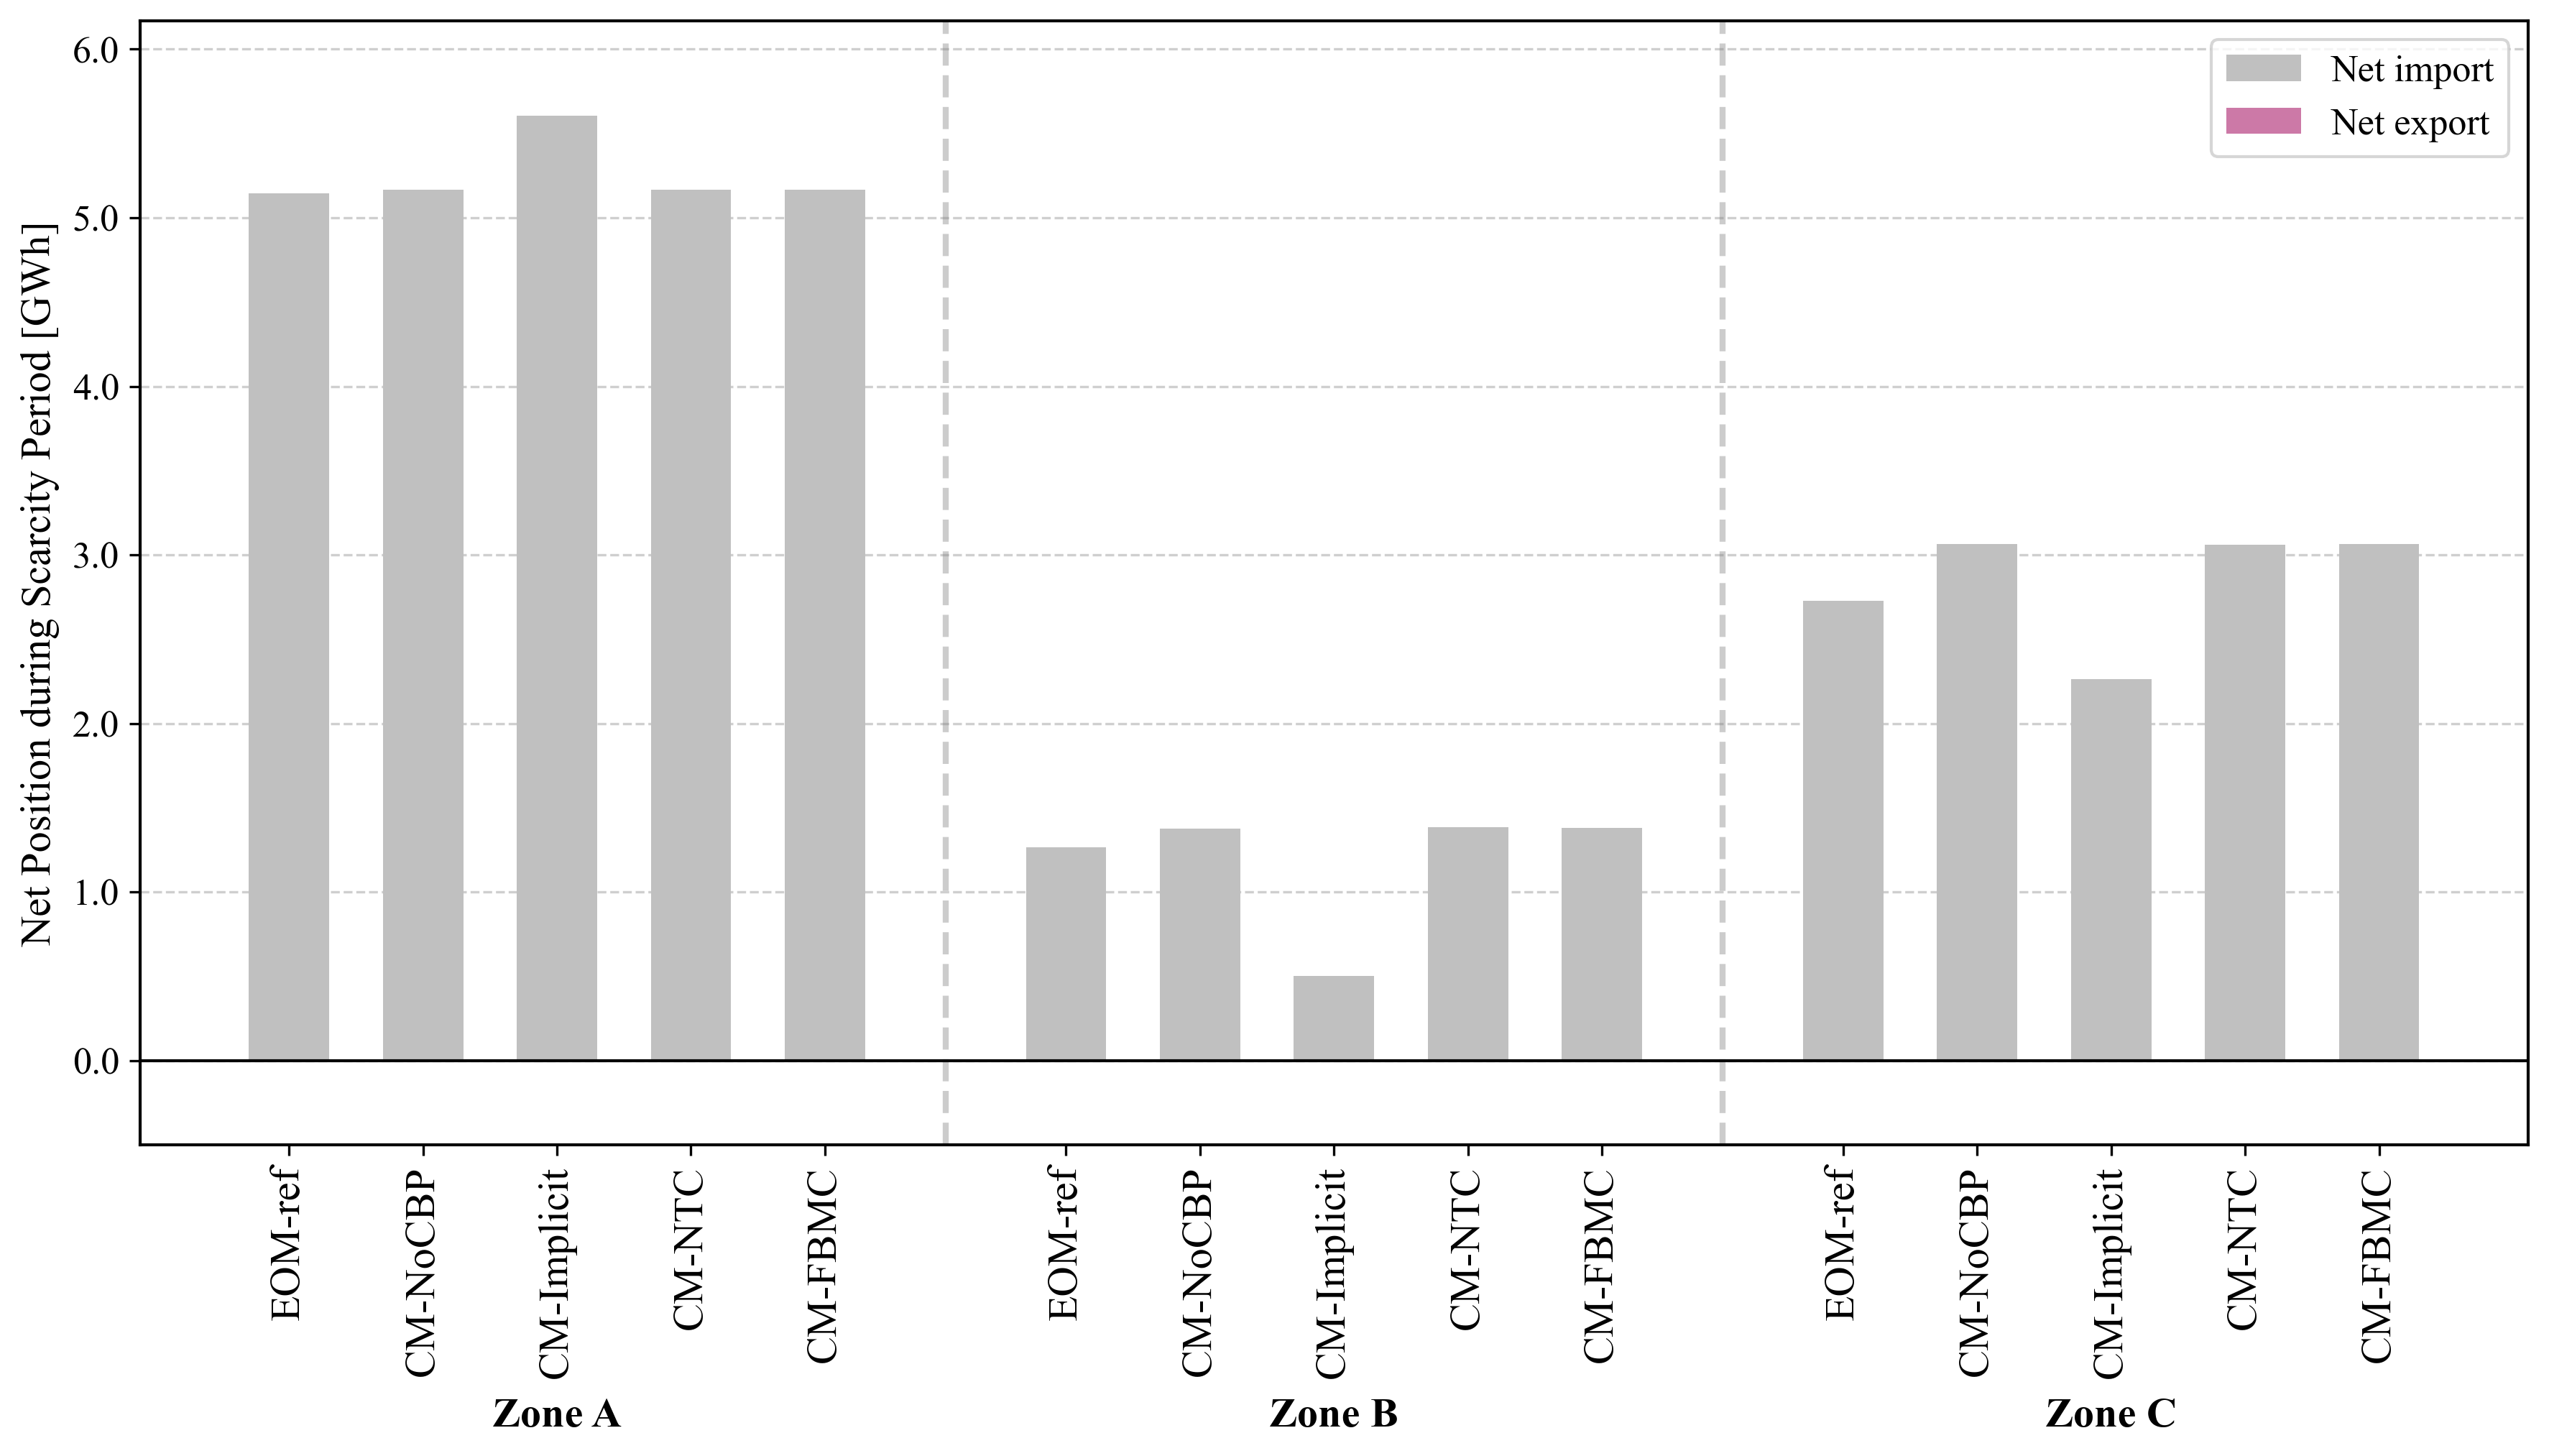

In [30]:
# Compare scarcity imports for MCP model
scarcity_imports_mcp = compare_scarcity_imports(analysis_data, source_type="mcp")
print("\n=== Net Position at Peak Load (MCP) ===")
print(scarcity_imports_mcp)
fig, ax = plot_scarcity_imports(scarcity_imports_mcp, source_type="mcp")
plt.show()


=== Net Position at Peak Load (Planner) ===
   Zone    Design  PeakHour  PeakConsumption  NetPosition  NetImport  \
0     A       eom      12.0         17979.46      4464.76    4464.76   
1     B       eom      19.0         14471.28      1795.16    1795.16   
2     C       eom      18.0         16280.19      1770.53    1770.53   
3     A     NoCBP      12.0         18931.57      5688.54    5688.54   
4     B     NoCBP      19.0         15915.02      1373.73    1373.73   
5     C     NoCBP      18.0         17904.40      3064.57    3064.57   
6     A  implicit      12.0         18896.83      5585.36    5585.36   
7     B  implicit      19.0         15248.79       622.51     622.51   
8     C  implicit      18.0         17166.03      2230.60    2230.60   
9     A       NTC      12.0         18931.57      5688.54    5688.54   
10    B       NTC      19.0         15915.02      1373.73    1373.73   
11    C       NTC      18.0         17904.40      3064.57    3064.57   
12    A      FBMC  

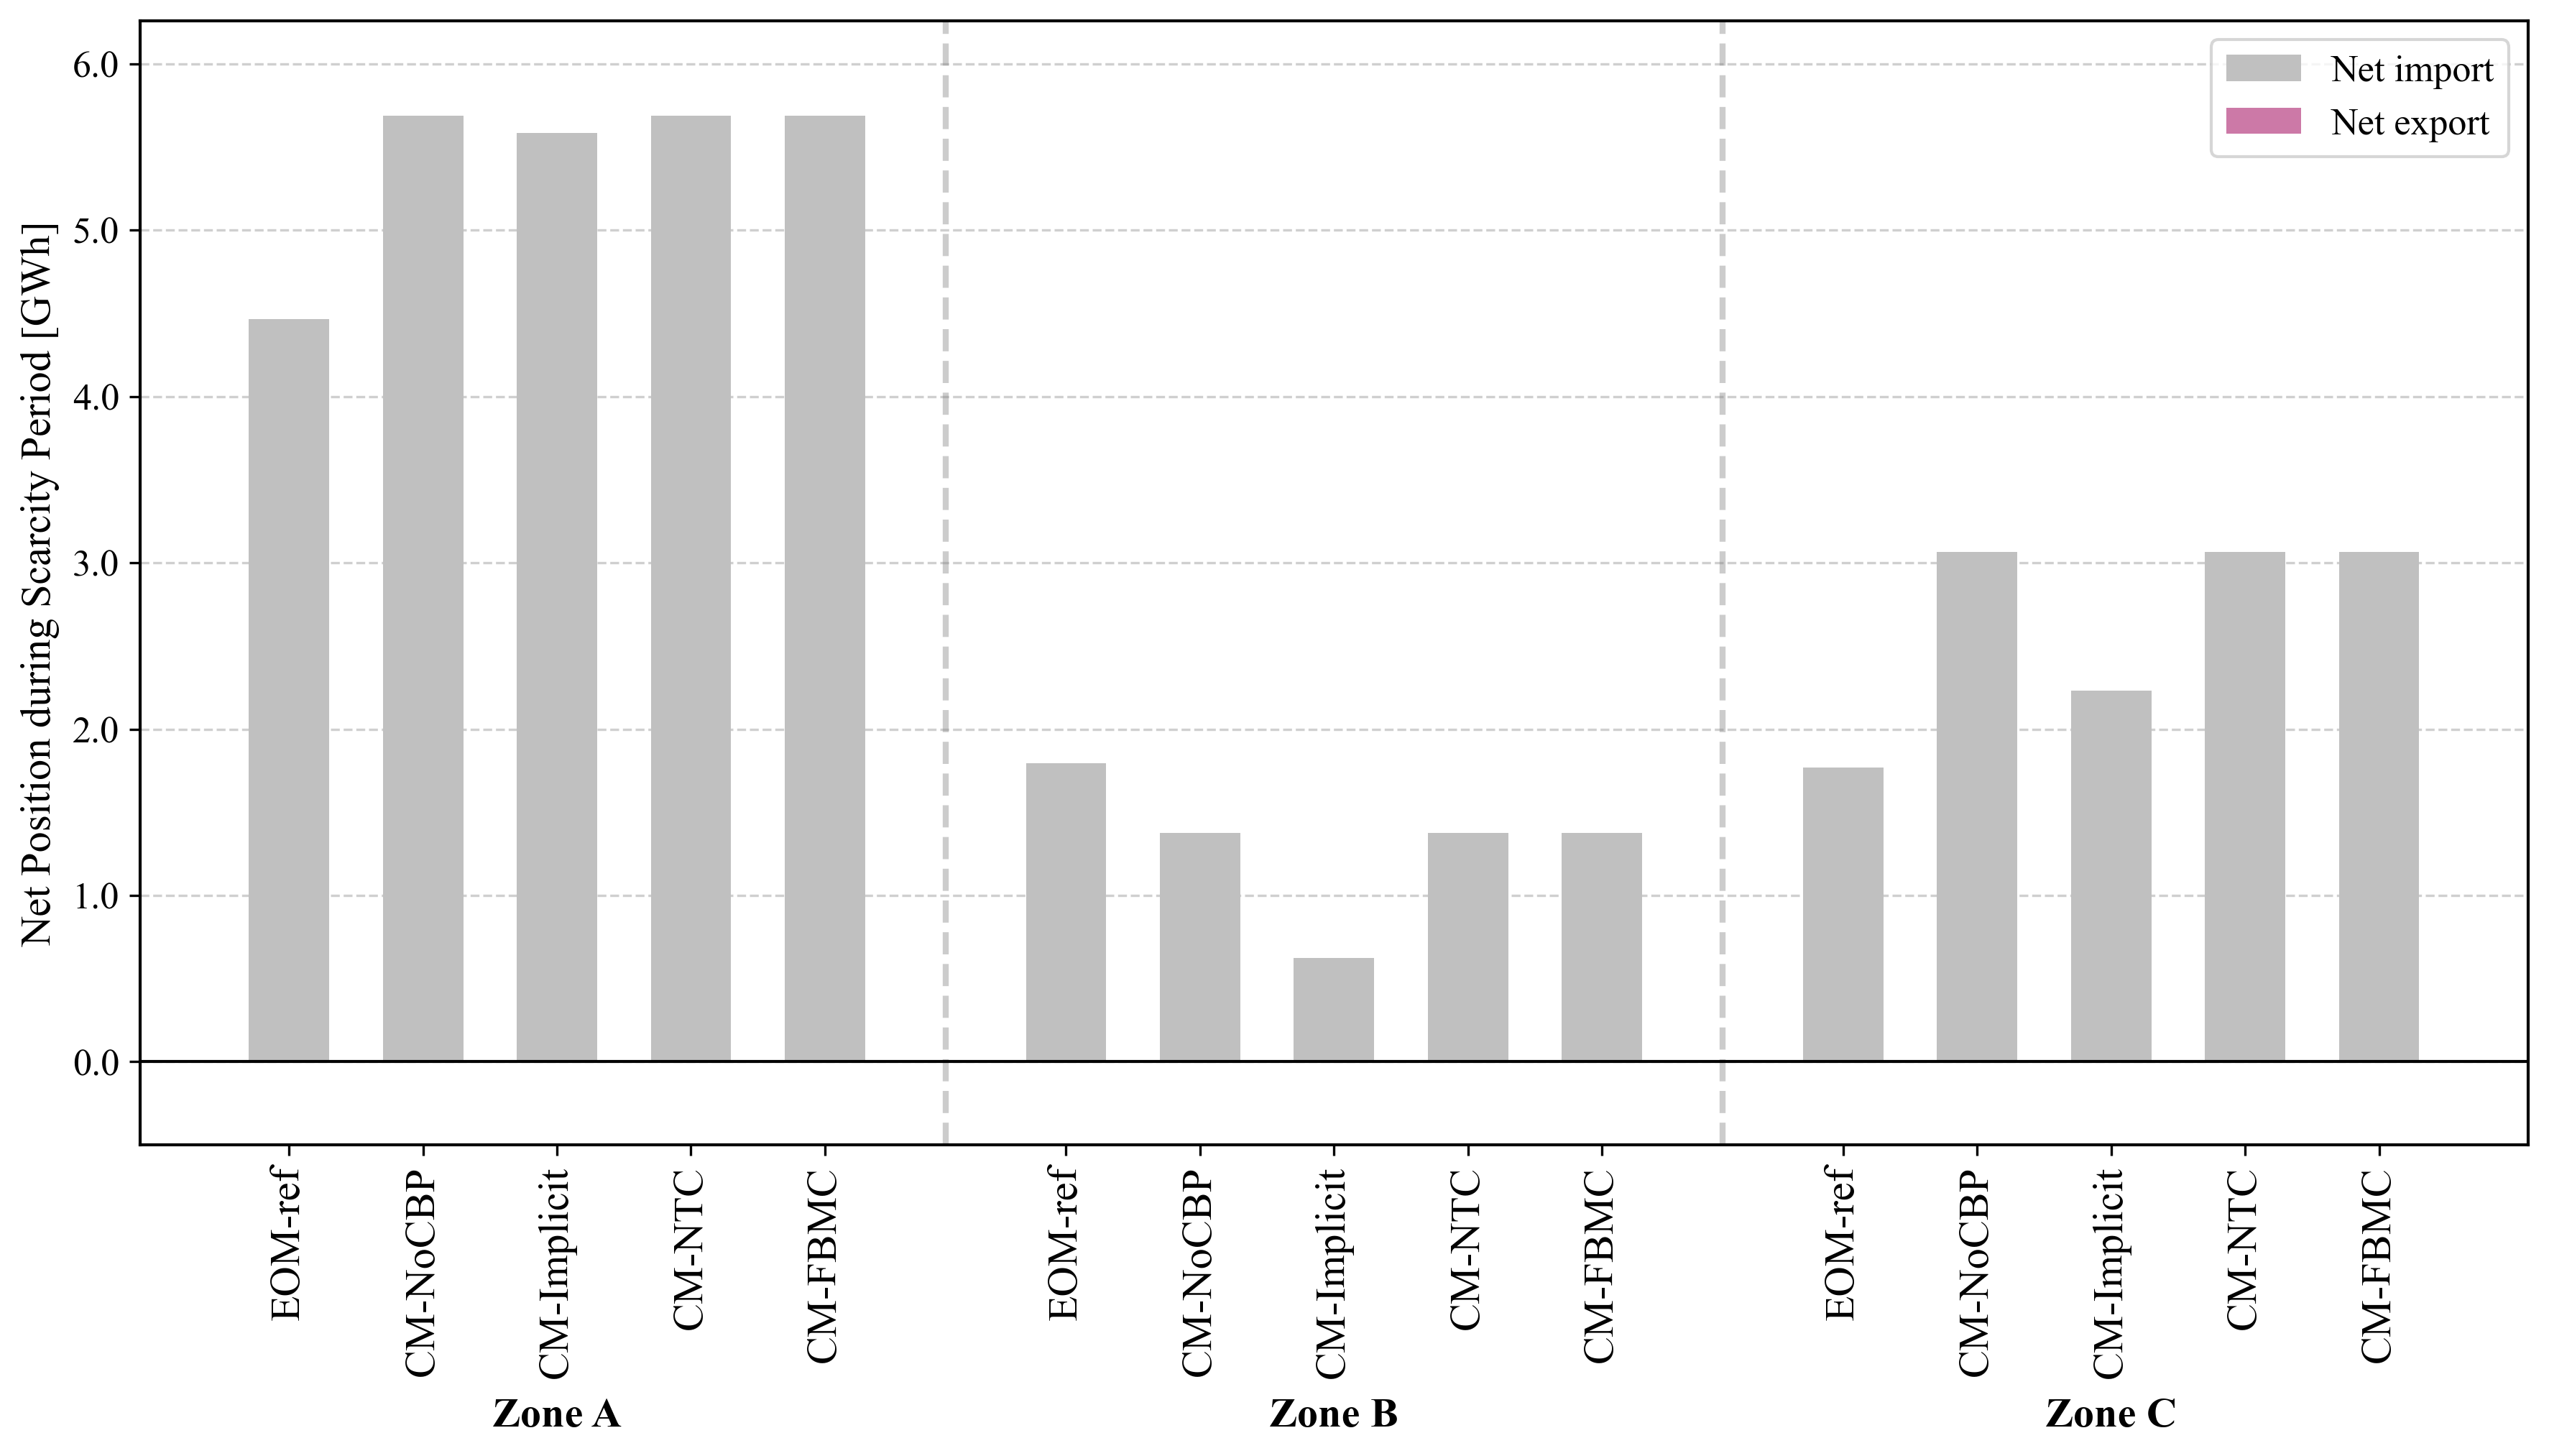

In [31]:
# Compare for Planner model
scarcity_imports_planner = compare_scarcity_imports(analysis_data, source_type="planner")
print("\n=== Net Position at Peak Load (Planner) ===")
print(scarcity_imports_planner)
fig, ax = plot_scarcity_imports(scarcity_imports_planner, source_type="planner")
plt.show()

#### capacity net positions

In [32]:
def plot_capacity_net_positions(data: Dict[str, pd.DataFrame], source_type: str = "planner"):
    """
    Plot net capacity positions (CapacityManager) for FBMC and NTC designs only.
    Uses the same color scheme as plot_net_positions.
    """
    zones = ["A", "B", "C"]
    design_keys = ["NTC", "FBMC"]  # Only explicit capacity market designs
    colors = {"import": "#C0C0C0", "export": "#CC79A7"}
    bar_width = 0.7

    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

    # Set positions for bars (one position per zone per design)
    n_designs = len(design_keys)
    n_zones = len(zones)
    total_groups = n_designs * n_zones
    indices = np.arange(total_groups)

    imports = []
    exports = []

    # Build grouped data
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            net_import = 0
            net_export = 0

            if key in data and "CapacityManager" in data[key].columns:
                # CapacityManager contains capacity trade flows - take only first value
                flows = data[key]["CapacityManager"].iloc[0]
                net_import = flows if flows >= 0 else 0
                net_export = abs(flows) if flows < 0 else 0

            imports.append(net_import)
            exports.append(-net_export)  # Store as negative for plotting below x-axis

    # Plotting both imports and exports
    ax.bar(indices, imports, bar_width, label="Capacity import", color=colors["import"])
    ax.bar(indices, exports, bar_width, label="Capacity export", color=colors["export"])

    # Add value labels on bars
    for idx, (imp, exp) in enumerate(zip(imports, exports)):
        if imp > 0:
            ax.text(idx, imp + max(imports) * 0.02, f"{abs(imp):.0f}", 
                ha='center', va='bottom', fontsize=FONT_SIZES['annotation'])
        if exp < 0:
            ax.text(idx, exp - abs(min(exports)) * 0.02, f"{abs(exp):.0f}", 
                ha='center', va='top', fontsize=FONT_SIZES['annotation'])

    # Add vertical design group labels
    for i, design in enumerate(design_keys):
        center = i * len(zones) + 1  # Middle of each group
        max_val = max([max(imports), abs(min(exports))]) if imports or exports else 1
        ax.text(center, max_val * 1.15, map_policy_name(design), ha='center', va='bottom', fontsize=FONT_SIZES['zone_label'], fontweight='bold')

    # Gridlines and axis setup
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Net Cross-border Capacity Obligations [MW]", fontsize=FONT_SIZES['zone_label'])
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Set x-ticks as zone names within each design
    ax.set_xticks(indices)
    ax.set_xticklabels(zones * len(design_keys), fontsize=FONT_SIZES['axis_label'])

    # Add vertical lines between groups
    for i in range(1, n_designs):
        ax.axvline(i * n_zones - 0.5, color='gray', linestyle='--', alpha=0.6)

    ax.legend(loc='upper left', fontsize=FONT_SIZES['tick_label'])
    
    # Set symmetric y-limits for better visual comparison
    if imports or exports:
        y_limit = max(max(imports), abs(min(exports))) * 1.3
    else:
        y_limit = 100
    ax.set_ylim(-y_limit, y_limit)
    
    # # Format y-axis ticks in GW
    # def GW_formatter(x, pos):
    #     return f'{x/1e3:.1f}'
    # ax.yaxis.set_major_formatter(FuncFormatter(GW_formatter))

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Make room for design labels
    return fig, ax


=== MCP Capacity Trade (FBMC & NTC) ===


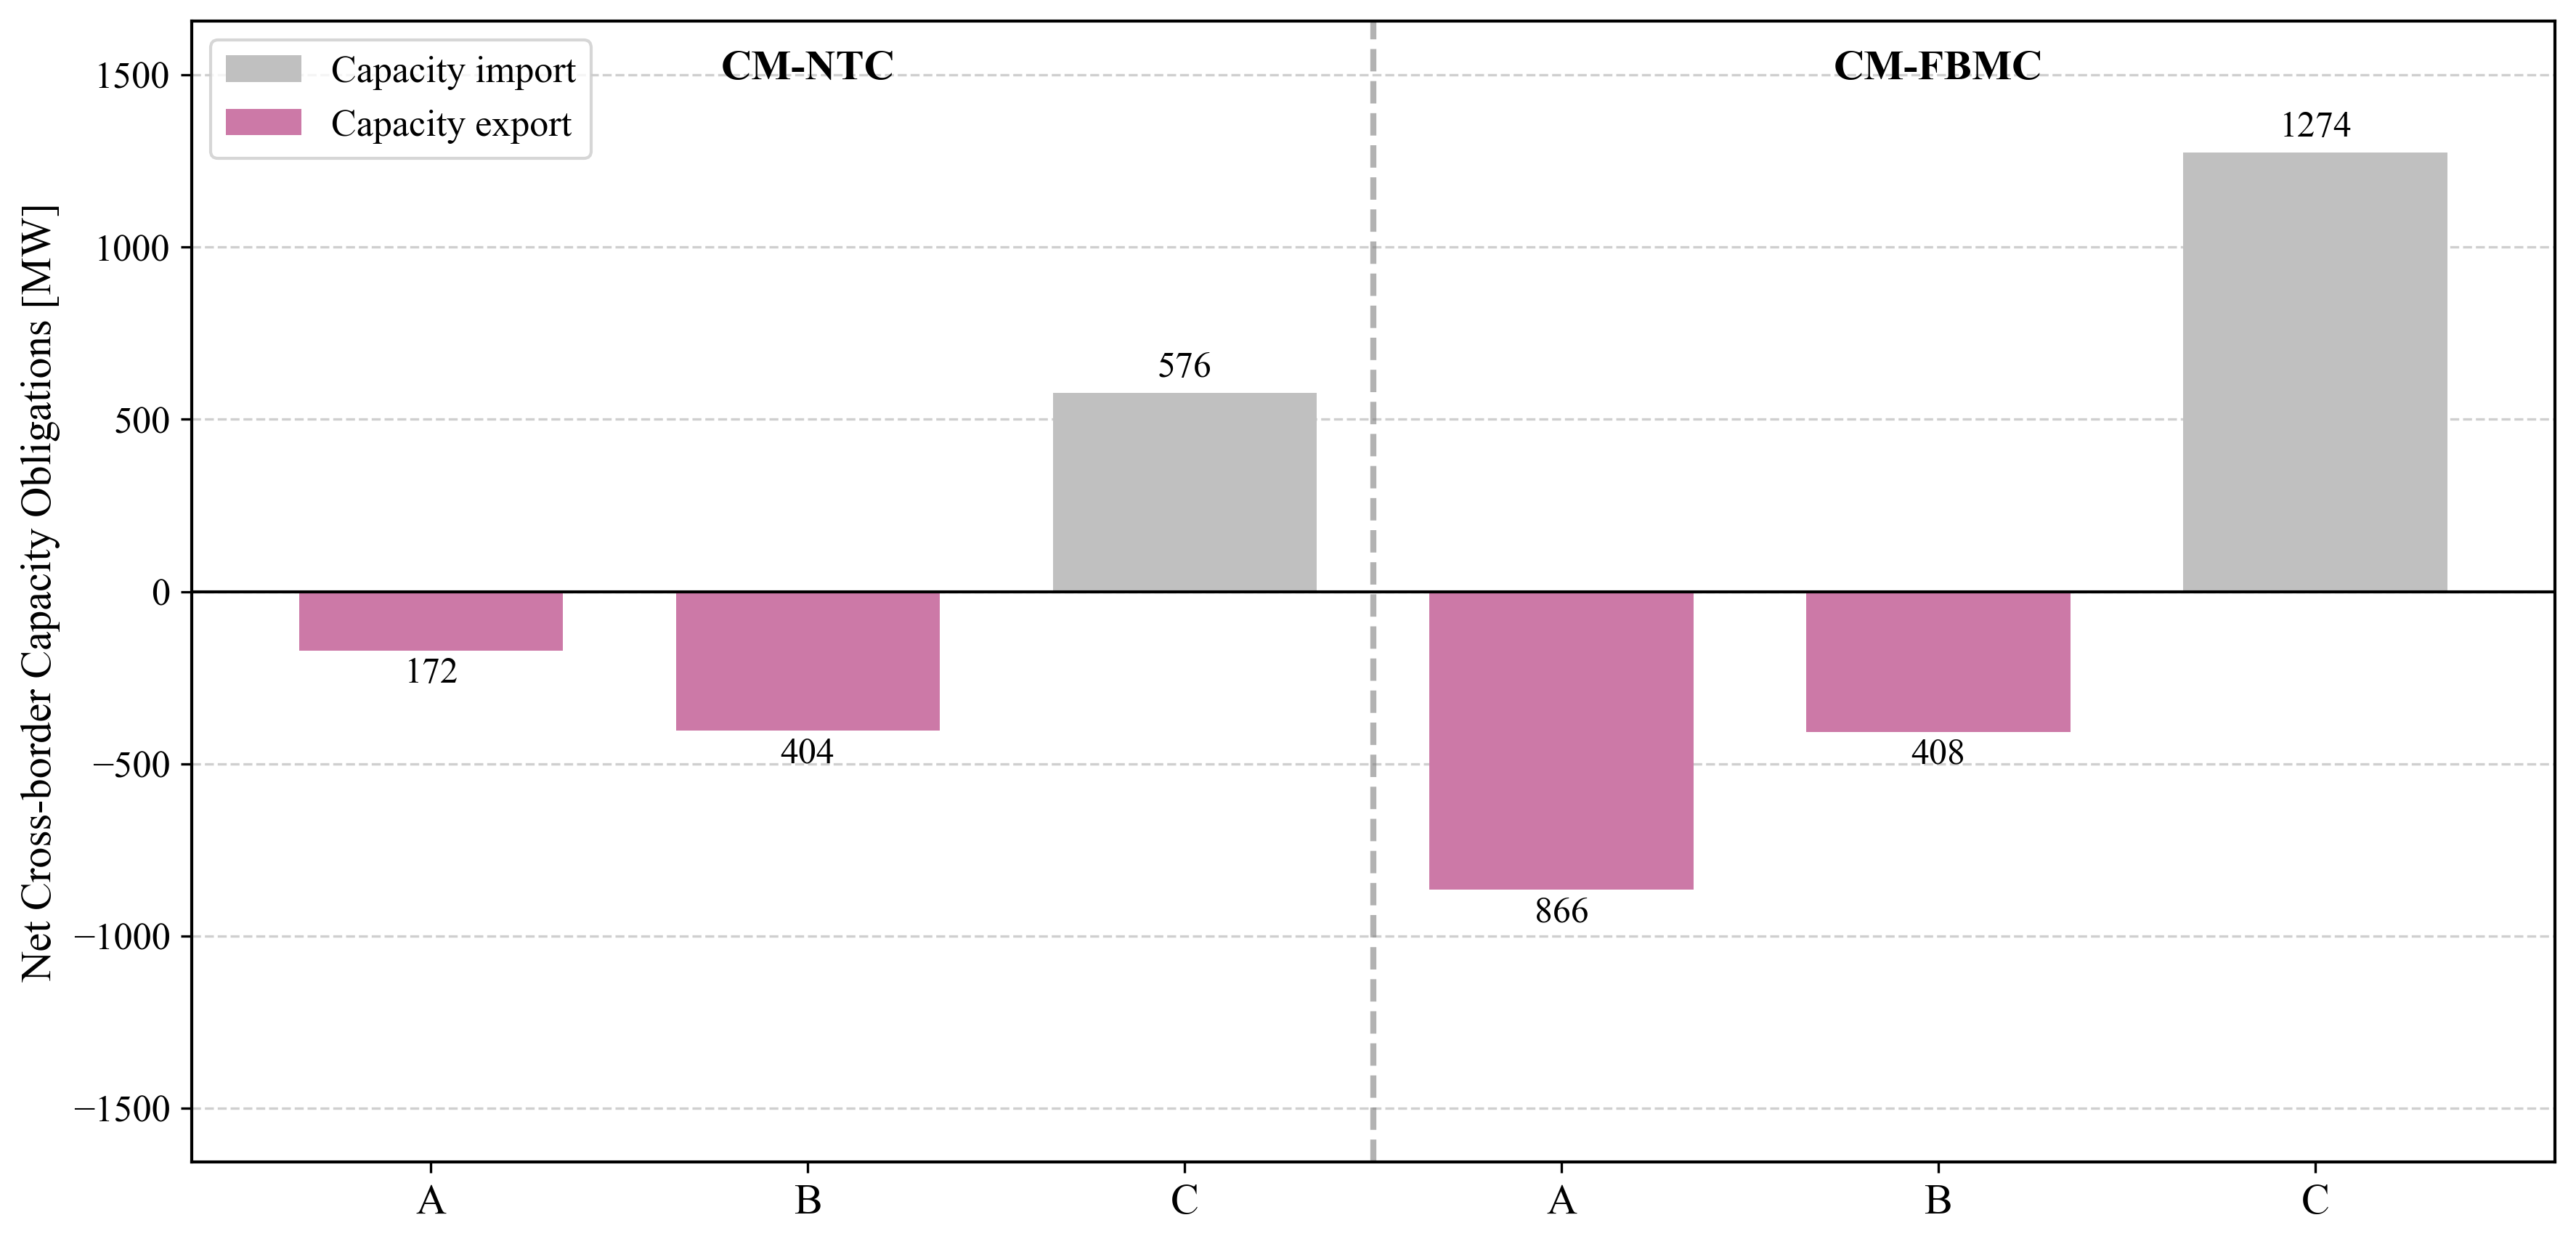

In [33]:
# Visualize capacity net positions for MCP model
print("\n=== MCP Capacity Trade (FBMC & NTC) ===")
fig, ax = plot_capacity_net_positions(analysis_data, source_type="mcp")
plt.show()

=== Planner Capacity Trade (FBMC & NTC) ===


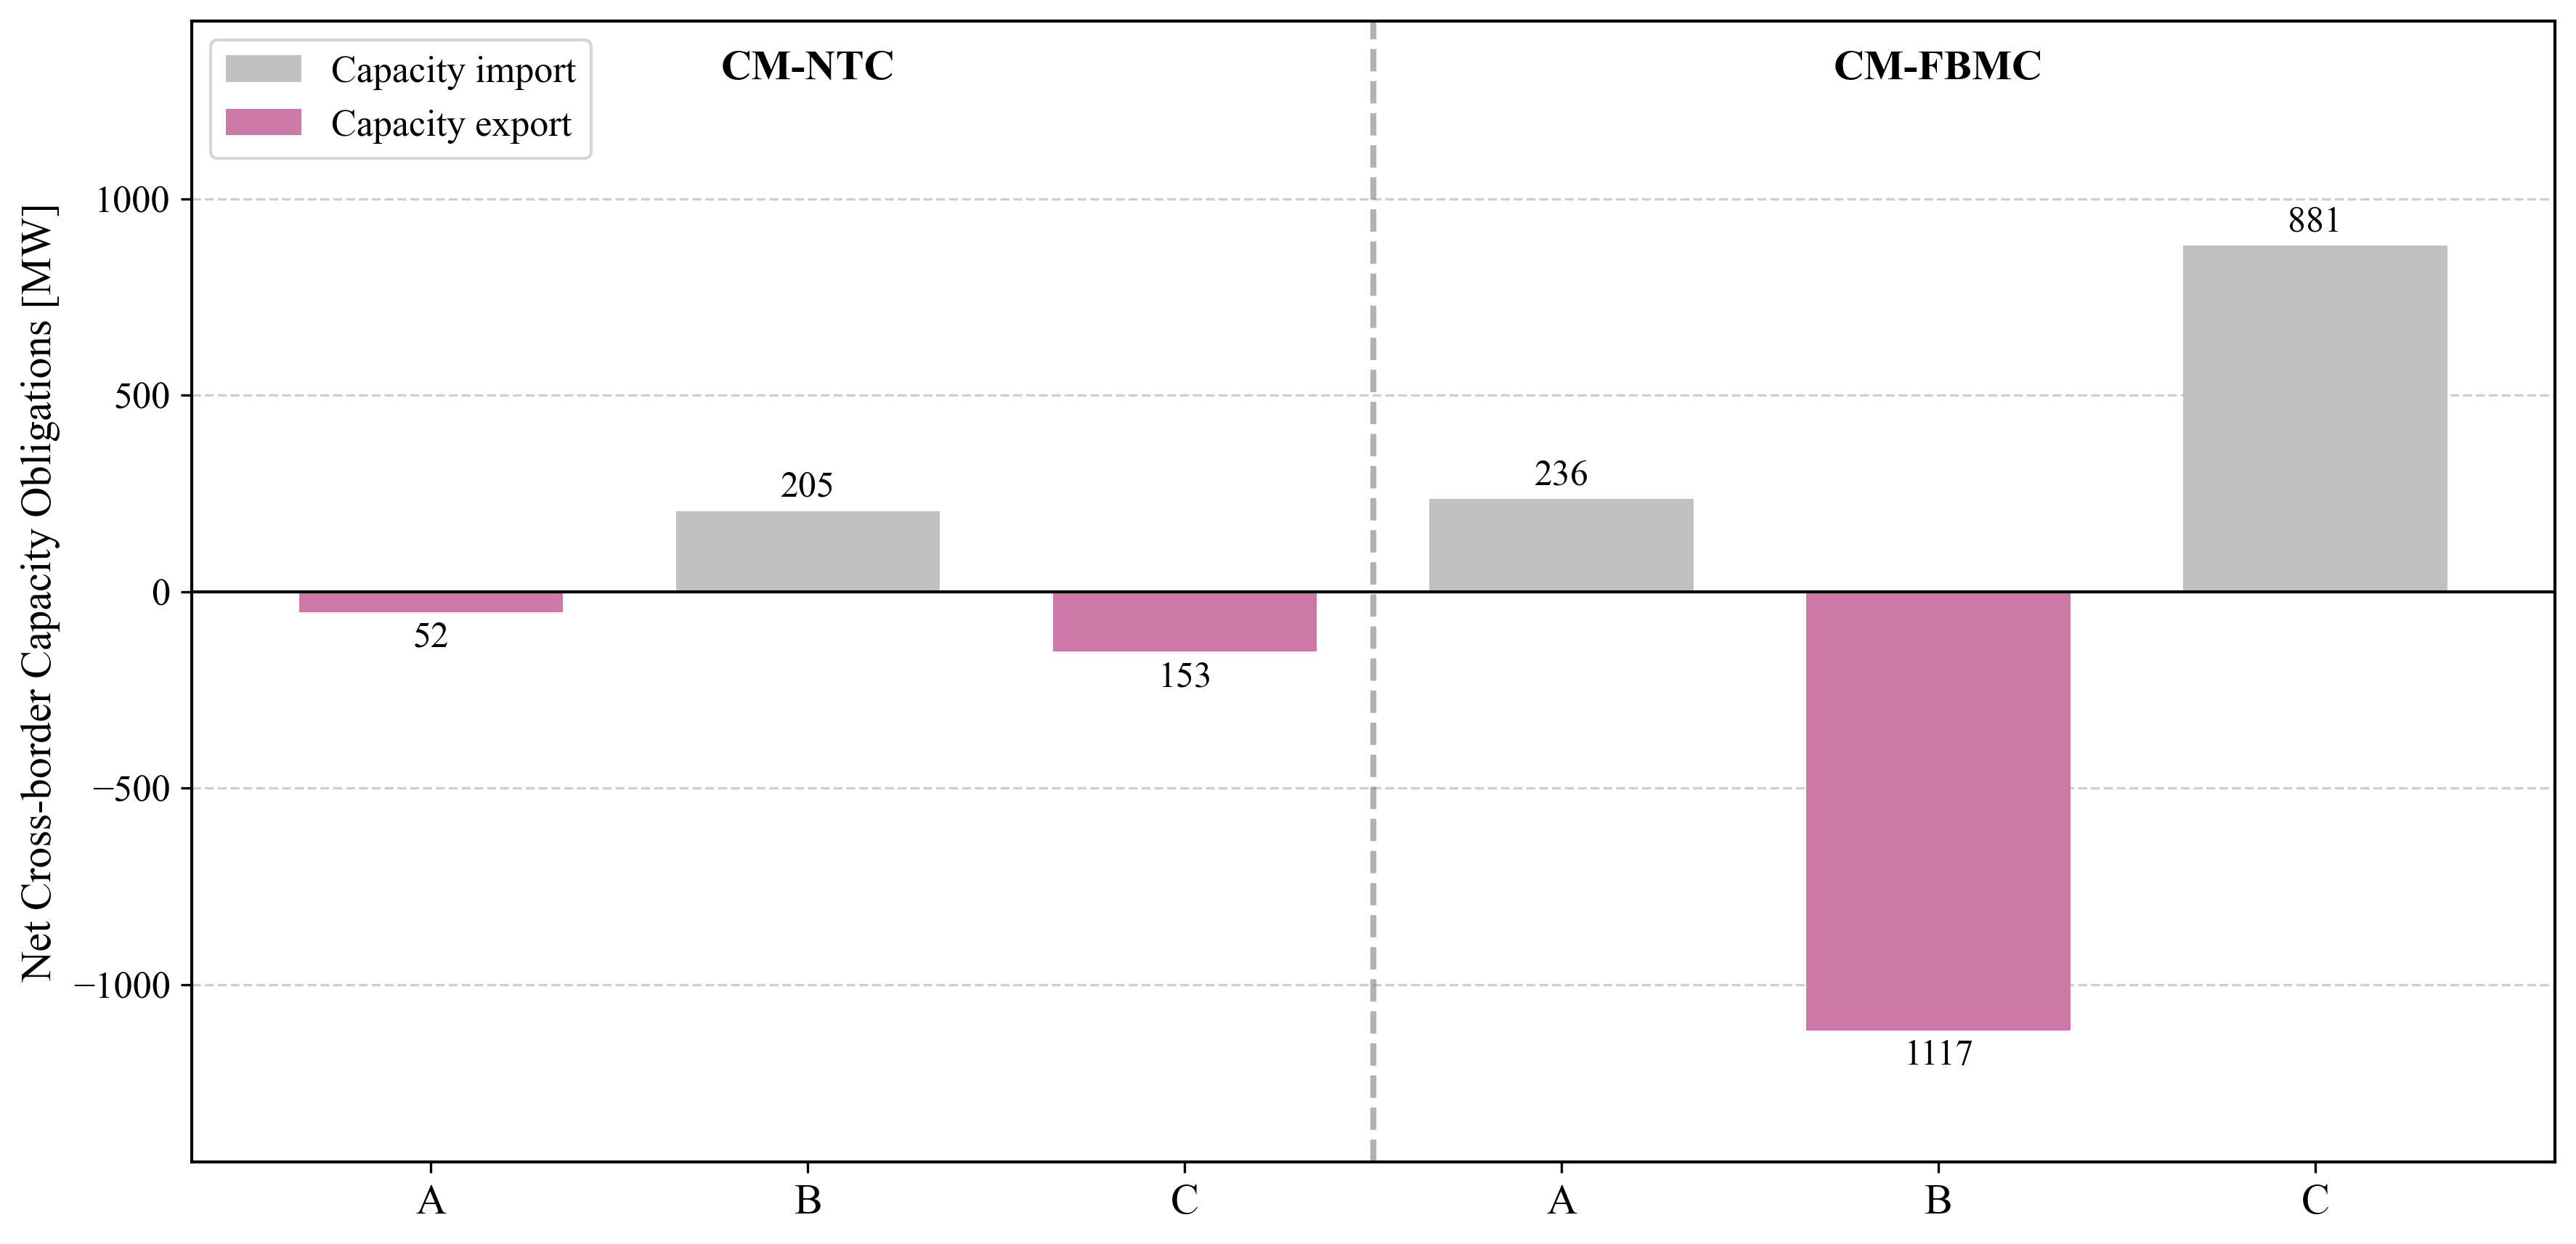

In [34]:
# Visualize capacity net positions for Planner model
print("=== Planner Capacity Trade (FBMC & NTC) ===")
fig, ax = plot_capacity_net_positions(analysis_data, source_type="planner")
plt.show()


#### Demand Analysis

In [35]:
def residual_demand(data: Dict[str, pd.DataFrame], source_type: str = "planner") -> Dict[str, Dict[str, np.ndarray]]:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Initialize result dictionary
    result = {design: {zone: None for zone in zones} for design in design_keys}
    load_df = inputs["load"]
    
    # Process each design and zone
    for design in design_keys:
        for zone in zones:
            
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key in data:
                # Get the load for this zone from the INPUT load.csv file
                zone_load = load_df[zone].values if zone in load_df.columns else np.zeros(len(load_df))
                # print(zone_load)
                # Calculate renewable generation for this zone from results
                wind_col = f"Gen_{zone}_WindOnshore"
                pv_col = f"Gen_{zone}_PV"
                
                # Check if renewable generation columns exist
                wind = data[key][wind_col].values if wind_col in data[key].columns else np.zeros_like(zone_load)
                pv = data[key][pv_col].values if pv_col in data[key].columns else np.zeros_like(zone_load)
                
                # Calculate residual load at time step
                total_ren_gen = wind + pv
                result[design][zone] = np.maximum(zone_load - total_ren_gen, 0.0)
    
    return result

In [36]:
def plot_residual_load(residual_loads: Dict[str, Dict[str, np.ndarray]], design: str = "eom"):
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    # Define custom zone colors
    zone_colors = {
        "A": "#0072B2",         # Dark Blue
        "B": "#009E73",         # Bluish-Green
        "C": "#D55E00",         # Vermilion
    }
    
    # Get zone-specific weights
    weights_dict = inputs["weights"]
    
    for zone in ["A", "B", "C"]:
        if residual_loads[design][zone] is not None:
            loads = residual_loads[design][zone]
            weights = weights_dict[zone][:len(loads)]  # Use zone-specific weights
            
            # Apply weights to create weighted duration curve
            # Sort load values in descending order along with their weights
            sorted_indices = np.argsort(loads)[::-1]
            sorted_loads = loads[sorted_indices]
            sorted_weights = weights[sorted_indices]
            
            # Calculate cumulative weights for x-axis percentages
            cumulative_weights = np.cumsum(sorted_weights)
            percent_duration = 100.0 * cumulative_weights / cumulative_weights[-1]
            
            # Plot the weighted duration curve
            ax.plot(percent_duration, sorted_loads, label=f"Zone {zone}", 
                    color=zone_colors[zone], linewidth=3)
    
    # Add zero line for better visualization
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel("Duration (%)", fontsize=FONT_SIZES['axis_label'])
    ax.set_ylabel("Residual Load (GW)", fontsize=FONT_SIZES['axis_label'])
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

    # Format y-axis ticks in GW
    def GW_formatter(x, pos):
        return f'{x/1e3:.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(GW_formatter))
    
    plt.tight_layout()
    plt.show()

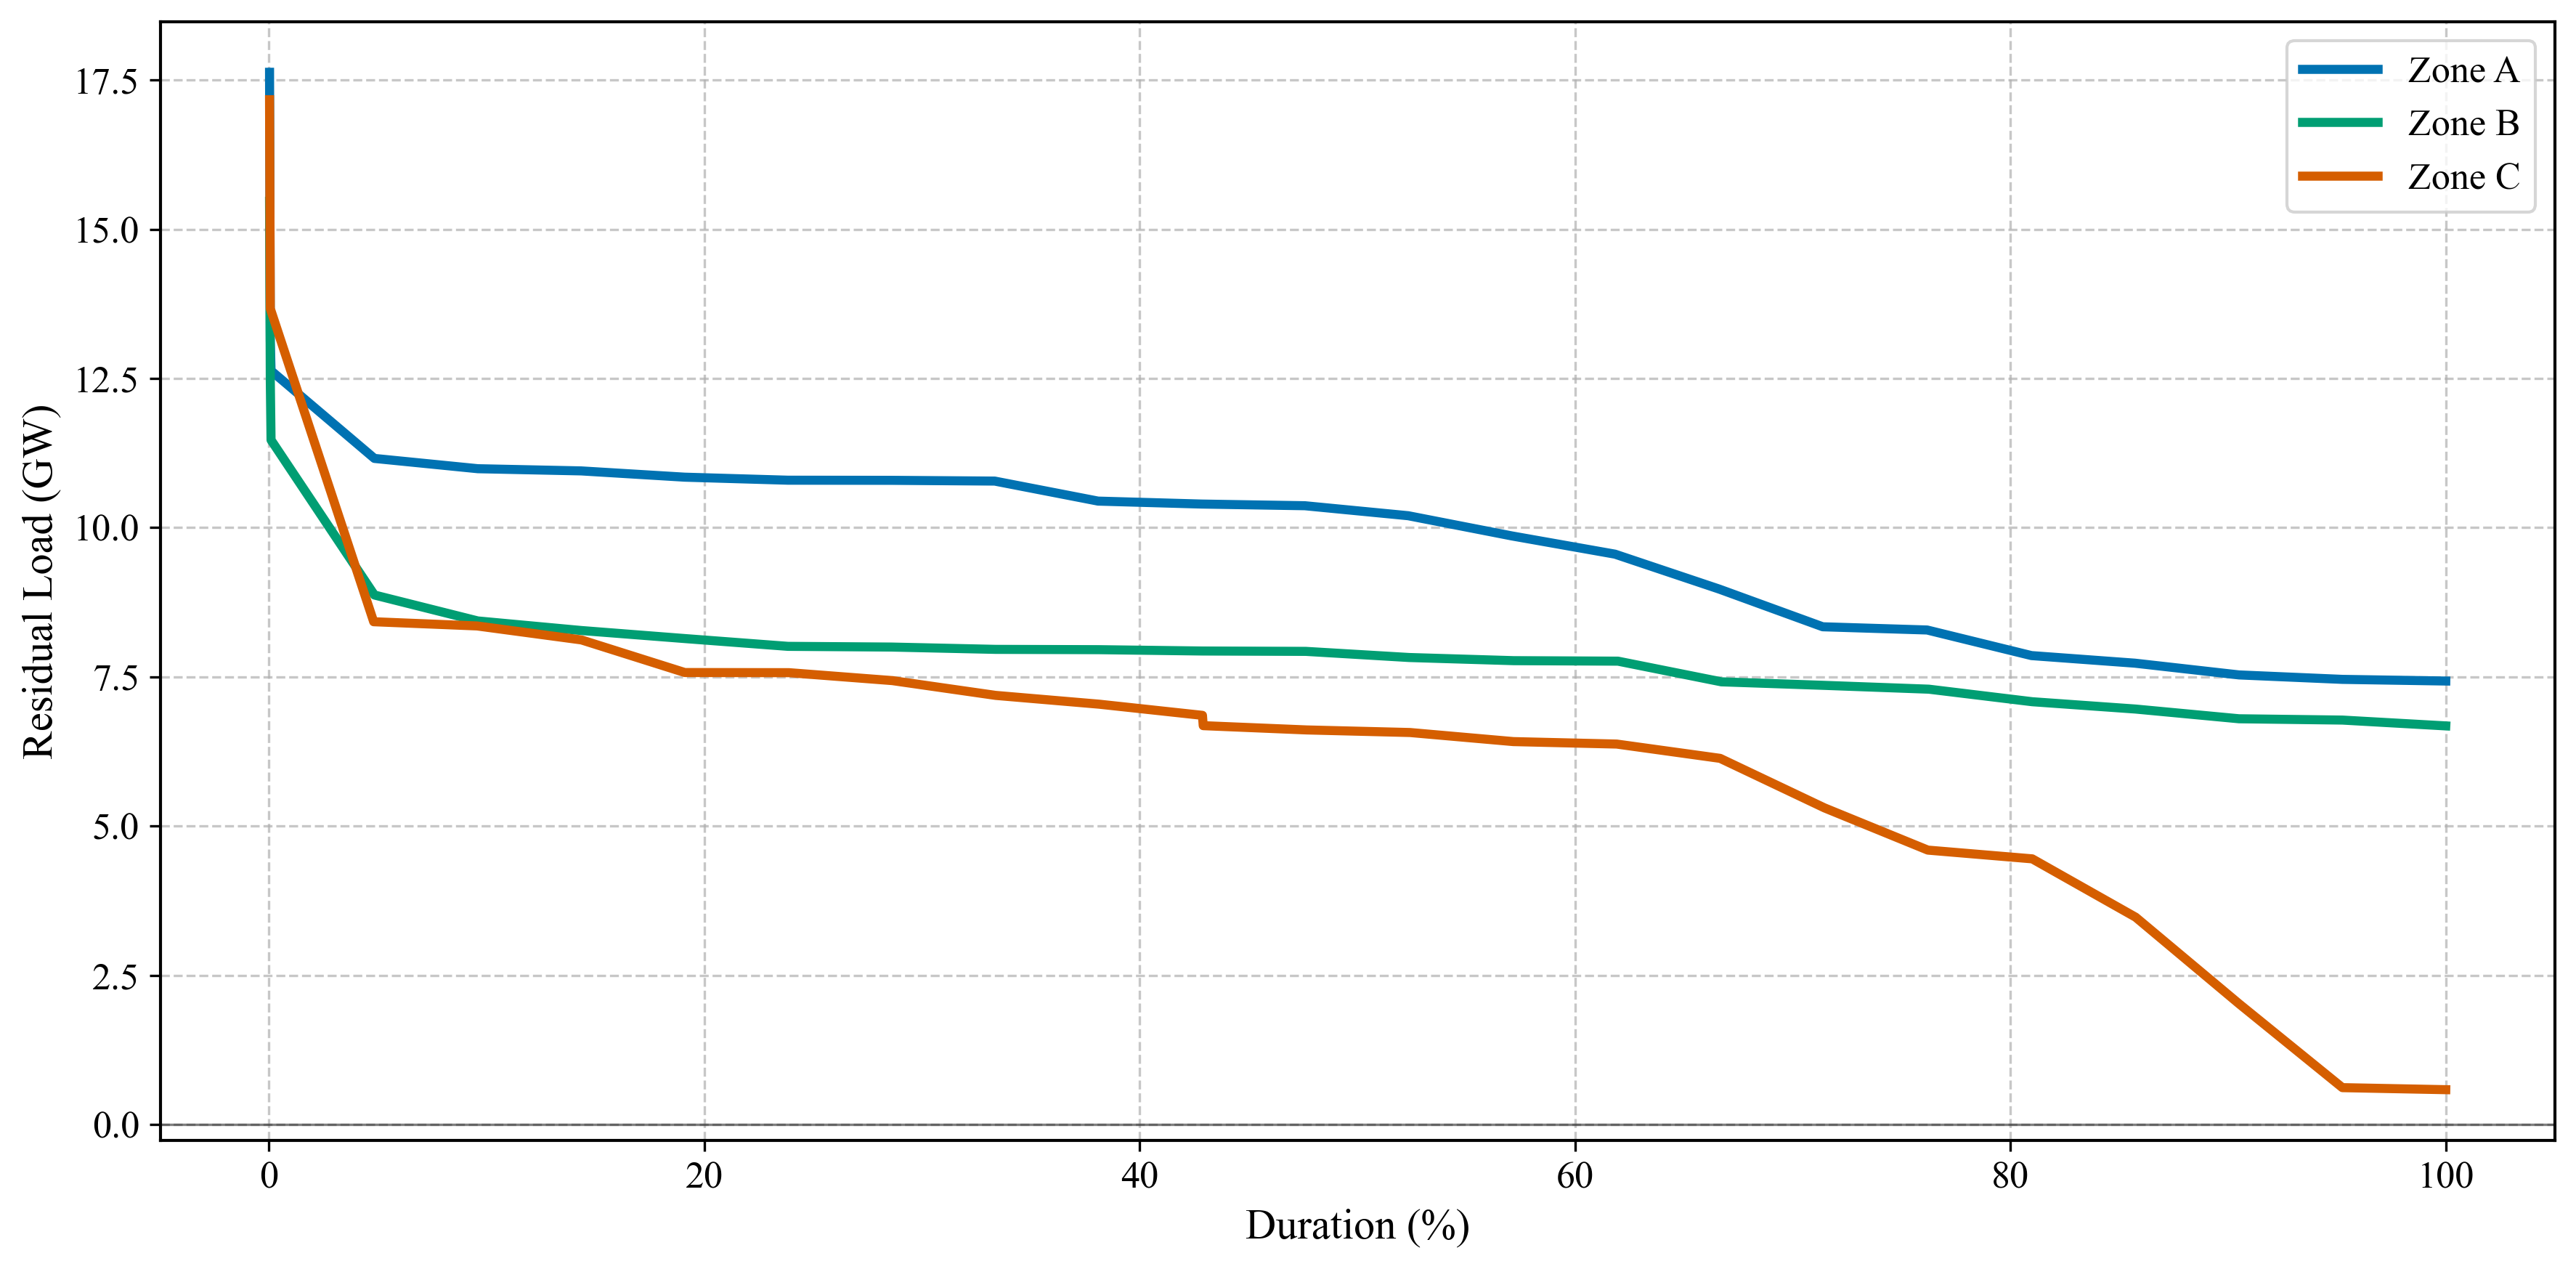

In [37]:
# Calculate residual loads if not already done
res_loads = residual_demand(analysis_data, source_type="planner")
# Plot for different designs
plot_residual_load(res_loads, design="eom")
# plot_residual_load(res_loads, design="pricecap")

In [38]:

# Calculate capacity demand for each zone using peak load from load.csv
# Capacity demand = Peak demand + ENS - renewable generation during peak - imports during peak
# Using FBMC to obtain capacity demand for implicit capacity demand estimation.

def capacity_demand(analysis_data: Dict[str, pd.DataFrame]):
    zones = ["A", "B", "C"]
    load_df = inputs["load"]

    for design in ["eom"]:  # Just check one design type
        for zone in zones:
            # Get peak load from original load CSV
            if zone not in load_df.columns:
                print(f"Warning: Zone {zone} not found in load data")
                continue
                
            peak_load_csv = load_df[zone].max()
            peak_hour_csv = load_df[zone].idxmax()
            print(f"Zone {zone} peak load from CSV: {peak_load_csv:.2f} MW at hour {peak_hour_csv + 1}")
            
            key = f"planner_zone_{zone}_{design}"
            # key = f"mcp_zone_{zone}_{design}"
            
            if key not in analysis_data:
                print(f"Warning: {key} not found in analysis data")
                continue
                
            # Get consumption data
            cons_col = f"Cons_{zone}"
            if cons_col not in analysis_data[key].columns:
                print(f"Warning: {cons_col} not found in {key}")
                continue
                
            # Find the peak consumption index in the analysis data
            peak_index = analysis_data[key][cons_col].idxmax()
            
            # Get ENS at peak time
            ens_col = f"ENS_Cons_{zone}"
            ens = abs(analysis_data[key].at[peak_index, ens_col]) if ens_col in analysis_data[key].columns else 0
            
            # Adjust peak load for ENS
            peak_load_total = peak_load_csv # + ens
            
            # Get renewable generation at peak load time
            wind_col = f"Gen_{zone}_WindOnshore"
            pv_col = f"Gen_{zone}_PV"
            
            wind_gen = analysis_data[key].at[peak_index, wind_col] if wind_col in analysis_data[key].columns else 0
            pv_gen = analysis_data[key].at[peak_index, pv_col] if pv_col in analysis_data[key].columns else 0
            total_ren_gen = wind_gen + pv_gen
            
            # Get network position (imports/exports)
            network_manager_col = "NetworkManager"
            net_pos = analysis_data[key].at[peak_index, network_manager_col] if network_manager_col in analysis_data[key].columns else 0
            
            # Calculate residual peak demand
            residual_peak = peak_load_total - total_ren_gen  # Implicit capacity demand
            implicit = residual_peak - net_pos  # Adjust for imports during scarcity (positive = import)
            
            # Print results
            print(f"Zone {zone}:")
            print(f"  Peak load (from CSV): {peak_load_csv:.2f} MW")
            print(f"  ENS at peak: {ens:.2f} MW")
            print(f"  Total peak load (incl. ENS): {peak_load_total:.2f} MW")
            print(f"  Renewable generation during peak: {total_ren_gen:.2f} MW")
            print(f"  Capacity demand (explicit): {residual_peak:.2f} MW")
            print(f"  Net import during scarcity: {net_pos:.2f} MW")
            print(f"  Capacity demand (implicit): {implicit:.2f} MW")
            print()

# Call the function
capacity_demand(analysis_data)

Zone A peak load from CSV: 19000.01 MW at hour 12
Zone A:
  Peak load (from CSV): 19000.01 MW
  ENS at peak: 0.00 MW
  Total peak load (incl. ENS): 19000.01 MW
  Renewable generation during peak: 1370.14 MW
  Capacity demand (explicit): 17629.87 MW
  Net import during scarcity: 4464.76 MW
  Capacity demand (implicit): 13165.11 MW

Zone B peak load from CSV: 16000.01 MW at hour 19
Zone B:
  Peak load (from CSV): 16000.01 MW
  ENS at peak: 0.00 MW
  Total peak load (incl. ENS): 16000.01 MW
  Renewable generation during peak: 531.55 MW
  Capacity demand (explicit): 15468.46 MW
  Net import during scarcity: 1795.16 MW
  Capacity demand (implicit): 13673.30 MW

Zone C peak load from CSV: 18000.01 MW at hour 18
Zone C:
  Peak load (from CSV): 18000.01 MW
  ENS at peak: 0.00 MW
  Total peak load (incl. ENS): 18000.01 MW
  Renewable generation during peak: 830.09 MW
  Capacity demand (explicit): 17169.92 MW
  Net import during scarcity: 1770.53 MW
  Capacity demand (implicit): 15399.39 MW



#### Cost analysis

In [39]:
# cost of electricity (€)
# electricity_price*weight(€/MWh) * electricity_demand*weight (MWh)


# cost of unserved energy(€)
# ENS*weight(MWh)
# WTP = 20000 (€/MWh)
# cost of unserved energy = WTP * ENS 



# cost of capacity market (€)
# capacity_market_cost = capacity_price (€/MW) * capacity demand (MW)


# total demand served = (elastic + inelastic demand served).weight (MWh)

# Average prices across zones (€/MWh) =  (cost of electricity (€) + cost of unserved energy(€) + cost of capacity market (€)) / total demand served (MWh)


In [40]:
def extract_cost_data(data: Dict[str, pd.DataFrame], source_type: str = "planner") -> Dict[str, Dict[str, pd.DataFrame]]:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Initialize result dictionary
    result = {design: {zone: None for zone in zones} for design in design_keys}
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key in data:
                result[design][zone] = data[key]
            else:
                print(f"Warning: Missing data for {key}")
    
    return result

In [41]:
# electricity_price_ = extract_cost_data(analysis_data, source_type="mcp")

In [42]:
def compute_cost_metrics(cost_data: Dict[str, Dict[str, pd.DataFrame]], weights_dict: Dict[str, np.ndarray], 
                         wtp: float = 20000) -> pd.DataFrame:

    zones = ["A", "B", "C"]
    design_keys = list(cost_data.keys())
    records = []
    
    for design in design_keys:
        zone_records = []  # Track records for this design
        
        for zone in zones:
            if cost_data[design][zone] is None:
                continue
            
            df = cost_data[design][zone]
            W = weights_dict[zone][:len(df)]  # Get zone-specific weights for the correct length
            # print(W)
            # 1. Calculate electricity cost
            elec_price_col = f"EOM_price" if f"EOM_price" in df.columns else "Price"
            elec_demand_col = f"Cons_{zone}" if f"Cons_{zone}" in df.columns else "Demand"

            if elec_price_col in df.columns and elec_demand_col in df.columns:
                # For each timestep: price * demand * zone-specific weight
                electricity_cost = np.sum(df[elec_price_col] * df[elec_demand_col].abs() * W) # (€/MWh * MWh)
            else:
                print(f"Missing columns for electricity cost calculation in {design} - {zone}")
                
            # 2. Calculate unserved energy cost
            ens_col = f"ENS_Cons_{zone}" if f"ENS_Cons_{zone}" in df.columns else "ENS"
            if ens_col in df.columns:
                ens = abs(df[ens_col].values)
                ens_cost = np.sum(ens * W * wtp) # (MWh * €/MWh) with zone-specific weights
                total_ens = np.sum(ens * W)
            else:
                print(f"Missing ENS column in {design} - {zone}")

                
            # 3. Calculate capacity market cost
            cap_price_col = f"CM_price" if f"CM_price" in df.columns else "CapacityPrice"
            cap_demand_col = f"CapDemand_Cons_{zone}" if f"CapDemand_Cons_{zone}" in df.columns else "CapacityDemand"
            
            if cap_price_col in df.columns and cap_demand_col in df.columns:
                cap_price = df[cap_price_col].values[0]
                cap_demand = abs(df[cap_demand_col].values[0])
                capacity_cost = cap_price * cap_demand # (€/MW * MW)
            else:
                print(f"Missing Capacity Market columns in {design} - {zone}")
                capacity_cost = 0
                
            # 4. Calculate total demand served (using electricity demand, not capacity demand)
            total_served = np.sum(abs(df[elec_demand_col].values) * W)  # Use zone-specific weights
            total_unserved = np.sum(ens * W)
            
            # 5. Calculate average price
            total_cost = electricity_cost + ens_cost + capacity_cost
            avg_price = total_cost / total_served if total_served > 0 else 0
            
            record = {
                "Zone": zone,
                "Design": design,
                "ElectricityCost": electricity_cost,
                "ENSCost": ens_cost,
                "CapacityCost": capacity_cost,
                "TotalCost": total_cost,
                "DemandServed": total_served,
                "AveragePrice": avg_price,
                "ENS": total_ens
            }
            
            records.append(record)
            zone_records.append(record)
        
        
        # Calculate system-wide metrics for this design (one per design)
        if zone_records:  # Only if we have zone records for this design
            elec_cost_sum = sum(r["ElectricityCost"] for r in zone_records)
            ens_cost_sum = sum(r["ENSCost"] for r in zone_records)
            cap_cost_sum = sum(r["CapacityCost"] for r in zone_records)
            total_cost_sum = sum(r["TotalCost"] for r in zone_records)
            demand_served_sum = sum(r["DemandServed"] for r in zone_records)
            total_ens = sum(r["ENS"] for r in zone_records)

            avg_price = total_cost_sum / demand_served_sum if demand_served_sum > 0 else 0
            
            records.append({
                "Zone": "System",
                "Design": design,
                "ElectricityCost": elec_cost_sum,
                "ENSCost": ens_cost_sum,
                "CapacityCost": cap_cost_sum,
                "TotalCost": total_cost_sum,
                "DemandServed": demand_served_sum,
                "AveragePrice": avg_price,
                "ENS": total_ens
            })
    
    return pd.DataFrame(records)

In [43]:
compute_cost_metrics(extract_cost_data(analysis_data, source_type="mcp"), inputs["weights"])

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,1.003171e+10,0.000000e+00,0.000000e+00,1.003171e+10,1.032581e+08,97.151744,0.000000e+00
1,B,eom,7.478898e+09,0.000000e+00,0.000000e+00,7.478898e+09,7.524334e+07,99.396154,0.000000e+00
2,C,eom,9.256105e+09,0.000000e+00,0.000000e+00,9.256105e+09,9.316496e+07,99.351786,0.000000e+00
3,System,eom,2.676671e+10,0.000000e+00,0.000000e+00,2.676671e+10,2.716664e+08,98.527857,0.000000e+00
4,A,pricecap,9.967769e+09,8.835872e+08,0.000000e+00,1.085136e+10,1.032138e+08,105.134777,4.417936e+04
5,B,pricecap,7.212872e+09,5.691392e+08,0.000000e+00,7.782011e+09,7.521742e+07,103.460227,2.845696e+04
6,C,pricecap,9.041068e+09,7.379947e+08,0.000000e+00,9.779062e+09,9.312987e+07,105.004576,3.689973e+04
7,System,pricecap,2.622171e+10,2.190721e+09,0.000000e+00,2.841243e+10,2.715610e+08,104.626306,1.095361e+05
8,A,NoCBP,9.149004e+09,6.548362e-07,1.234091e+09,1.038310e+10,1.032681e+08,100.545008,3.274181e-11
9,B,NoCBP,6.594359e+09,0.000000e+00,1.082792e+09,7.677151e+09,7.525340e+07,102.017322,0.000000e+00


In [44]:
def plot_average_cost_by_zone(cost_metrics: pd.DataFrame):
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

    zones = ["A", "B", "C", "System"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors - solid colors (no shading)
    base_colors = {
        "A": "#0072B2",         # Dark Blue
        "B": "#009E73",         # Bluish-Green
        "C": "#D55E00",         # Vermilion
        "System": "#CC79A7"     # Rose
    }

    hatches = {
        "ENERGY": "",          # Empty string = no hatch
        "CM": "//",           # Dots
        "ENS": "xxx"           # Diagonal
    }
    

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = cost_metrics[cost_metrics["Zone"] == zone]
        zone_start_x = current_x
        base_color = base_colors[zone]

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            energy = row["ElectricityCost"].values[0] / row["DemandServed"].values[0]
            ens = row["ENSCost"].values[0] / row["DemandServed"].values[0]
            cm = row["CapacityCost"].values[0] / row["DemandServed"].values[0]
            total = energy + ens + cm

            # Bars with hatching patterns - all using same base color per zone
            ax.bar(current_x, energy, width=bar_width, color=base_color, 
                   hatch=hatches["ENERGY"], edgecolor='black', linewidth=0.3)
            ax.bar(current_x, ens, width=bar_width, bottom=energy, color=base_color, 
                   hatch=hatches["ENS"], edgecolor='black', linewidth=0.3)
            ax.bar(current_x, cm, width=bar_width, bottom=energy + ens, color=base_color, 
                   hatch=hatches["CM"], edgecolor='black', linewidth=0.3)

            # Label total on top
            ax.text(current_x, total + 1, f"{total:.1f}", ha="center", va="bottom", 
                    fontsize=FONT_SIZES['annotation'])

            # Record positions
            x_positions.append(current_x)
            x_labels.append(map_policy_name(design))
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"{zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['tick_label'], rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):
                                   int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.3, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Cost to Consumers (€/MWh)', fontsize=FONT_SIZES['axis_label'])
    ax.set_ylim(70, max(cost_metrics["AveragePrice"]) * 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Custom legend with hatching patterns
    legend_elements = [
        # Cost components with hatching (using neutral gray color for legend)
        Patch(facecolor='white', hatch=hatches["ENERGY"], edgecolor='black', linewidth=0.3, label='Energy cost'),
        Patch(facecolor='white', hatch=hatches["CM"], edgecolor='black', linewidth=0.3, label='Capacity cost'),
        Patch(facecolor='white', hatch=hatches["ENS"], edgecolor='black', linewidth=0.3, label='Cost of unserved energy')
    ]
    
    ax.legend(handles=legend_elements, loc='lower left', fontsize=FONT_SIZES['tick_label'])

    plt.tight_layout()
    return fig, ax

def analyze_costs(analysis_data, inputs, source_type=""):
    # Extract cost data
    cost_data = extract_cost_data(analysis_data, source_type)
    
    # Compute cost metrics
    cost_metrics = compute_cost_metrics(cost_data, inputs["weights"])
    
    # Create visualizations
    fig, ax = plot_average_cost_by_zone(cost_metrics)
    plt.show()  # Add this to ensure plot is displayed
    return cost_metrics

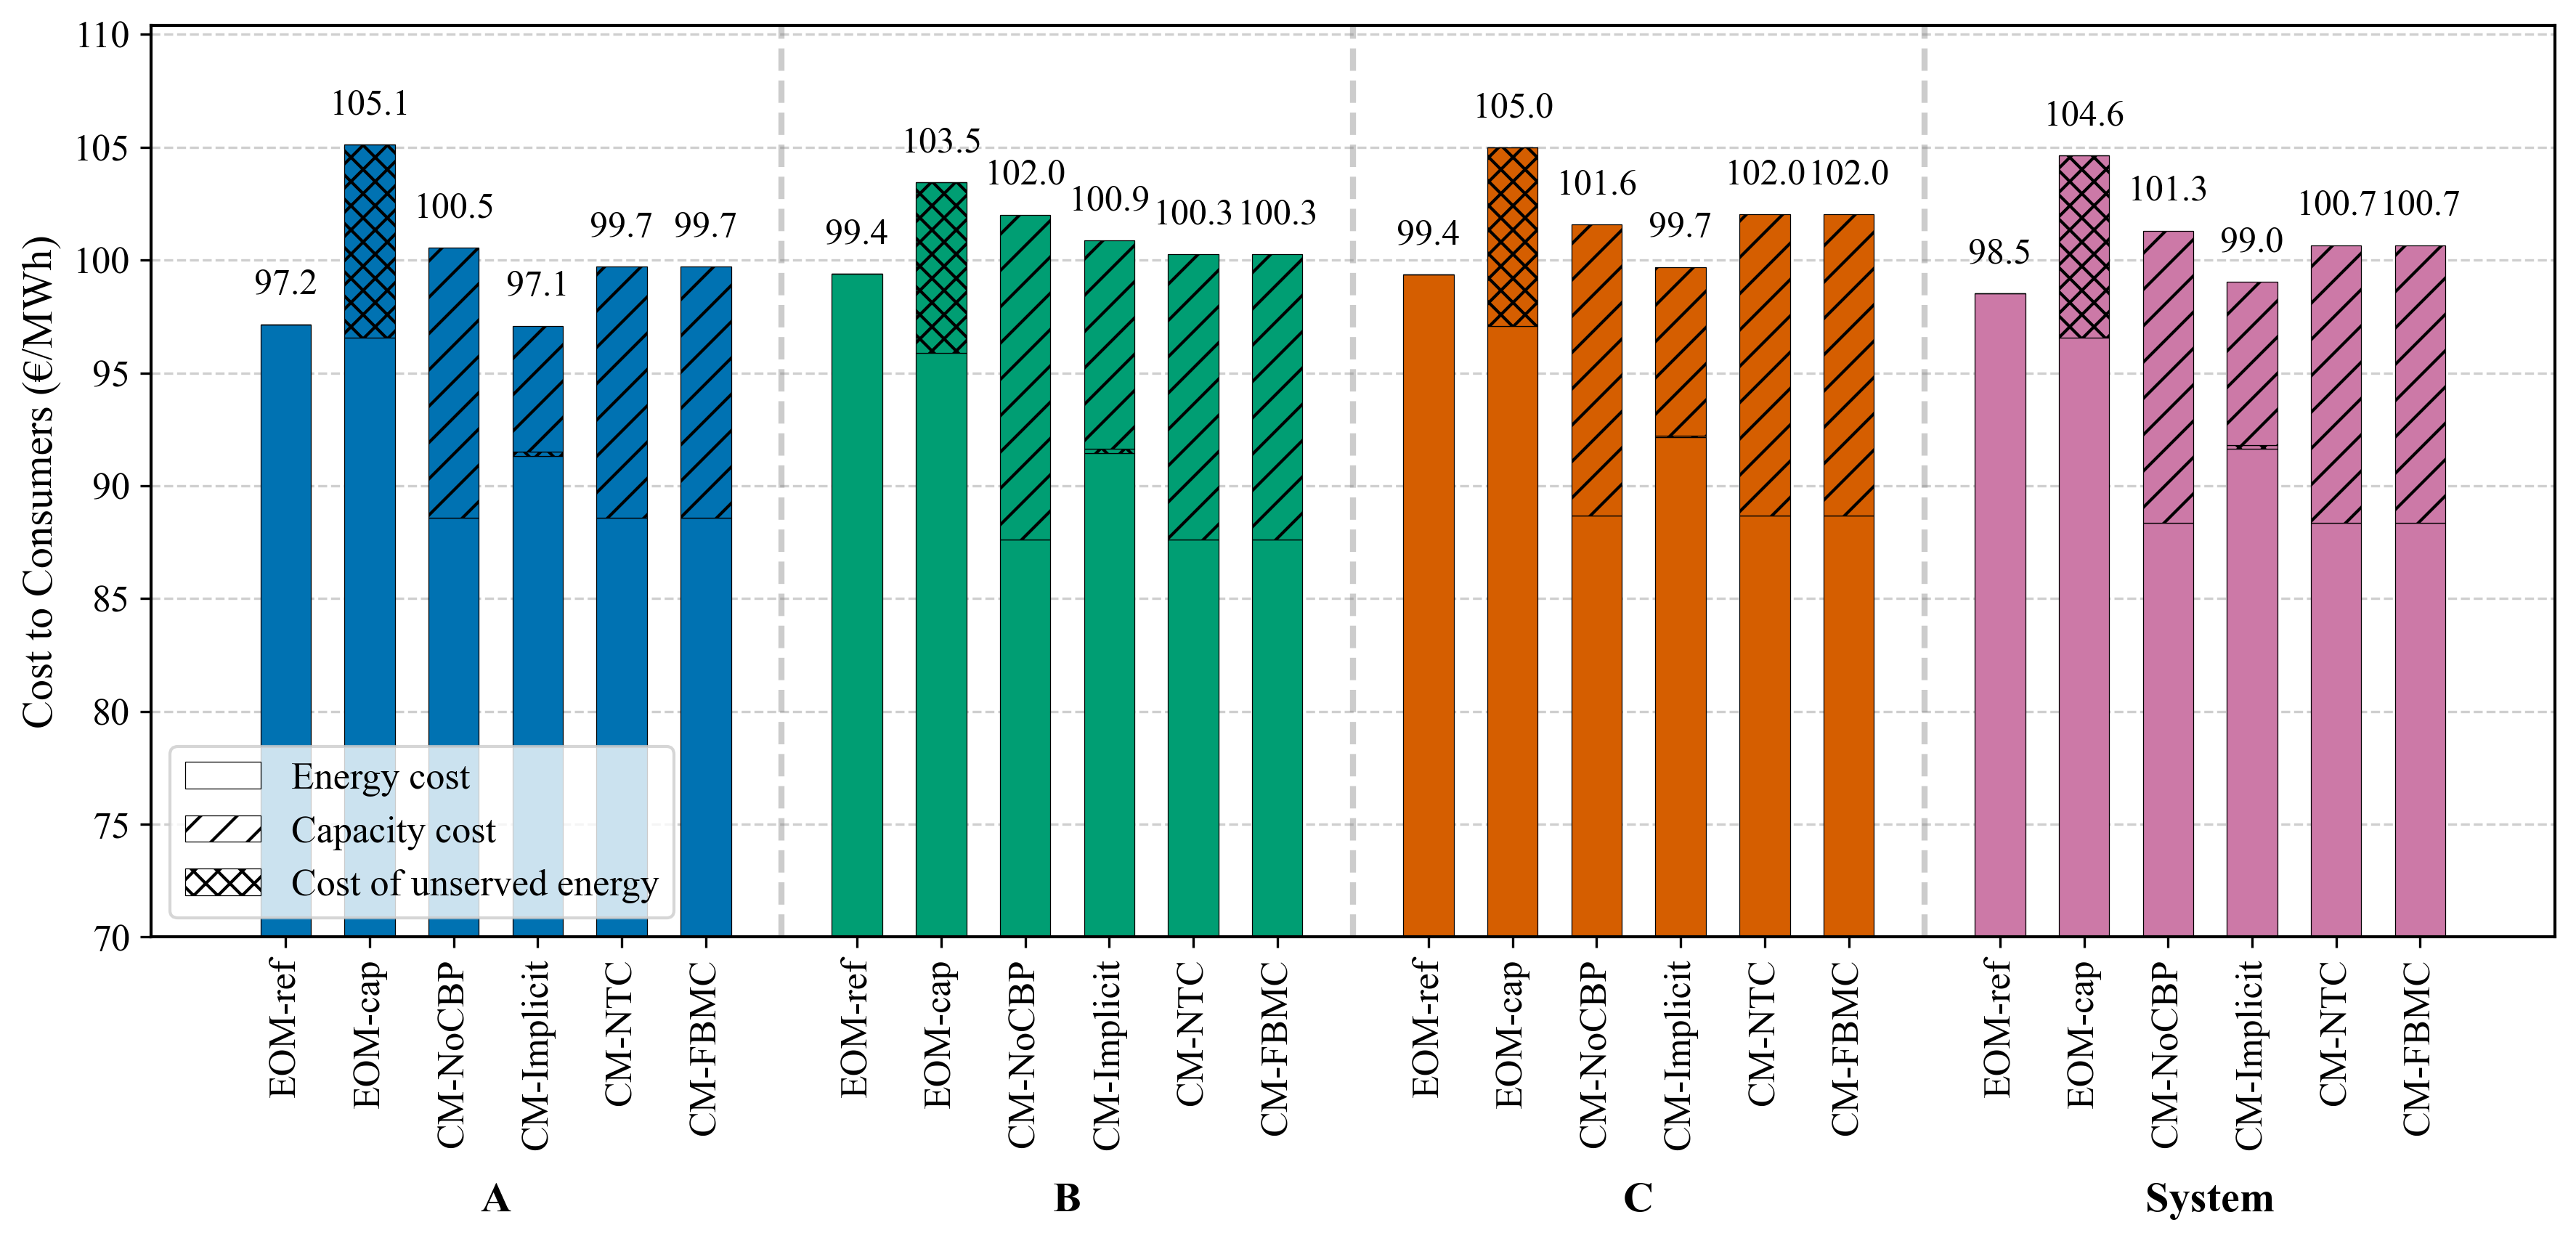

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,1.003171e+10,0.000000e+00,0.000000e+00,1.003171e+10,1.032581e+08,97.151744,0.000000e+00
1,B,eom,7.478898e+09,0.000000e+00,0.000000e+00,7.478898e+09,7.524334e+07,99.396154,0.000000e+00
2,C,eom,9.256105e+09,0.000000e+00,0.000000e+00,9.256105e+09,9.316496e+07,99.351786,0.000000e+00
3,System,eom,2.676671e+10,0.000000e+00,0.000000e+00,2.676671e+10,2.716664e+08,98.527857,0.000000e+00
4,A,pricecap,9.967769e+09,8.835872e+08,0.000000e+00,1.085136e+10,1.032138e+08,105.134777,4.417936e+04
5,B,pricecap,7.212872e+09,5.691392e+08,0.000000e+00,7.782011e+09,7.521742e+07,103.460227,2.845696e+04
6,C,pricecap,9.041068e+09,7.379947e+08,0.000000e+00,9.779062e+09,9.312987e+07,105.004576,3.689973e+04
7,System,pricecap,2.622171e+10,2.190721e+09,0.000000e+00,2.841243e+10,2.715610e+08,104.626306,1.095361e+05
8,A,NoCBP,9.149004e+09,6.548362e-07,1.234091e+09,1.038310e+10,1.032681e+08,100.545008,3.274181e-11
9,B,NoCBP,6.594359e+09,0.000000e+00,1.082792e+09,7.677151e+09,7.525340e+07,102.017322,0.000000e+00


In [45]:
analyze_costs(analysis_data, inputs, source_type="mcp")

Missing Capacity Market columns in eom - A
Missing Capacity Market columns in eom - B
Missing Capacity Market columns in eom - C
Missing Capacity Market columns in pricecap - A
Missing Capacity Market columns in pricecap - B
Missing Capacity Market columns in pricecap - C


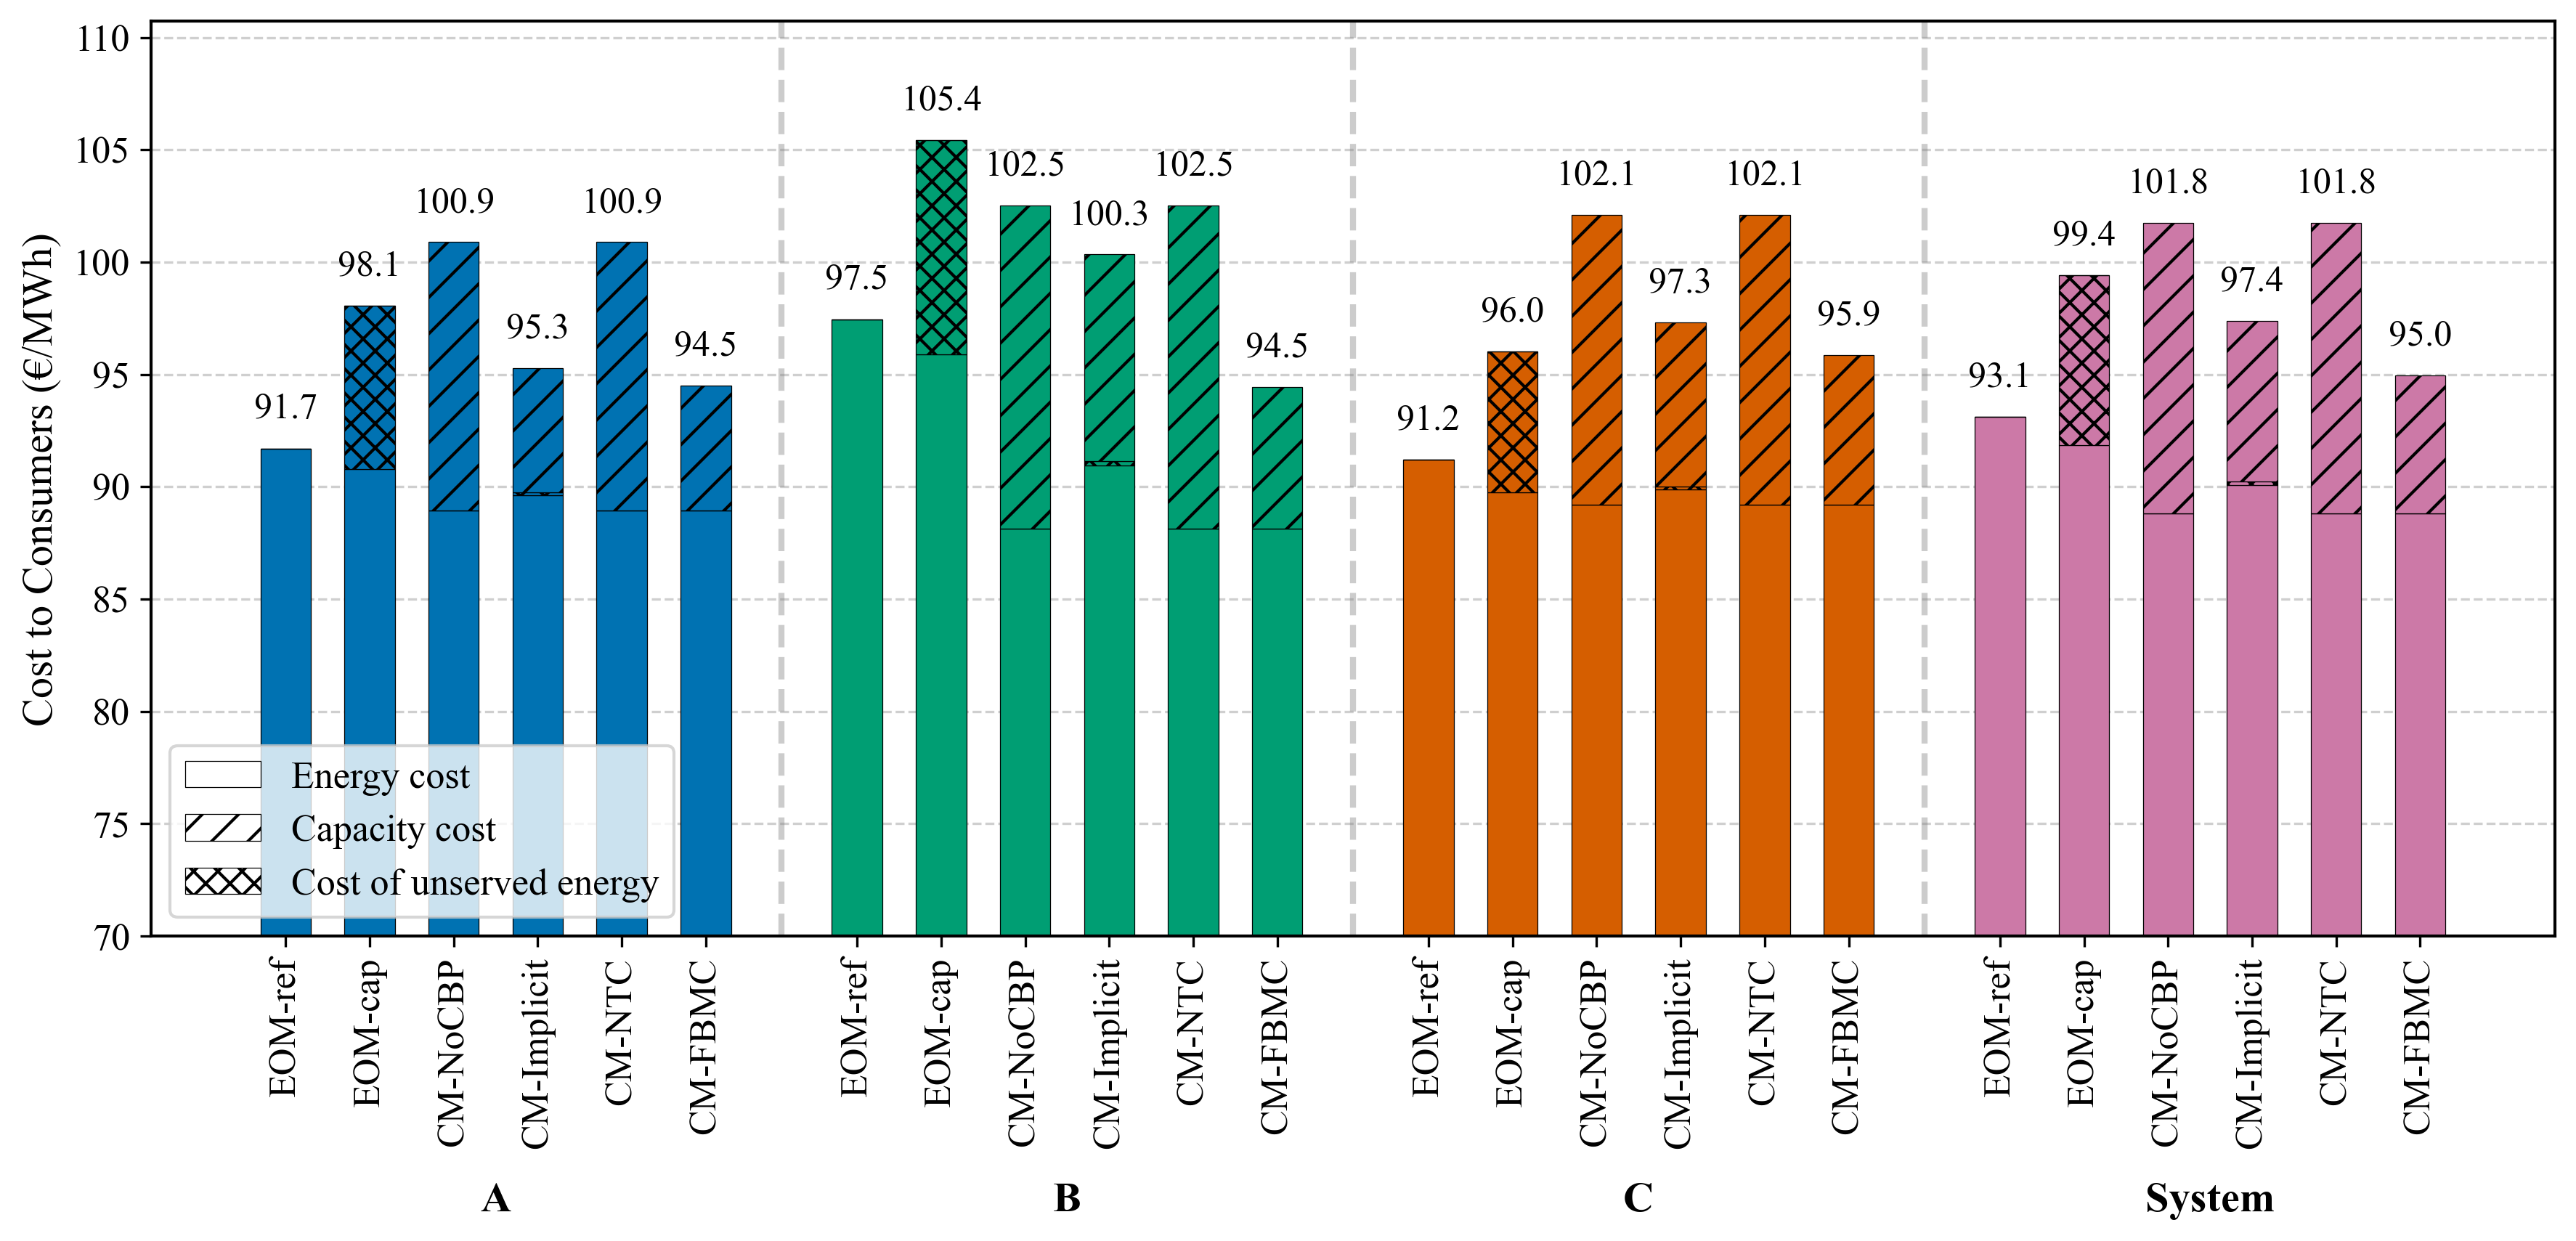

,Zone,Design,ElectricityCost,ENSCost,CapacityCost,TotalCost,DemandServed,AveragePrice,ENS
0,A,eom,9.468563e+09,0.000000e+00,0.000000e+00,9.468563e+09,1.032571e+08,91.698891,0.00
1,B,eom,7.333050e+09,0.000000e+00,0.000000e+00,7.333050e+09,7.524330e+07,97.457844,0.00
2,C,eom,8.496667e+09,0.000000e+00,0.000000e+00,8.496667e+09,9.316477e+07,91.200424,0.00
3,System,eom,2.529828e+10,0.000000e+00,0.000000e+00,2.529828e+10,2.716652e+08,93.123008,0.00
4,A,pricecap,9.371207e+09,7.507590e+08,0.000000e+00,1.012197e+10,1.032201e+08,98.061957,37537.95
5,B,pricecap,7.210818e+09,7.194510e+08,0.000000e+00,7.930269e+09,7.520903e+07,105.443046,35972.55
6,C,pricecap,8.360367e+09,5.827404e+08,0.000000e+00,8.943108e+09,9.313702e+07,96.020978,29137.02
7,System,pricecap,2.494239e+10,2.052950e+09,0.000000e+00,2.699534e+10,2.715662e+08,99.406137,102647.52
8,A,NoCBP,9.184256e+09,0.000000e+00,1.234091e+09,1.041835e+10,1.032678e+08,100.886699,0.00
9,B,NoCBP,6.632037e+09,0.000000e+00,1.082792e+09,7.714829e+09,7.525302e+07,102.518538,0.00


In [46]:
analyze_costs(analysis_data, inputs, source_type="planner")

In [47]:
def compare_mcp_planner_costs(analysis_data, inputs):
    """
    Create a component bar chart comparing MCP and planner cost results
    using hatching patterns for cost components
    """
    # Get cost metrics for both sources
    mcp_metrics = compute_cost_metrics(extract_cost_data(analysis_data, "mcp"), inputs["weights"])
    planner_metrics = compute_cost_metrics(extract_cost_data(analysis_data, "planner"), inputs["weights"])
    
    # Filter to just get system-wide metrics
    mcp_system = mcp_metrics[mcp_metrics["Zone"] == "System"].copy()
    planner_system = planner_metrics[planner_metrics["Zone"] == "System"].copy()
    
    # Prepare data for plotting
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    # Set up parameters for plotting
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    bar_width = 0.35
    x = np.arange(len(design_order))
    
    # Base colors (solid colors, not shades)
    mcp_base = "#CC79A7"          # Rose (MCP color)
    planner_base = "#C0C0C0"      # Gray (Planner color)
    
    # Hatching patterns - cleaner options
    hatches = {
        "ENERGY": "",          # Empty string = no hatch
        "CM": "//",           # Dots
        "ENS": "xxx"           # Diagonal
    }
    
    # Track positions for bar labels
    mcp_heights = {}
    planner_heights = {}
    
    # Plot MCP costs
    for i, design in enumerate(design_order):
        mcp_row = mcp_system[mcp_system["Design"] == design]
        if not mcp_row.empty:
            # Calculate components per MWh
            energy = mcp_row["ElectricityCost"].values[0] / mcp_row["DemandServed"].values[0]
            ens = mcp_row["ENSCost"].values[0] / mcp_row["DemandServed"].values[0]
            cm = mcp_row["CapacityCost"].values[0] / mcp_row["DemandServed"].values[0]
            
            # Plot stacked bars with hatching
            ax.bar(x[i] - bar_width/2, energy, width=bar_width, color=mcp_base, 
                   hatch=hatches["ENERGY"], edgecolor='black', linewidth=0.5,
                   label="MCP ENERGY" if i == 0 else "")
            ax.bar(x[i] - bar_width/2, ens, width=bar_width, bottom=energy, color=mcp_base, 
                   hatch=hatches["ENS"], edgecolor='black', linewidth=0.5,
                   label="MCP ENS" if i == 0 else "")
            ax.bar(x[i] - bar_width/2, cm, width=bar_width, bottom=energy+ens, color=mcp_base, 
                   hatch=hatches["CM"], edgecolor='black', linewidth=0.5,
                   label="MCP CM" if i == 0 else "")
            
            # Store total height for labeling
            mcp_heights[design] = energy + ens + cm
    
    # Plot Planner costs
    for i, design in enumerate(design_order):
        planner_row = planner_system[planner_system["Design"] == design]
        if not planner_row.empty:
            # Calculate components per MWh
            energy = planner_row["ElectricityCost"].values[0] / planner_row["DemandServed"].values[0]
            ens = planner_row["ENSCost"].values[0] / planner_row["DemandServed"].values[0]
            cm = planner_row["CapacityCost"].values[0] / planner_row["DemandServed"].values[0]
            
            # Plot stacked bars with hatching
            ax.bar(x[i] + bar_width/2, energy, width=bar_width, color=planner_base, 
                   hatch=hatches["ENERGY"], edgecolor='black', linewidth=0.5,
                   label="Planner ENERGY" if i == 0 else "")
            ax.bar(x[i] + bar_width/2, ens, width=bar_width, bottom=energy, color=planner_base, 
                   hatch=hatches["ENS"], edgecolor='black', linewidth=0.5,
                   label="Planner ENS" if i == 0 else "")
            ax.bar(x[i] + bar_width/2, cm, width=bar_width, bottom=energy+ens, color=planner_base, 
                   hatch=hatches["CM"], edgecolor='black', linewidth=0.5,
                   label="Planner CM" if i == 0 else "")
            
            # Store total height for labeling
            planner_heights[design] = energy + ens + cm
    
    # Calculate max height for proper y-axis scaling
    max_height = max(max(mcp_heights.values()) if mcp_heights else 0,
                     max(planner_heights.values()) if planner_heights else 0)
    
    ax.set_ylim(70, max_height * 1.05)  # Add 5% padding at the top
    
    # Add labels and values on top of bars
    for i, design in enumerate(design_order):
        if design in mcp_heights:
            ax.text(x[i] - bar_width/2, mcp_heights[design] + max_height * 0.02, 
                    f"{mcp_heights[design]:.1f}", 
                    ha='center', va='bottom', fontsize=FONT_SIZES['annotation'])
        if design in planner_heights:
            ax.text(x[i] + bar_width/2, planner_heights[design] + max_height * 0.02, 
                    f"{planner_heights[design]:.1f}", 
                    ha='center', va='bottom', fontsize=FONT_SIZES['annotation'])
    
    # Customize plot
    ax.set_ylabel('Cost to Consumers (€/MWh)', fontsize=FONT_SIZES['axis_label'])
    ax.set_xticks(x)
    ax.set_xticklabels([map_policy_name(d) for d in design_order], 
                       fontsize=FONT_SIZES['tick_label'], rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    
    # Create comprehensive legend with both models and cost components
    legend_elements = [
        # Model indicators
        Patch(facecolor=mcp_base, edgecolor='black', linewidth=0.5, label='MCP'),
        Patch(facecolor=planner_base, edgecolor='black', linewidth=0.5, label='Planner'),
        # Separator (empty patch)
        Patch(facecolor='none', edgecolor='none', label=''),
        # Cost components with hatching
        Patch(facecolor='gray', hatch=hatches["ENERGY"], edgecolor='black', linewidth=0.5, label='Energy'),
        Patch(facecolor='gray', hatch=hatches["CM"], edgecolor='black', linewidth=0.5, label='Capacity Market'),
        Patch(facecolor='gray', hatch=hatches["ENS"], edgecolor='black', linewidth=0.5, label='Unserved Energy')
    ]

    ax.legend(handles=legend_elements, loc='lower left', fontsize=FONT_SIZES['tick_label'])
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)  # Make room for design labels
    return fig, ax

Missing Capacity Market columns in eom - A
Missing Capacity Market columns in eom - B
Missing Capacity Market columns in eom - C
Missing Capacity Market columns in pricecap - A
Missing Capacity Market columns in pricecap - B
Missing Capacity Market columns in pricecap - C


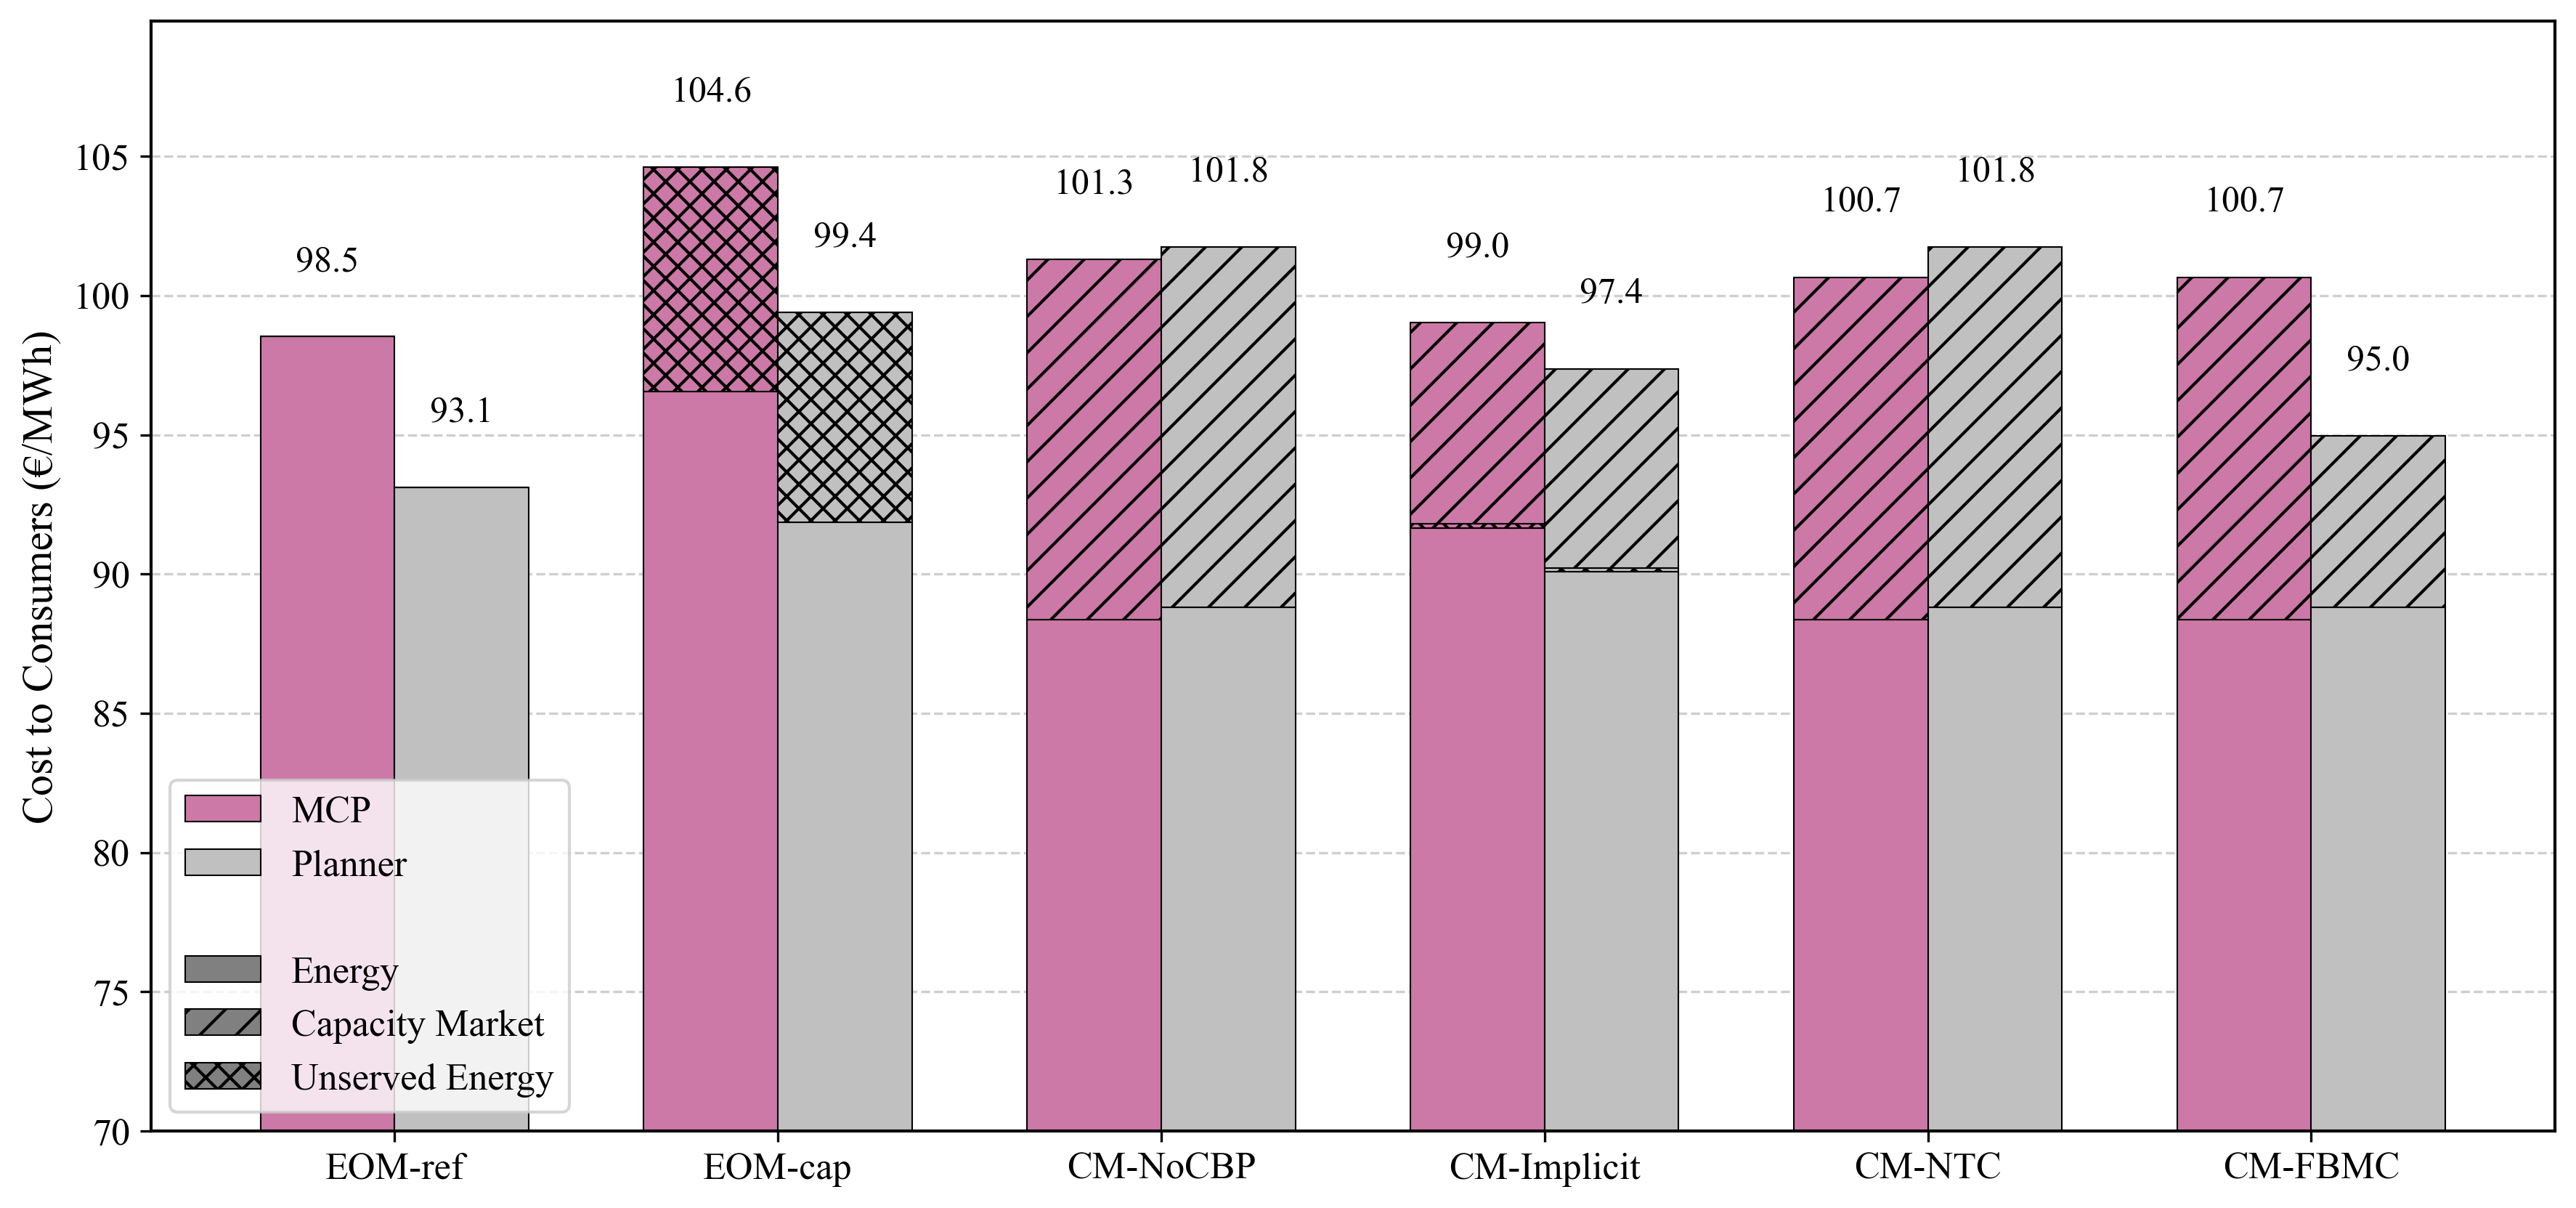

In [48]:
# Compare MCP and Planner capacity prices
fig, ax = compare_mcp_planner_costs(analysis_data, inputs)

In [49]:
# Capacity trade

# FB - MCP / Planner
# Zone A – import 1225 / 1000
# Zone B – import 4775 / 5000
# Zone C – export 6000 / 6000

# NTC - MCP / Planner
# Zone A – import 4058 / 1302
# Zone B – import 680 / 3435.8
# Zone C – export 4738 / 4738



In [50]:
# plot scarcity price 
# look for max price in EOM_price column for each zone and design
# plot bar chart with scarcity prices for each zone and design


In [51]:
def extract_scarcity_prices(data: Dict[str, pd.DataFrame], source_type: str = "mcp") -> pd.DataFrame:
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in data:
                print(f"Warning: {key} not found in analysis data")
                continue
            
            df = data[key]
            
            # Find maximum EOM price (scarcity price)
            if "EOM_price" in df.columns:
                max_price = df["EOM_price"].max()
                records.append({
                    "Zone": zone,
                    "Design": design,
                    "ScarcityPrice": max_price
                })
            else:
                print(f"Warning: EOM_price column not found in {key}")
    
    return pd.DataFrame(records)

def plot_scarcity_price_by_zone(scarcity_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot scarcity prices by zone and market design with consistent styling
    similar to plot_average_cost_by_zone
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

    zones = ["A", "B", "C"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors (matching plot_average_cost_by_zone)
    base_colors = {
        "A": "#0072B2",         # Dark Blue
        "B": "#009E73",         # Bluish-Green
        "C": "#D55E00",         # Vermilion
    }

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = scarcity_df[scarcity_df["Zone"] == zone]
        zone_start_x = current_x
        color = base_colors[zone]

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            scarcity_price = row["ScarcityPrice"].values[0]

            # Plot bar
            ax.bar(current_x, scarcity_price, width=bar_width, color=color)

            # Label value on top
            ax.text(current_x, scarcity_price + scarcity_df["ScarcityPrice"].max() * 0.02, 
                   f"{scarcity_price:.0f}", ha="center", va="bottom", fontsize=FONT_SIZES['annotation'])

            # Record positions
            x_positions.append(current_x)
            x_labels.append(map_policy_name(design))
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"Zone {zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['axis_label'], rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.3, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Scarcity Price (€/MWh)', fontsize=FONT_SIZES['axis_label'])
    ax.set_ylim(0, scarcity_df["ScarcityPrice"].max() * 1.2)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Create legend with zone colors
    legend_elements = [
        Patch(facecolor=base_colors["A"], label='Zone A'),
        Patch(facecolor=base_colors["B"], label='Zone B'),
        Patch(facecolor=base_colors["C"], label='Zone C')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=FONT_SIZES['annotation'])

    plt.tight_layout()
    return fig, ax

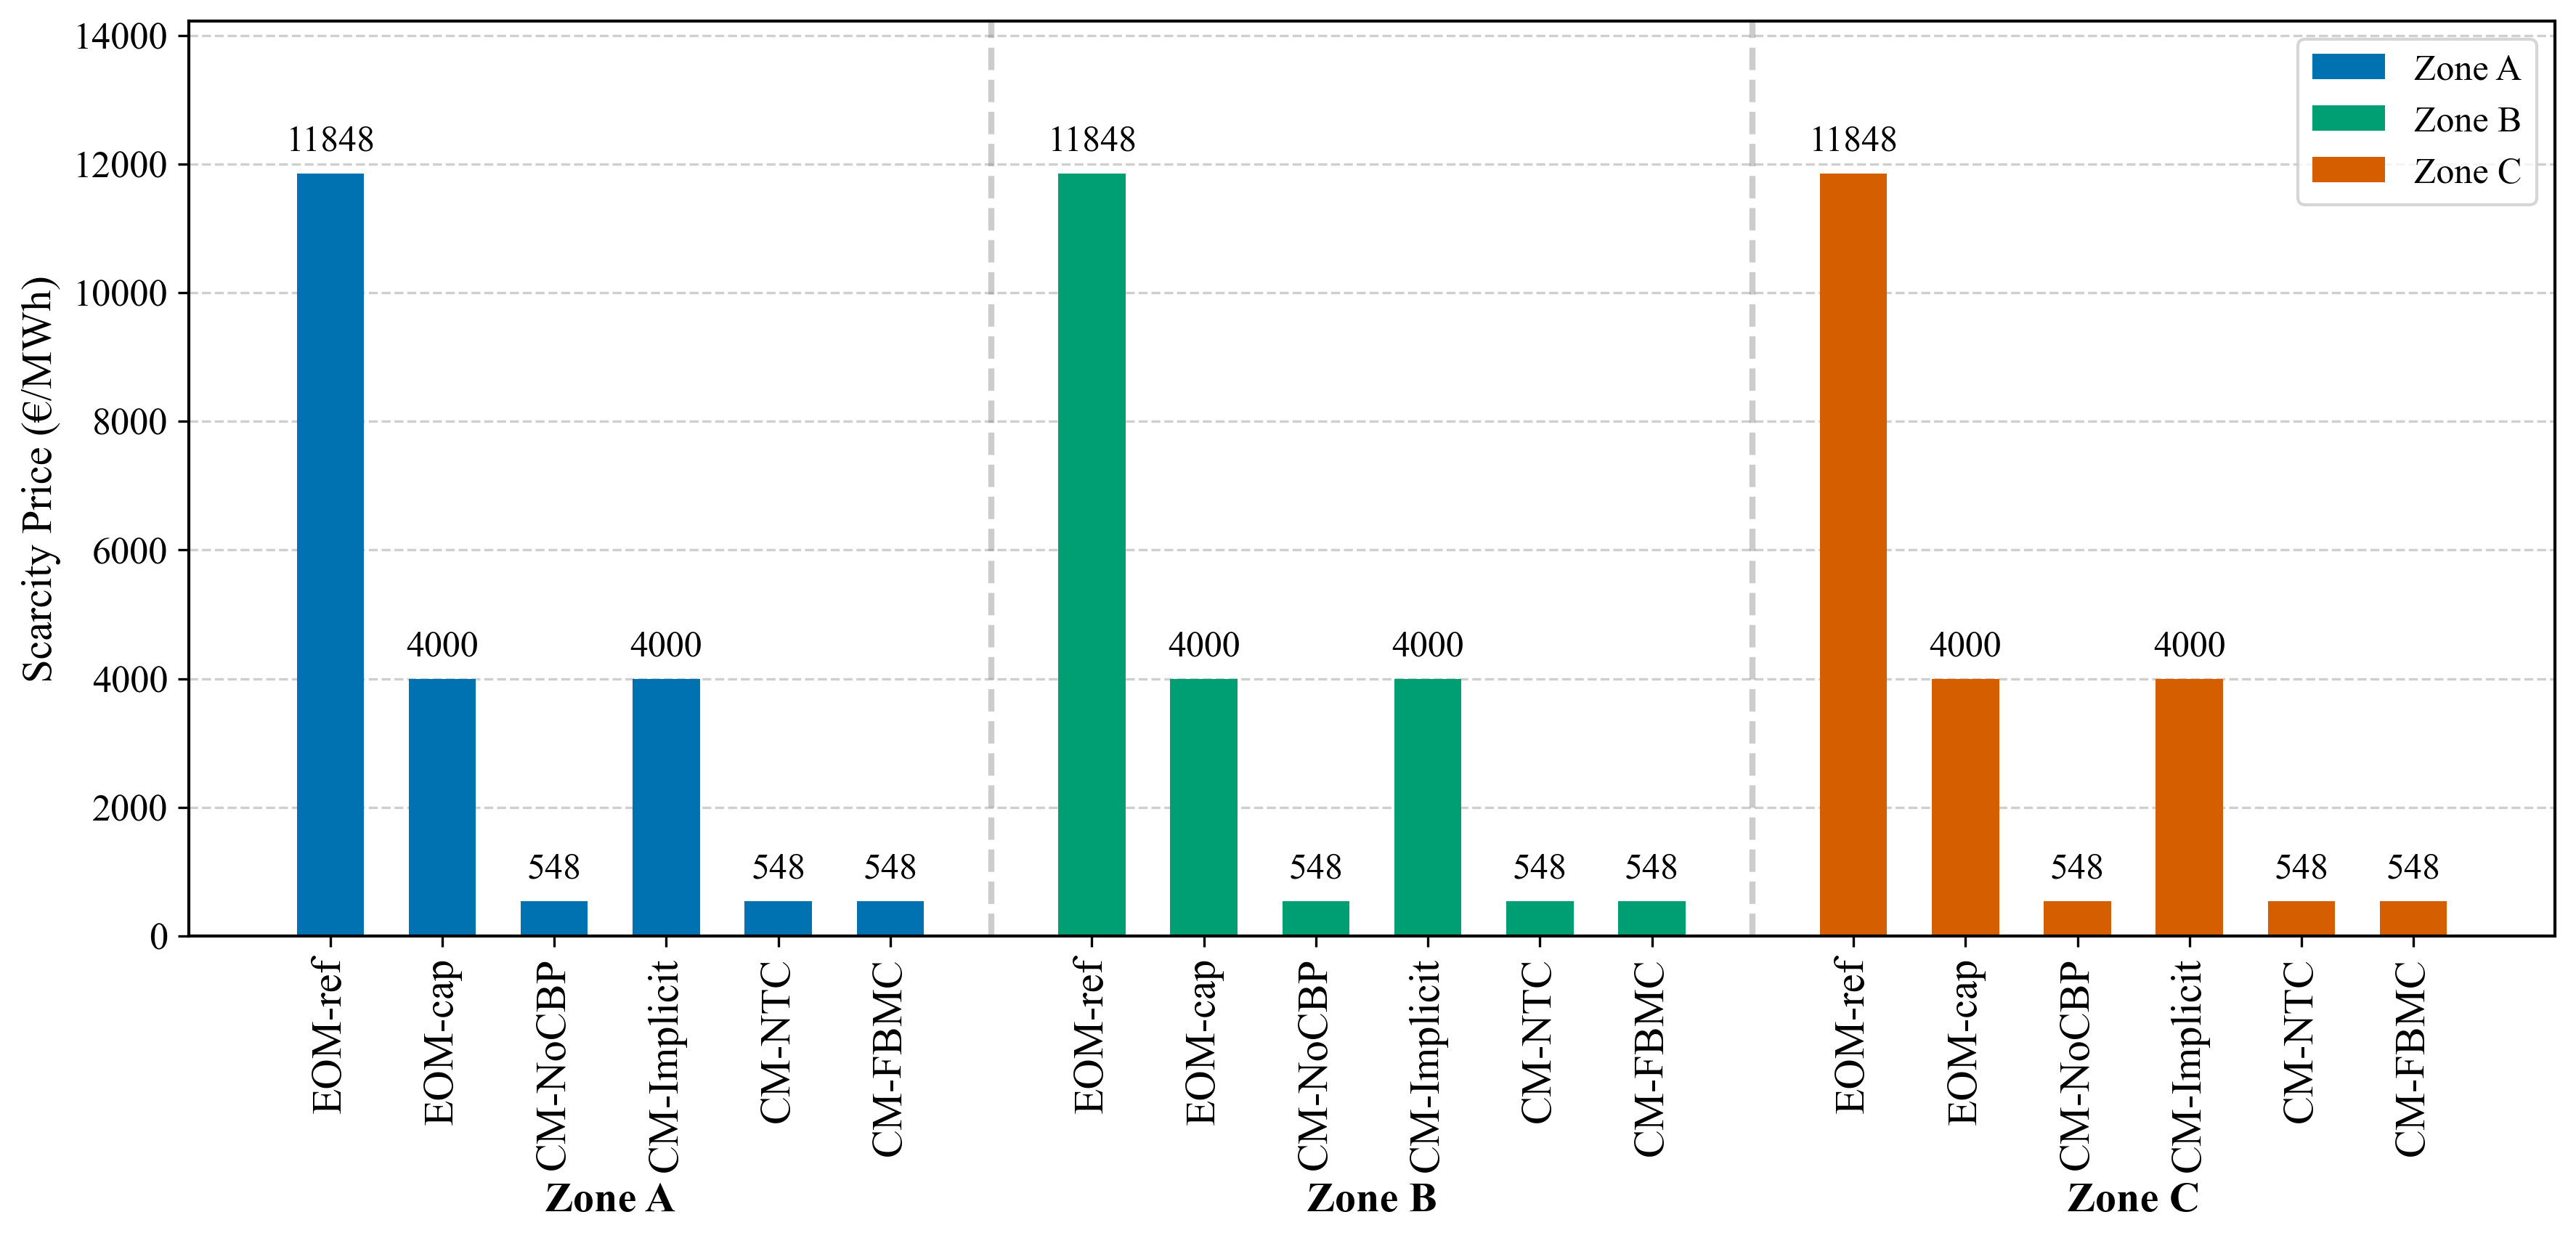

In [52]:
# Extract and plot scarcity prices for MCP model
scarcity_prices_mcp = extract_scarcity_prices(analysis_data, source_type="mcp")
fig, ax = plot_scarcity_price_by_zone(scarcity_prices_mcp, source_type="mcp")
plt.show()

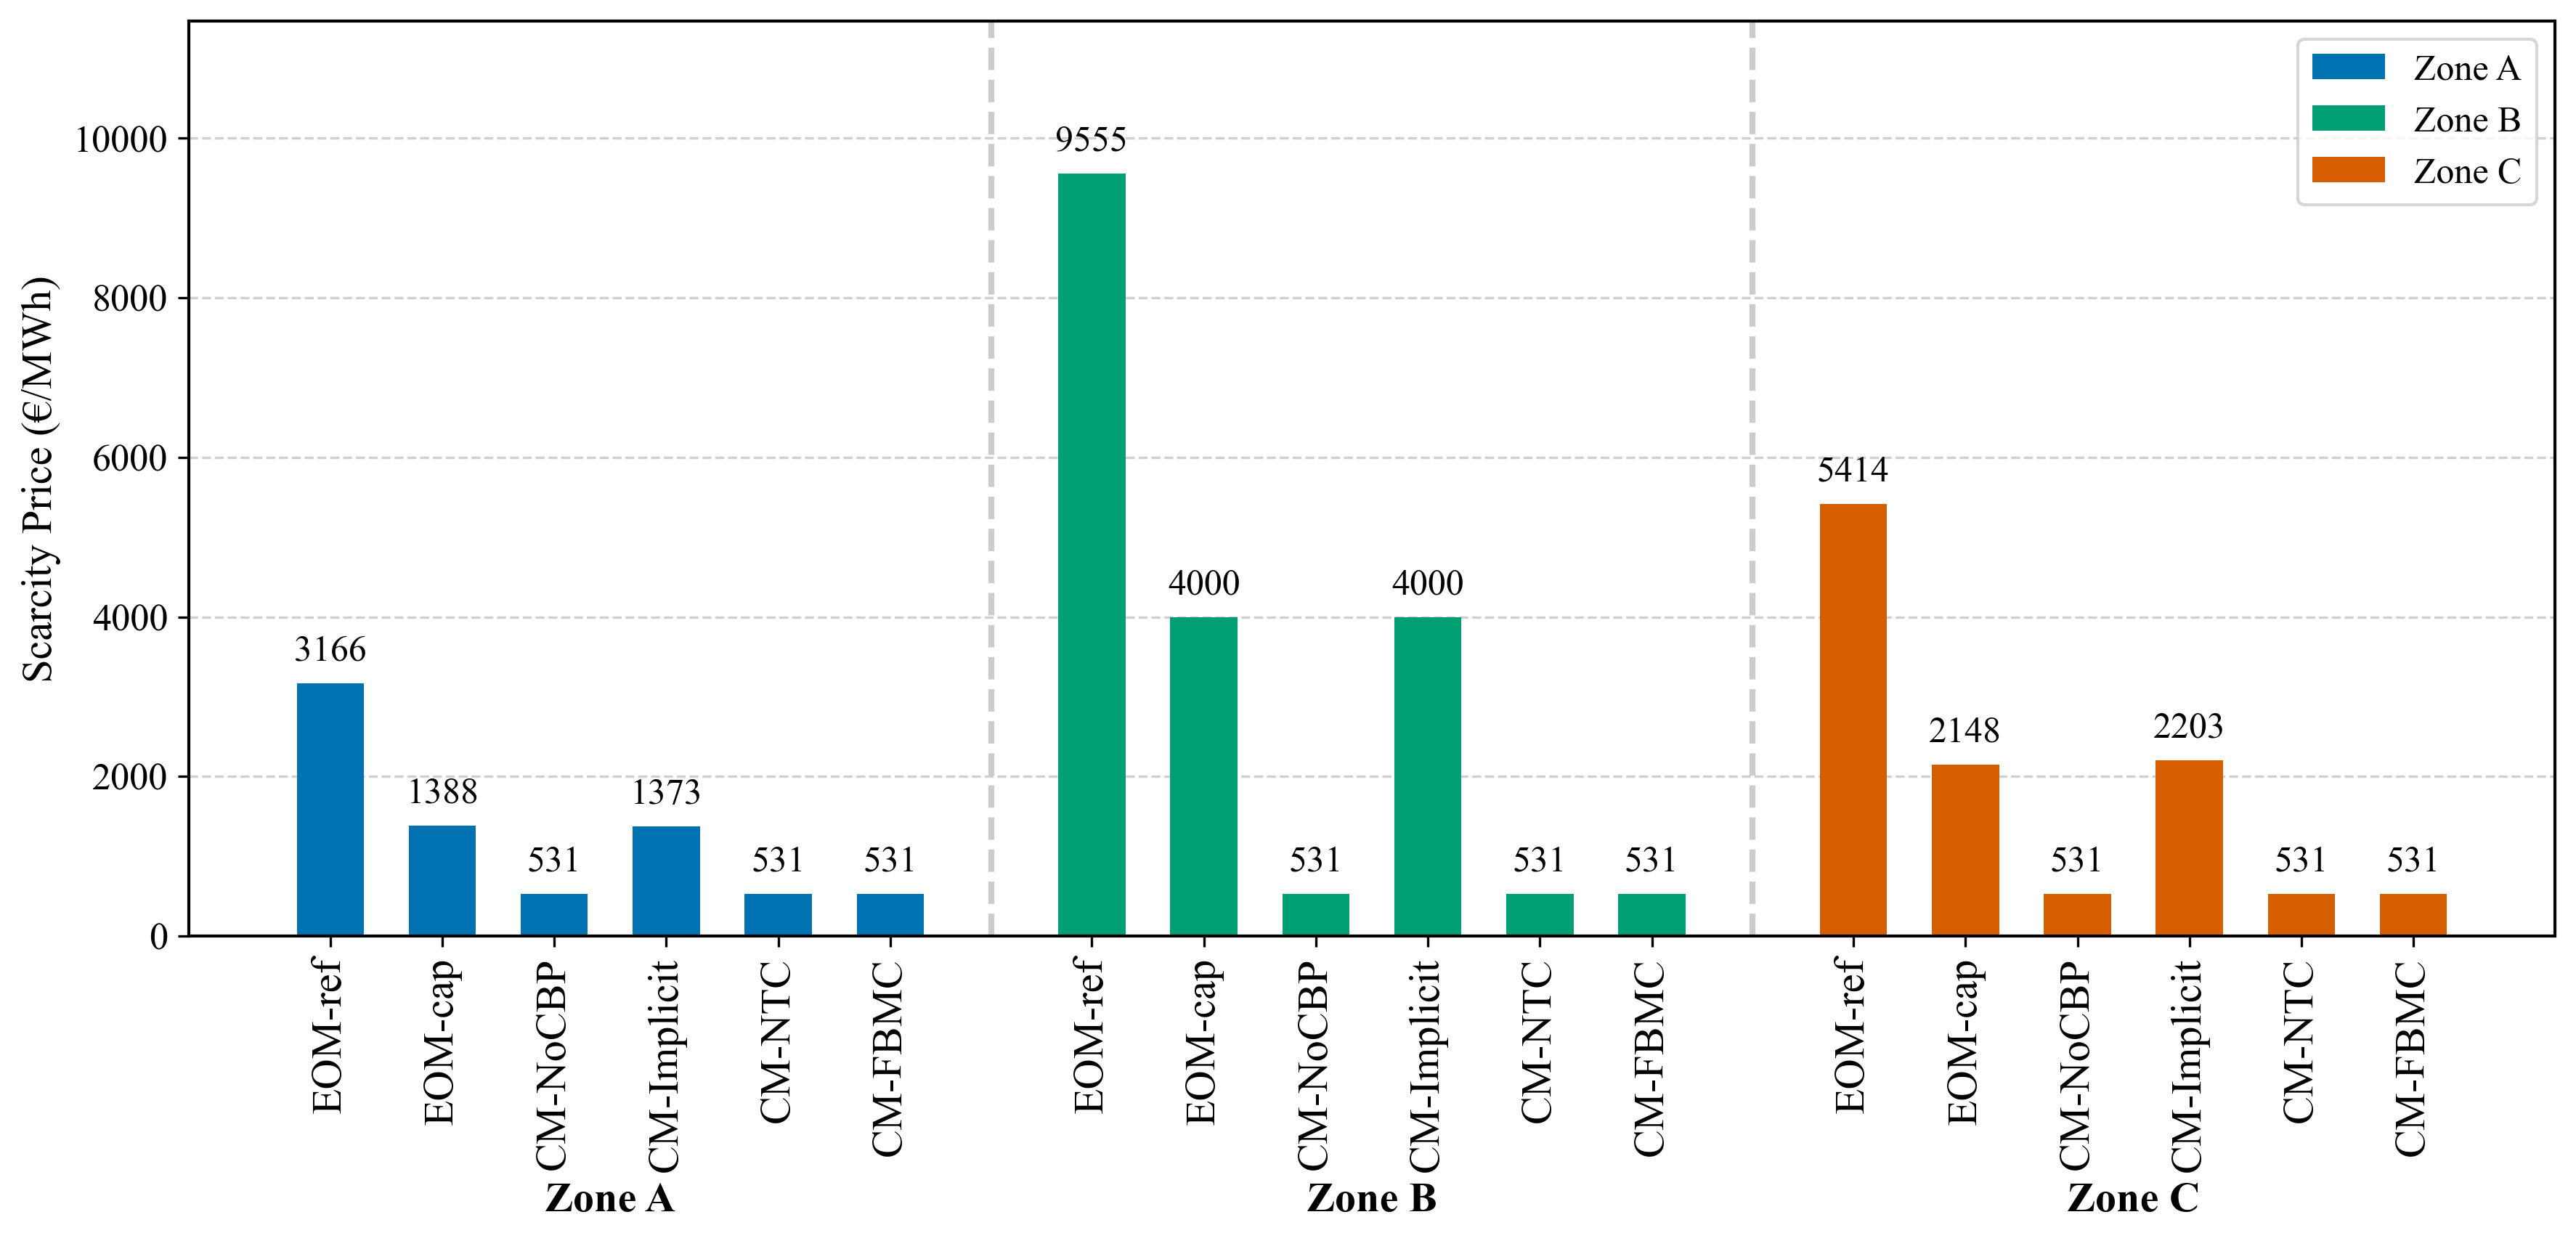

In [53]:
# For Planner model
scarcity_prices_planner = extract_scarcity_prices(analysis_data, source_type="planner")
fig, ax = plot_scarcity_price_by_zone(scarcity_prices_planner, source_type="planner")
plt.show()

In [54]:
def extract_capacity_prices(data: Dict[str, pd.DataFrame], source_type: str = "mcp") -> pd.DataFrame:
    """
    Extract capacity market prices (CM_price) for each zone and market design
    """
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for design in design_keys:
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in data:
                print(f"Warning: {key} not found in analysis data")
                continue
            
            df = data[key]
            
            # Get capacity market price (typically constant across timesteps)
            if "CM_price" in df.columns:
                cm_price = df["CM_price"].iloc[0]  # Usually constant

                
                records.append({
                    "Zone": zone,
                    "Design": design,
                    "CapacityPrice": cm_price
                })
            else:
                continue
                print(f"Warning: CM_price column not found in {key}")
    
    return pd.DataFrame(records)


def plot_capacity_price_by_zone(capacity_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot capacity market prices by zone and market design with consistent styling
    similar to plot_scarcity_price_by_zone
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)

    zones = ["A", "B", "C"]
    design_order = ["NoCBP", "implicit", "NTC", "FBMC"]

    # Base zone colors
    base_colors = {
        "A": "#0072B2",         # Dark Blue
        "B": "#009E73",         # Bluish-Green
        "C": "#D55E00",         # Vermilion
    }

    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []

    for zone in zones:
        zone_df = capacity_df[capacity_df["Zone"] == zone]
        zone_start_x = current_x
        color = base_colors[zone]

        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue

            capacity_price = row["CapacityPrice"].values[0]

            # Plot bar
            ax.bar(current_x, capacity_price, width=bar_width, color=color)

            # Label value on top (only if non-zero)
            if capacity_price > 0:
                max_price = capacity_df["CapacityPrice"].max()
                ax.text(current_x, capacity_price + max_price * 0.02, 
                       f"{capacity_price:.0f}", ha="center", va="bottom", fontsize=FONT_SIZES['annotation'])

            # Record positions
            x_positions.append(current_x)
            x_labels.append(map_policy_name(design))
            current_x += 1

        # Zone mid label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"Zone {zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones

    # X-axis labels for designs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['axis_label'], rotation=90)

    # Zone labels under x-axis
    for xpos, label in zone_label_positions:
        # Calculate midpoint of zone section
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos  # Fallback
        
        ax.text(midpoint, -0.3, label, ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')

    # Vertical lines between zones
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray', linestyle='--', alpha=0.4)

    # Styling
    ax.set_ylabel('Capacity Price (€/MW)', fontsize=FONT_SIZES['axis_label'])
    
    # Set y-axis limit (handle case where all prices are zero)
    max_price = capacity_df["CapacityPrice"].max()
    if max_price > 0:
        ax.set_ylim(30000, max_price * 1.1)
    else:
        ax.set_ylim(0, 100)  # Default range if all prices are zero
    
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Create legend with zone colors
    legend_elements = [
        Patch(facecolor=base_colors["A"], label='Zone A'),
        Patch(facecolor=base_colors["B"], label='Zone B'),
        Patch(facecolor=base_colors["C"], label='Zone C')
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=FONT_SIZES['annotation'])

    plt.tight_layout()
    return fig, ax


Capacity Prices (MCP):
   Zone    Design  CapacityPrice
0     A       eom       0.000000
1     B       eom       0.000000
2     C       eom       0.000000
3     A  pricecap       0.000000
4     B  pricecap       0.000000
5     C  pricecap       0.000000
6     A     NoCBP   70000.029929
7     B     NoCBP   69999.980861
8     C     NoCBP   70000.002770
9     A  implicit   48166.488394
10    B  implicit   49323.620590
11    C  implicit   49328.493410
12    A       NTC   69999.999995
13    B       NTC   69999.990983
14    C       NTC   69999.999208
15    A      FBMC   70000.000993
16    B      FBMC   69999.985094
17    C      FBMC   69999.997488


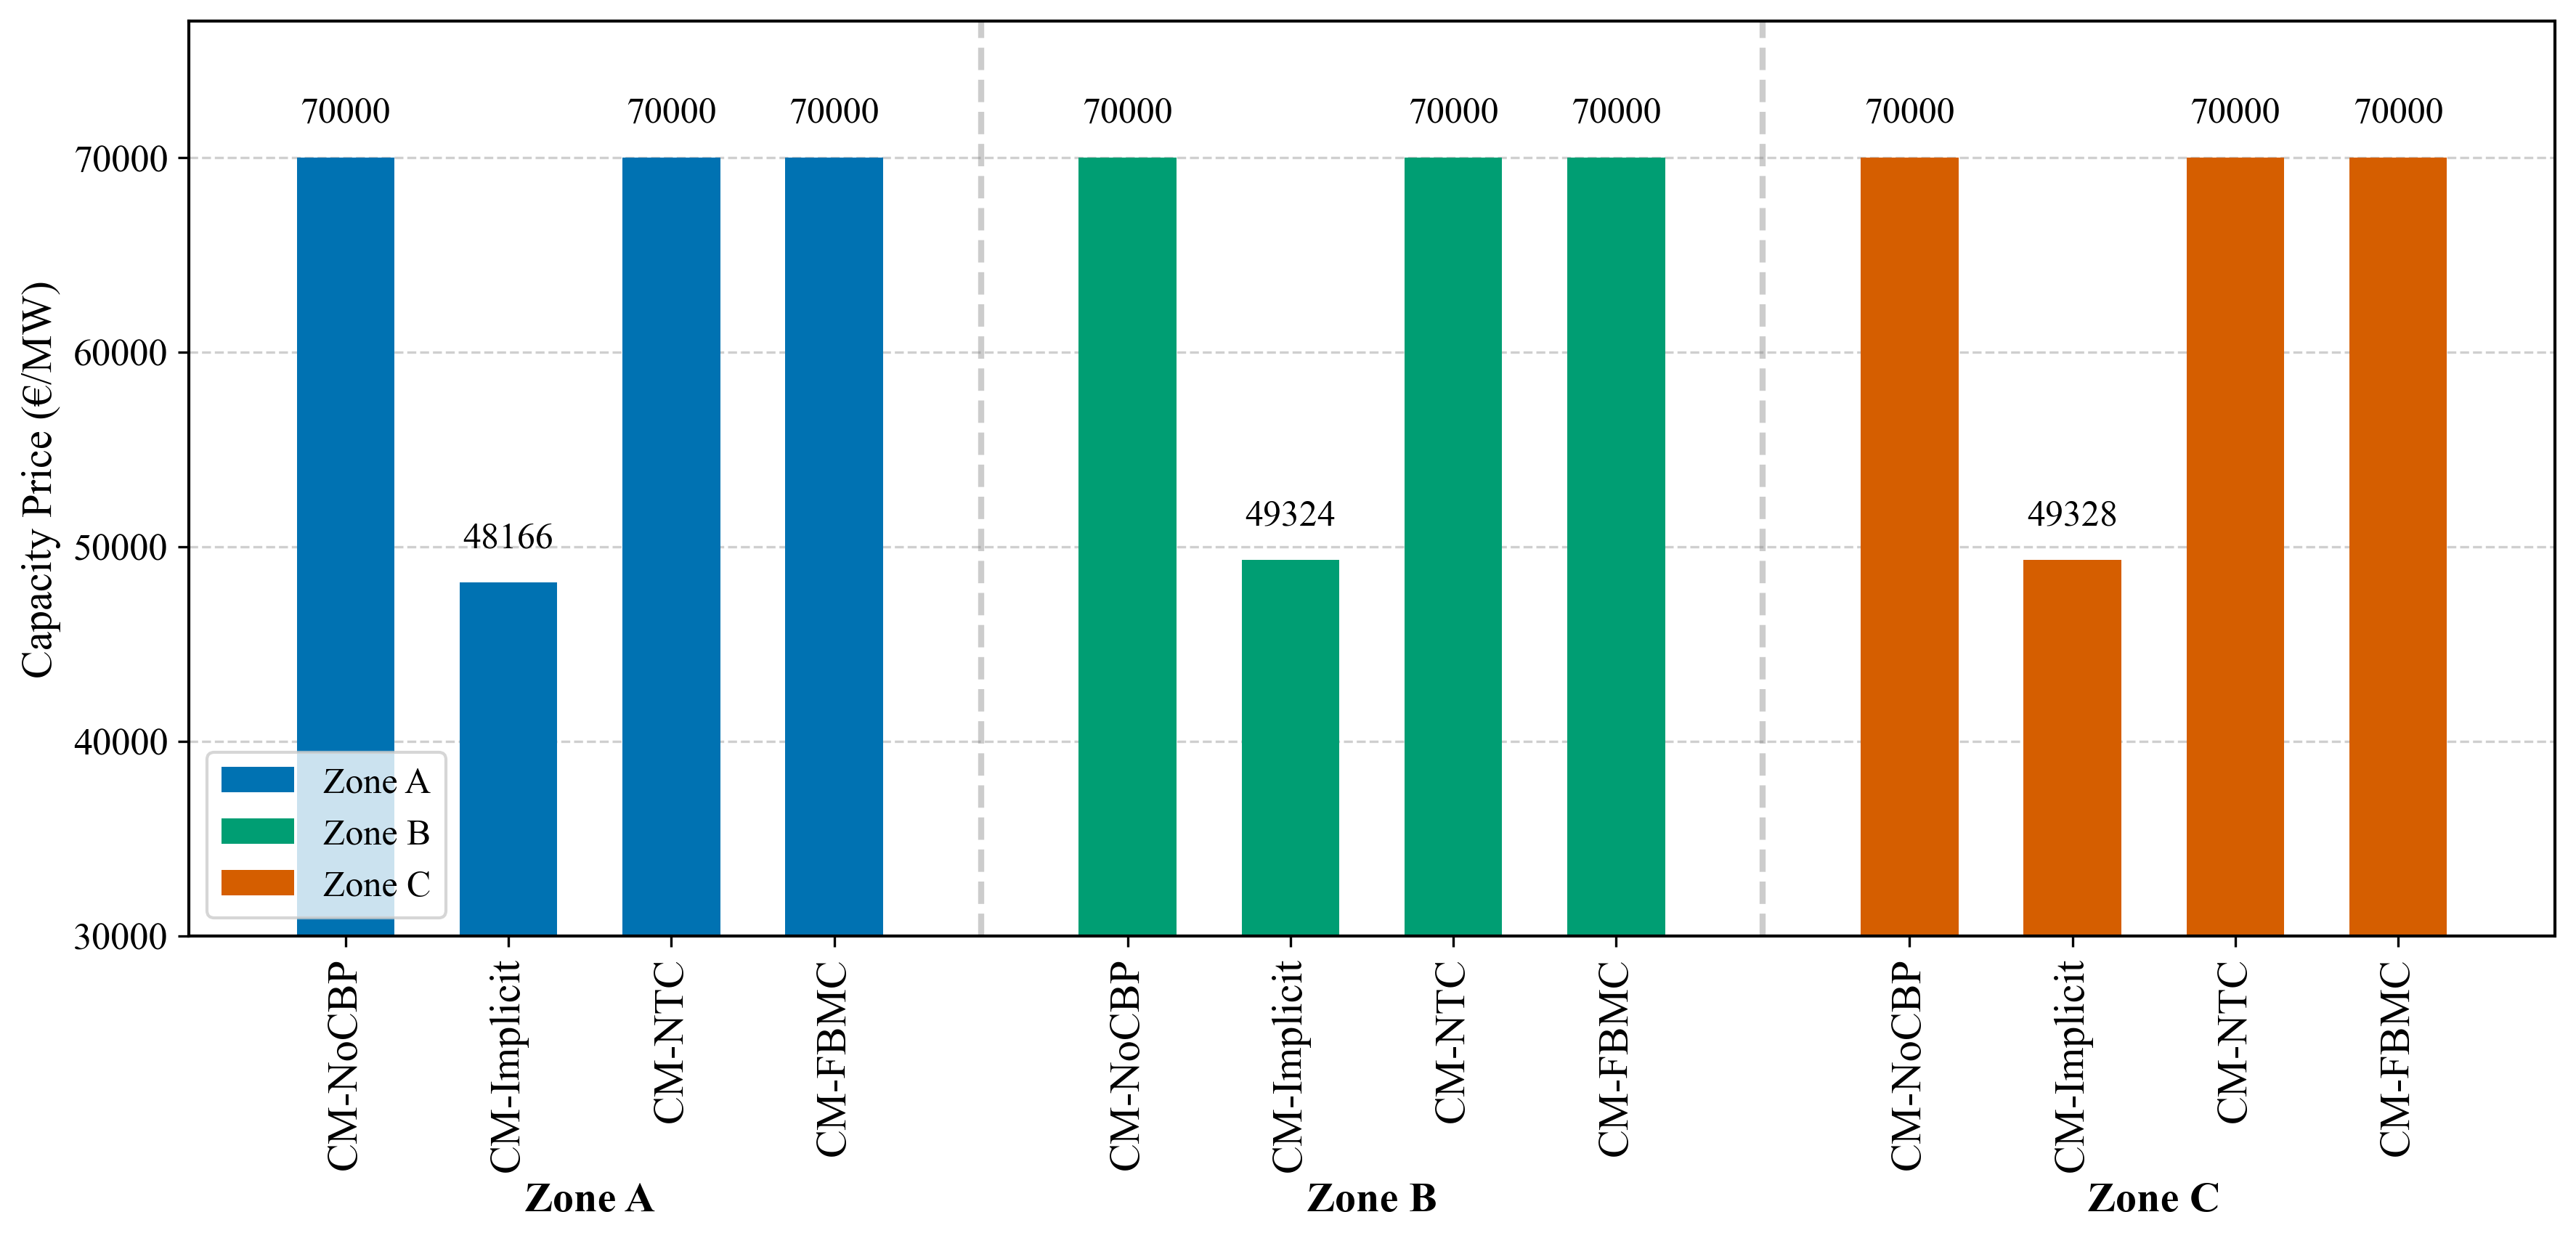


Capacity Prices (Planner):
   Zone    Design  CapacityPrice
0     A     NoCBP       70000.00
1     B     NoCBP       70000.00
2     C     NoCBP       70000.00
3     A  implicit       47686.09
4     B  implicit       49184.09
5     C  implicit       48123.66
6     A       NTC       70000.00
7     B       NTC       70000.00
8     C       NTC       70000.00
9     A      FBMC       35061.70
10    B      FBMC       35005.20
11    C      FBMC       34973.73


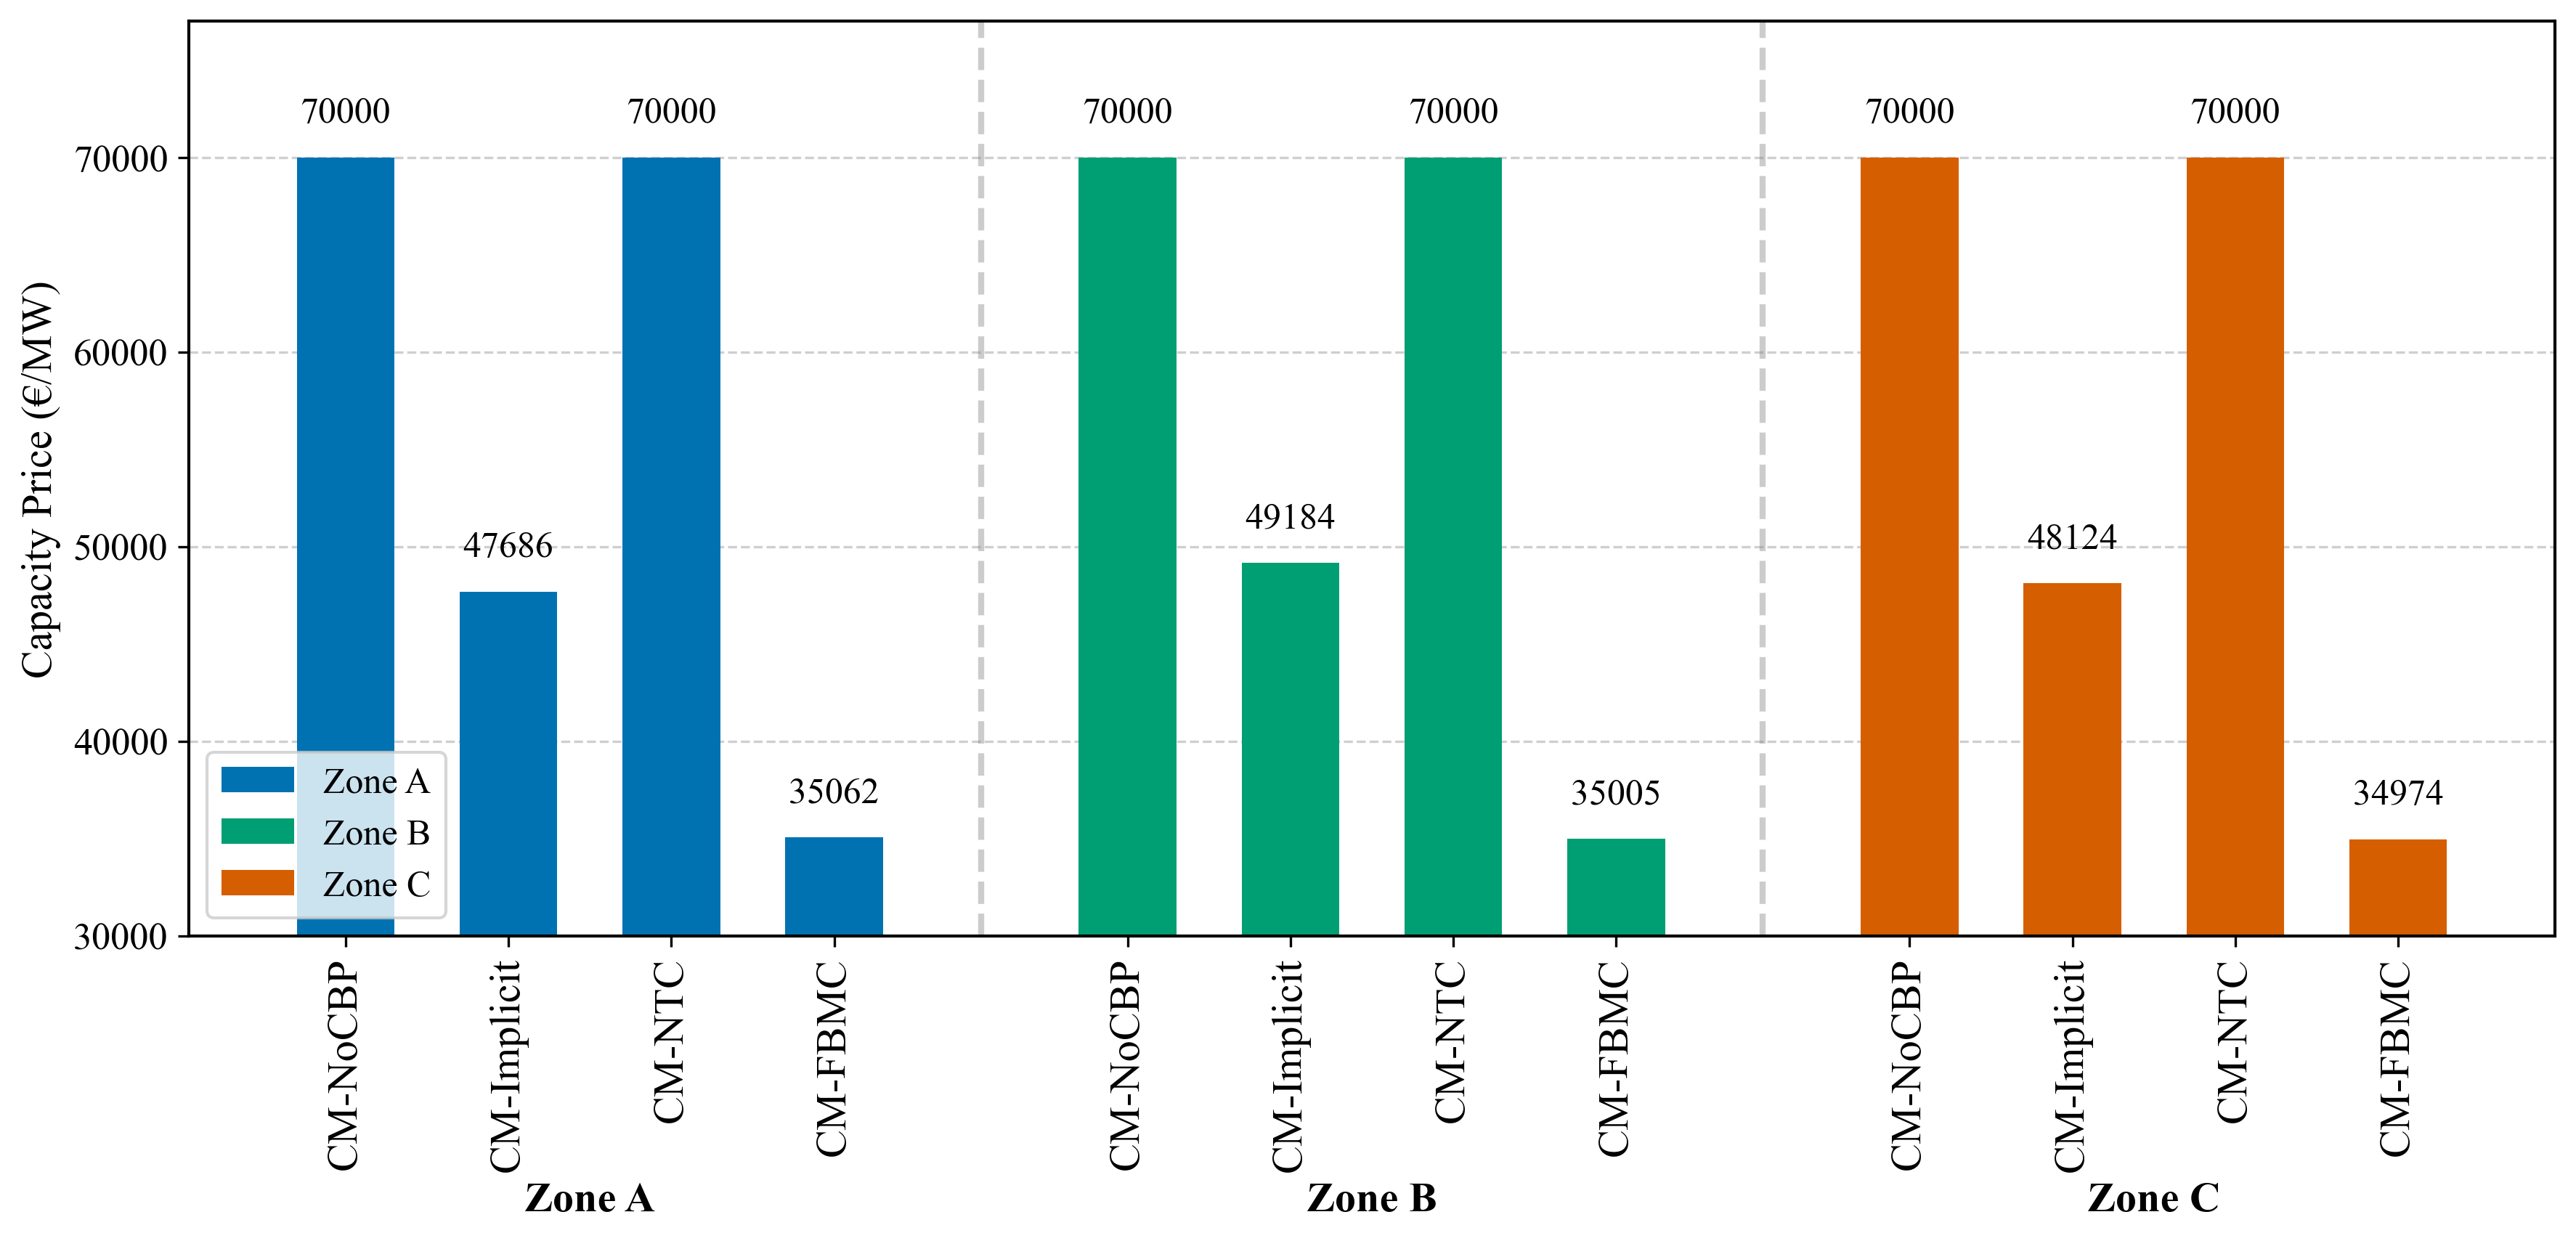

In [55]:
# capacity price in each zone
# Extract and plot capacity prices for MCP model
capacity_prices_mcp = extract_capacity_prices(analysis_data, source_type="mcp")
print("\nCapacity Prices (MCP):")
print(capacity_prices_mcp)
fig, ax = plot_capacity_price_by_zone(capacity_prices_mcp, source_type="mcp")
plt.show()

# For Planner model
capacity_prices_planner = extract_capacity_prices(analysis_data, source_type="planner")
print("\nCapacity Prices (Planner):")
print(capacity_prices_planner)
fig, ax = plot_capacity_price_by_zone(capacity_prices_planner, source_type="planner")
plt.show()


In [56]:
def compare_mcp_planner_capacity_prices(analysis_data):

    # Get capacity price data for both sources
    mcp_capacity = extract_capacity_prices(analysis_data, "mcp")
    planner_capacity = extract_capacity_prices(analysis_data, "planner")
    
    # Filter to only include designs with capacity markets
    design_order = ["NoCBP", "implicit", "NTC", "FBMC"]
    mcp_capacity = mcp_capacity[mcp_capacity["Design"].isin(design_order)]
    planner_capacity = planner_capacity[planner_capacity["Design"].isin(design_order)]
    
    # Calculate system-wide averages for each design
    for design in design_order:
        # MCP system average
        mcp_design_data = mcp_capacity[mcp_capacity["Design"] == design]
        if not mcp_design_data.empty:
            avg_price = mcp_design_data["CapacityPrice"].mean()
            mcp_capacity = pd.concat([mcp_capacity, pd.DataFrame({
                "Zone": ["System"],
                "Design": [design],
                "CapacityPrice": [avg_price]
            })], ignore_index=True)
        
        # Planner system average
        planner_design_data = planner_capacity[planner_capacity["Design"] == design]
        if not planner_design_data.empty:
            avg_price = planner_design_data["CapacityPrice"].mean()
            planner_capacity = pd.concat([planner_capacity, pd.DataFrame({
                "Zone": ["System"],
                "Design": [design],
                "CapacityPrice": [avg_price]
            })], ignore_index=True)
    
    # Prepare data for plotting
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    # Set up parameters for plotting - now including System
    zones = ["A", "B", "C", "System"]
    bar_width = 0.35
    
    # Use same color scheme as compare_mcp_planner_costs
    mcp_base = "#CC79A7"          # Rose (MCP color)
    planner_base = "#C0C0C0"  # Gray (Planner color)
    
    # Bar settings
    spacing_between_designs = 1.5
    current_x = 0
    x_positions_mcp = []
    x_positions_planner = []
    x_labels = []
    design_label_positions = []
    design_boundaries = []
    
    for design in design_order:
        design_start_x = current_x
        
        for zone in zones:
            # Get MCP capacity price
            mcp_row = mcp_capacity[(mcp_capacity["Design"] == design) & 
                                    (mcp_capacity["Zone"] == zone)]
            mcp_price = mcp_row["CapacityPrice"].values[0] if not mcp_row.empty else 0
            
            # Get Planner capacity price
            planner_row = planner_capacity[(planner_capacity["Design"] == design) & 
                                            (planner_capacity["Zone"] == zone)]
            planner_price = planner_row["CapacityPrice"].values[0] if not planner_row.empty else 0
            
            # Plot MCP bar (left) - using purple color
            ax.bar(current_x - bar_width/2, mcp_price, width=bar_width, 
                   color=mcp_base, alpha=0.8, 
                   label=f"MCP" if design == design_order[0] and zone == zones[0] else "")
            
            # Plot Planner bar (right) - using gray color
            ax.bar(current_x + bar_width/2, planner_price, width=bar_width, 
                   color=planner_base, alpha=0.8, 
                   label=f"Planner" if design == design_order[0] and zone == zones[0] else "")
            
            # # Add value labels on top (only if non-zero)
            # max_price = max(
            #     mcp_capacity["CapacityPrice"].max() if len(mcp_capacity) > 0 else 0,
            #     planner_capacity["CapacityPrice"].max() if len(planner_capacity) > 0 else 0
            # )
            # if mcp_price > 0:
            #     ax.text(current_x - bar_width/2, mcp_price + max_price * 0.02, 
            #            f"{mcp_price:.0f}", ha='center', va='bottom', fontsize=0)
            # if planner_price > 0:
            #     ax.text(current_x + bar_width/2, planner_price + max_price * 0.02, 
            #            f"{planner_price:.0f}", ha='center', va='bottom', fontsize=0)
            
            # Record positions
            x_positions_mcp.append(current_x - bar_width/2)
            x_positions_planner.append(current_x + bar_width/2)
            x_labels.append(zone)
            current_x += 1
        
        # Design mid label
        if current_x > design_start_x:
            mid = (design_start_x + current_x - 1) / 2
            design_label_positions.append((mid, design))
            design_boundaries.append(current_x - 0.5)
            current_x += spacing_between_designs
    
    # X-axis labels for zones
    all_x_positions = []
    for i in range(len(x_positions_mcp)):
        all_x_positions.append((x_positions_mcp[i] + x_positions_planner[i]) / 2)
    
    ax.set_xticks(all_x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['axis_label'], rotation=0)
    
    # Design labels under x-axis
    for xpos, label in design_label_positions:
        ax.text(xpos, -0.15, map_policy_name(label), ha='center', transform=ax.get_xaxis_transform(), 
                fontsize=FONT_SIZES['zone_label'], fontweight='bold')
    
    # Vertical lines between designs
    for boundary in design_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_designs / 2, color='gray', 
                   linestyle='--', alpha=0.4)
    
    # Styling
    ax.set_ylabel('Capacity Price (€/MW)', fontsize=FONT_SIZES['axis_label'])
    
    # Set y-axis limit
    max_price = max(
        mcp_capacity["CapacityPrice"].max() if len(mcp_capacity) > 0 else 0,
        planner_capacity["CapacityPrice"].max() if len(planner_capacity) > 0 else 0
    )
    if max_price > 0:
        ax.set_ylim(0, max_price * 1.2)
    else:
        ax.set_ylim(0, 100)
    
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    
    # Simple legend matching compare_mcp_planner_costs style
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=mcp_base, alpha=0.8, label='MCP'),
        Patch(facecolor=planner_base, alpha=0.8, label='Planner'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=FONT_SIZES['annotation'])
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)  # Make room for design labels
    return fig, ax

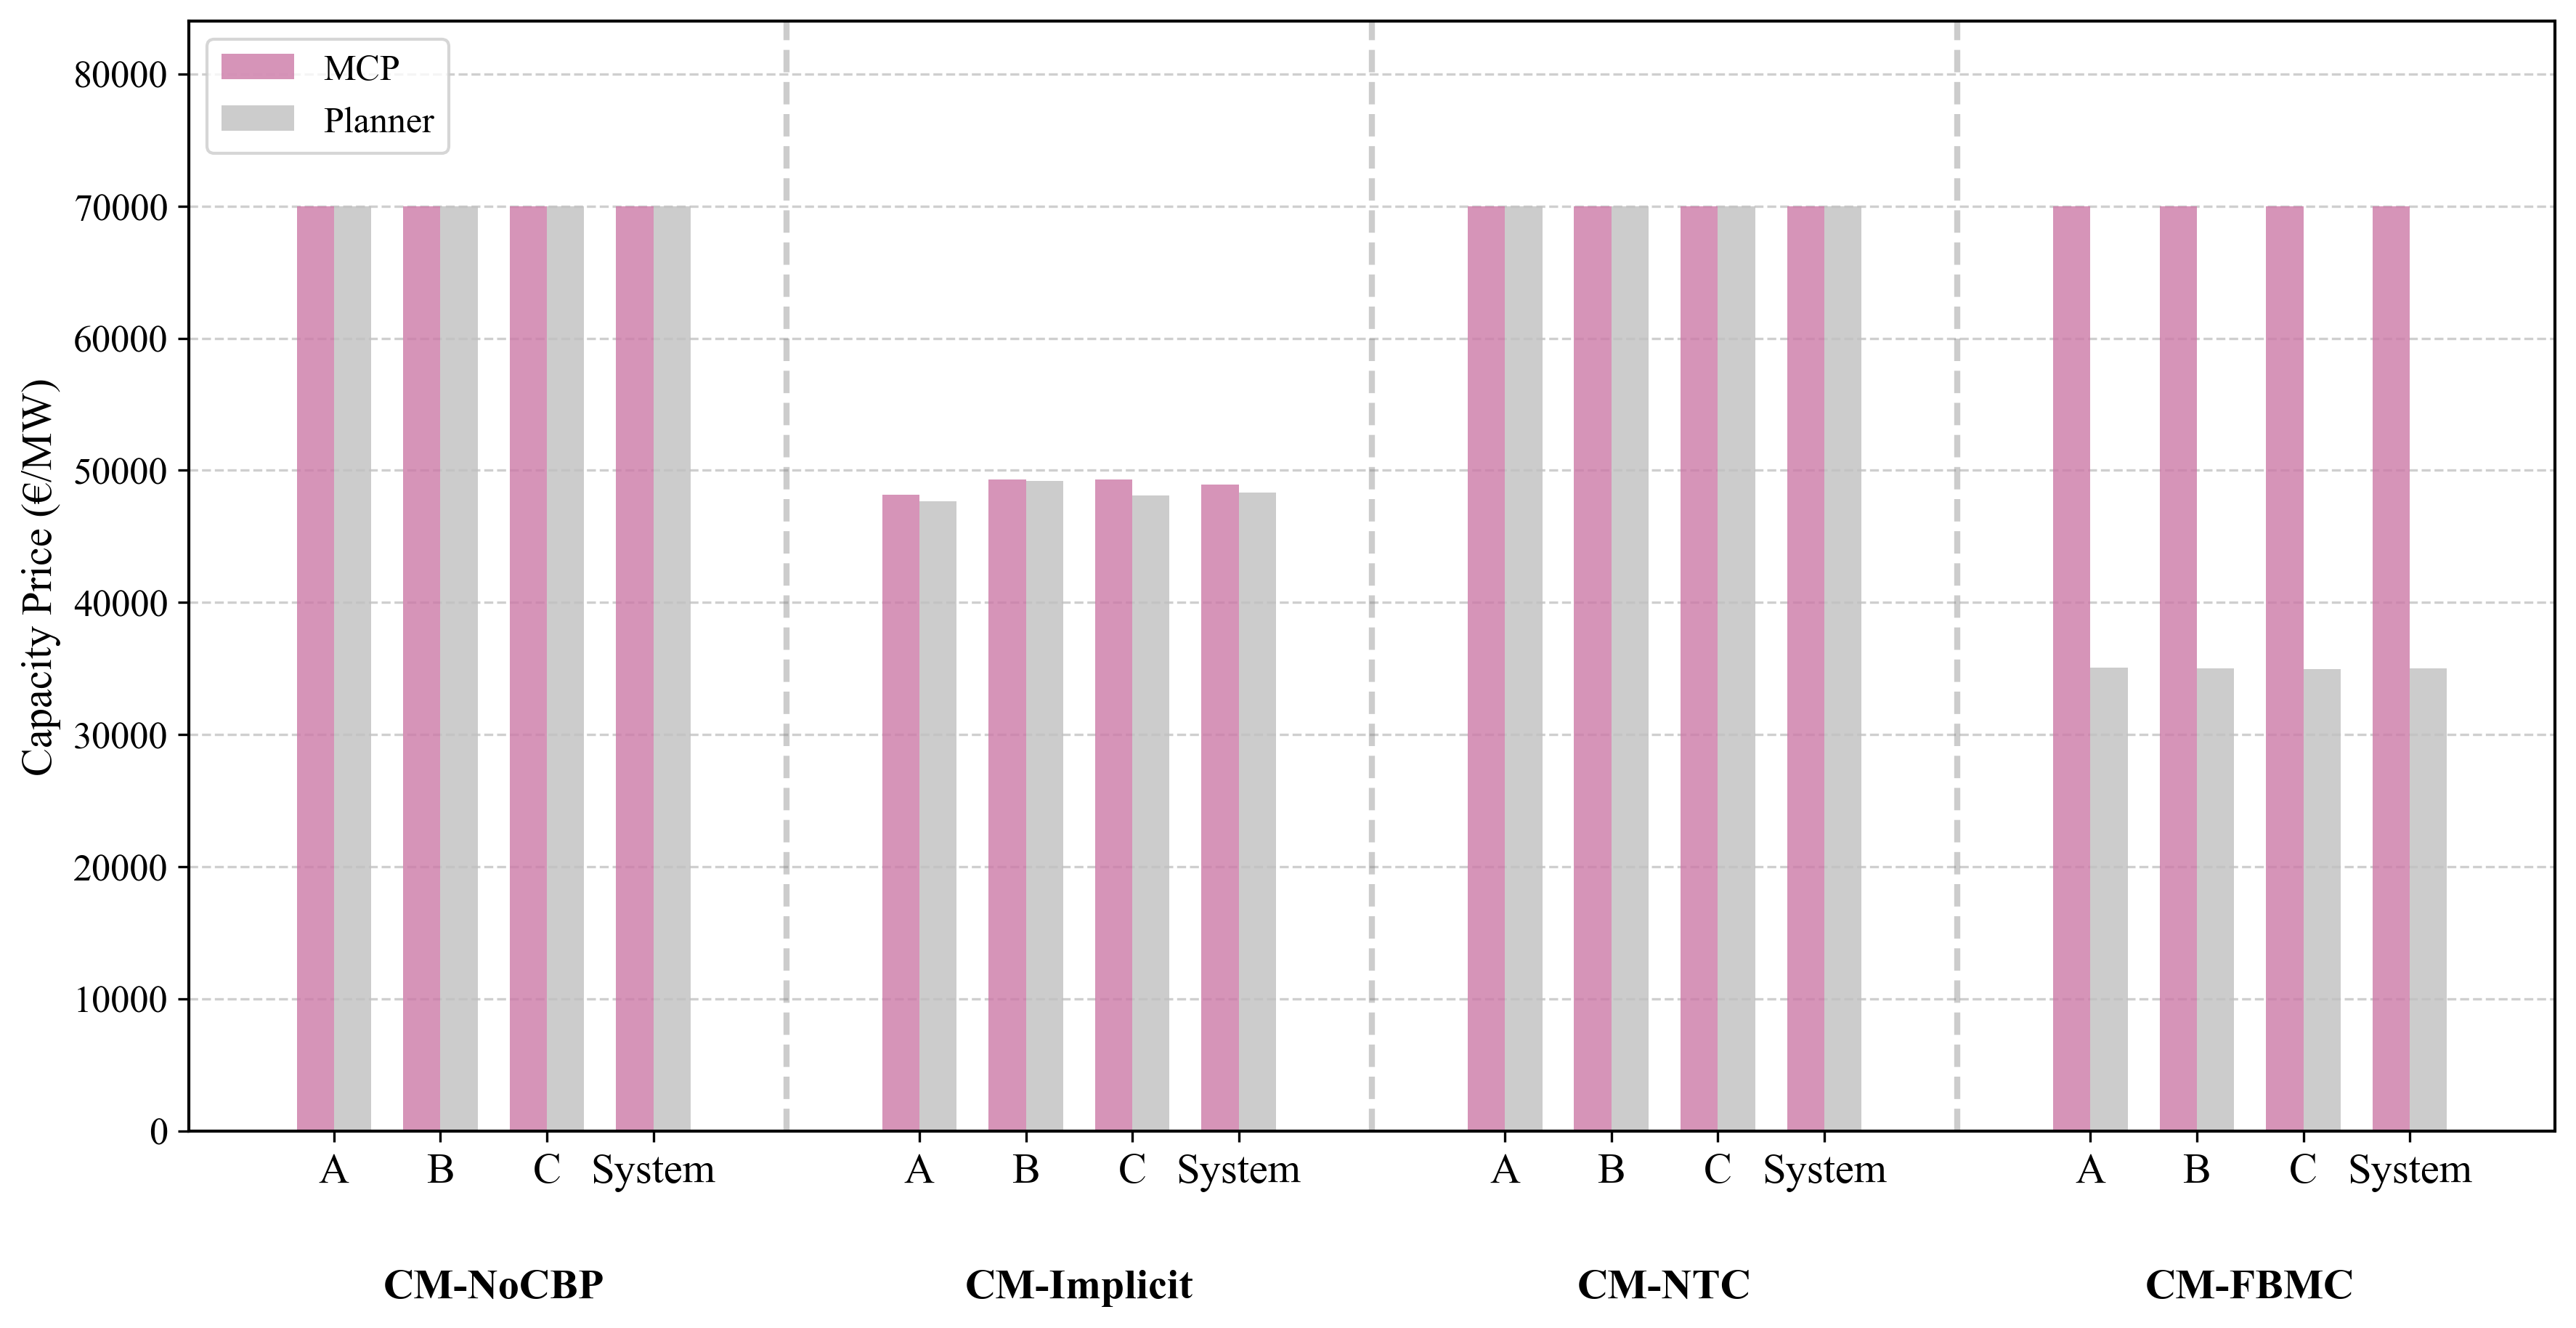

In [57]:
# Compare MCP and Planner capacity prices
fig, ax = compare_mcp_planner_capacity_prices(analysis_data)
plt.show()

In [58]:
# Performance comparison of different policies in each zone and system-wide
# cost of Generation + ivestment cost + capacity market cost + cost of unserved energy
# cost of Generation for each tech = + sum(W[jh] * A/2*g[jh]^2 for jh in JH) + sum(W[jh] * B*g[jh] for jh in JH)
# investment cost for each tech = sum(annualized_fixed_cost[tech] * capacity[tech] for tech in TECHS)
# capacity market cost = capacity_price * capacity_demand
# cost of unserved energy = sum(ens_price * ens[t] * W[t] for t in TIMES)


In [59]:
def compute_performance_metrics(
    analysis_data: Dict[str, pd.DataFrame],
    inputs: dict,
    source_type: str = "mcp"
) -> pd.DataFrame:
    """
    Compute total system costs including:
    - Generation costs (quadratic + linear terms)
    - Investment costs (annualized fixed costs)
    - Cost of unserved energy
    
    Parameters:
    - analysis_data: Dictionary of dataframes with results
    - inputs: Dictionary with config data and weights
    - source_type: "mcp" or "planner"
    
    Returns:
    - DataFrame with cost breakdown by zone and design
    """
    zones = ["A", "B", "C"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    # gen_types = ["Baseload", "MidMerit", "Peak", "WindOnshore", "PV"]
    gen_types = ["Baseload", "MidMerit", "Peak"]
    
    records = []
    wtp = 20000  # €/MWh for unserved energy
    
    for design in design_keys:
        zone_records = []
        
        for zone in zones:
            key = f"{source_type}_zone_{zone}_{design}"
            
            if key not in analysis_data:
                print(f"Warning: {key} not found")
                continue
            
            df = analysis_data[key]
            W = inputs["weights"][zone][:len(df)]  # Zone-specific weights
            
            # Initialize costs
            gen_cost_total = 0
            inv_cost_total = 0
            cm_cost = 0
            ens_cost = 0
            
            # 1. Calculate generation costs for each technology
            for tech in gen_types:
                gen_col = f"Gen_{zone}_{tech}"
                cap_col = f"Capacity_Gen_{zone}_{tech}" # installed capacity
                
                if gen_col not in df.columns:
                    continue
                
                # Get generation time series
                generation = df[gen_col].values
                
                # Get cost parameters from config
                if zone in inputs["data"]["Generators"] and tech in inputs["data"]["Generators"][zone]:
                    params = inputs["data"]["Generators"][zone][tech]
                    
                    # Require parameters to exist
                    if "a" not in params:
                        raise ValueError(f"Missing quadratic cost coefficient 'a' for {tech} in zone {zone}")
                    if "b" not in params:
                        raise ValueError(f"Missing linear cost coefficient 'b' for {tech} in zone {zone}")
                    if "I" not in params:
                        raise ValueError(f"Missing investment cost 'I' for {tech} in zone {zone}")
                    
                    a = params["a"]  # Quadratic coefficient
                    b = params["b"]  # Linear coefficient
                    I = params["I"]  # Annualized investment cost (€/MW-year)
                    
                    # Generation cost: sum(W[h] * (a/2 * g[h]^2 + b * g[h]))
                    quadratic_cost = np.sum(W * (a / 2) * (generation ** 2))
                    linear_cost = np.sum(W * b * generation)
                    gen_cost_tech = quadratic_cost + linear_cost
                    gen_cost_total += gen_cost_tech
                    
                    # Investment cost: I * capacity
                    if cap_col in df.columns:
                        capacity = df[cap_col].iloc[0]  # Capacity is constant
                        inv_cost_total += I * capacity
                    else:
                        raise ValueError(f"Missing capacity column {cap_col} for {tech} in zone {zone}")
                else:
                    # Only skip if there's no generation (e.g., zero capacity installed)
                    if generation.sum() > 0:
                        raise ValueError(f"Missing cost parameters for {tech} in zone {zone}, but generator has positive output")
            
            
            # 3. Cost of unserved energy
            ens_col = f"ENS_Cons_{zone}"
            if ens_col in df.columns:
                ens = abs(df[ens_col].values)
                ens_cost = np.sum(W * wtp * ens)
            
            # Total cost
            total_cost = gen_cost_total + inv_cost_total + ens_cost
            
            record = {
                "Zone": zone,
                "Design": design,
                "GenerationCost": gen_cost_total,
                "InvestmentCost": inv_cost_total,
                "ENSCost": ens_cost,
                "TotalCost": total_cost
            }
            
            records.append(record)
            zone_records.append(record)
        
        # Calculate system-wide totals for this design
        if zone_records:
            system_record = {
                "Zone": "System",
                "Design": design,
                "GenerationCost": sum(r["GenerationCost"] for r in zone_records),
                "InvestmentCost": sum(r["InvestmentCost"] for r in zone_records),
                "ENSCost": sum(r["ENSCost"] for r in zone_records),
                "TotalCost": sum(r["TotalCost"] for r in zone_records)
            }
            records.append(system_record)
    
    return pd.DataFrame(records)



In [60]:
def plot_performance_comparison(performance_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot stacked bar chart showing cost breakdown by zone and market design
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    zones = ["A", "B", "C", "System"]
    design_order = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    # Cost components
    cost_components = ["GenerationCost", "InvestmentCost", "ENSCost"]
    colors = {
        "GenerationCost": "#0072B2",   # Dark Blue
        "InvestmentCost": "#009E73",   # Bluish-Green/Teal
        "ENSCost": "#CC79A7"          # Rose/Pinkish-Purple
    }
    labels = {
        "GenerationCost": "Operational Cost",
        "InvestmentCost": "Investment Cost",
        "ENSCost": "Unserved Energy"
    }
    
    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []
    
    for zone in zones:
        zone_df = performance_df[performance_df["Zone"] == zone]
        zone_start_x = current_x
        
        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue
            
            # Stack costs
            bottom = 0
            for component in cost_components:
                value = row[component].values[0]
                ax.bar(current_x, value, width=bar_width, bottom=bottom,
                      color=colors[component],
                      label=labels[component] if zone == zones[0] and design == design_order[0] else "")
                bottom += value
            
            # Add total label on top - in billions
            total = row["TotalCost"].values[0]
            ax.text(current_x, total + total * 0.02, f"{total/1e9:.2f}",
                   ha="center", va="bottom", fontsize=FONT_SIZES['annotation'])
            
            x_positions.append(current_x)
            x_labels.append(design)
            current_x += 1
        
        # Zone label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"{zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones
    
    # X-axis labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels([map_policy_name(d) for d in x_labels], fontsize=FONT_SIZES['tick_label'], rotation=90)
    
    # Zone labels
    for xpos, label in zone_label_positions:
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):
                                   int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos
        ax.text(midpoint, -0.25, label, ha='center', transform=ax.get_xaxis_transform(),
               fontsize=FONT_SIZES['zone_label'], fontweight='bold')
    
    # Vertical separators
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray',
                  linestyle='--', alpha=0.4)
    
    # Styling - update y-axis label to billions
    ax.set_ylabel('Total System Cost (Billion €)', fontsize=FONT_SIZES['axis_label'])
    ax.set_ylim(0, performance_df["TotalCost"].max() * 1.15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', fontsize=FONT_SIZES['tick_label'])
    
    # Format y-axis ticks in billions
    def billions_formatter(x, pos):
        return f'{x/1e9:.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(billions_formatter))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    return fig, ax

=== MCP Performance Metrics ===
      Zone    Design  GenerationCost  InvestmentCost       ENSCost  \
0        A       eom    3.345581e+09    1.741733e+09  0.000000e+00   
1        B       eom    3.341410e+09    1.740449e+09  0.000000e+00   
2        C       eom    3.342204e+09    1.740724e+09  0.000000e+00   
3   System       eom    1.002920e+10    5.222906e+09  0.000000e+00   
4        A  pricecap    3.337370e+09    1.500969e+09  8.835872e+08   
5        B  pricecap    3.332690e+09    1.499273e+09  5.691392e+08   
6        C  pricecap    3.334623e+09    1.499913e+09  7.379947e+08   
7   System  pricecap    1.000468e+10    4.500155e+09  2.190721e+09   
8        A     NoCBP    3.349493e+09    2.113789e+09  6.548362e-07   
9        B     NoCBP    3.345472e+09    1.961757e+09  0.000000e+00   
10       C     NoCBP    3.348351e+09    2.081393e+09  4.365575e-07   
11  System     NoCBP    1.004332e+10    6.156939e+09  1.091394e-06   
12       A  implicit    3.333534e+09    1.712446e+09  2.00

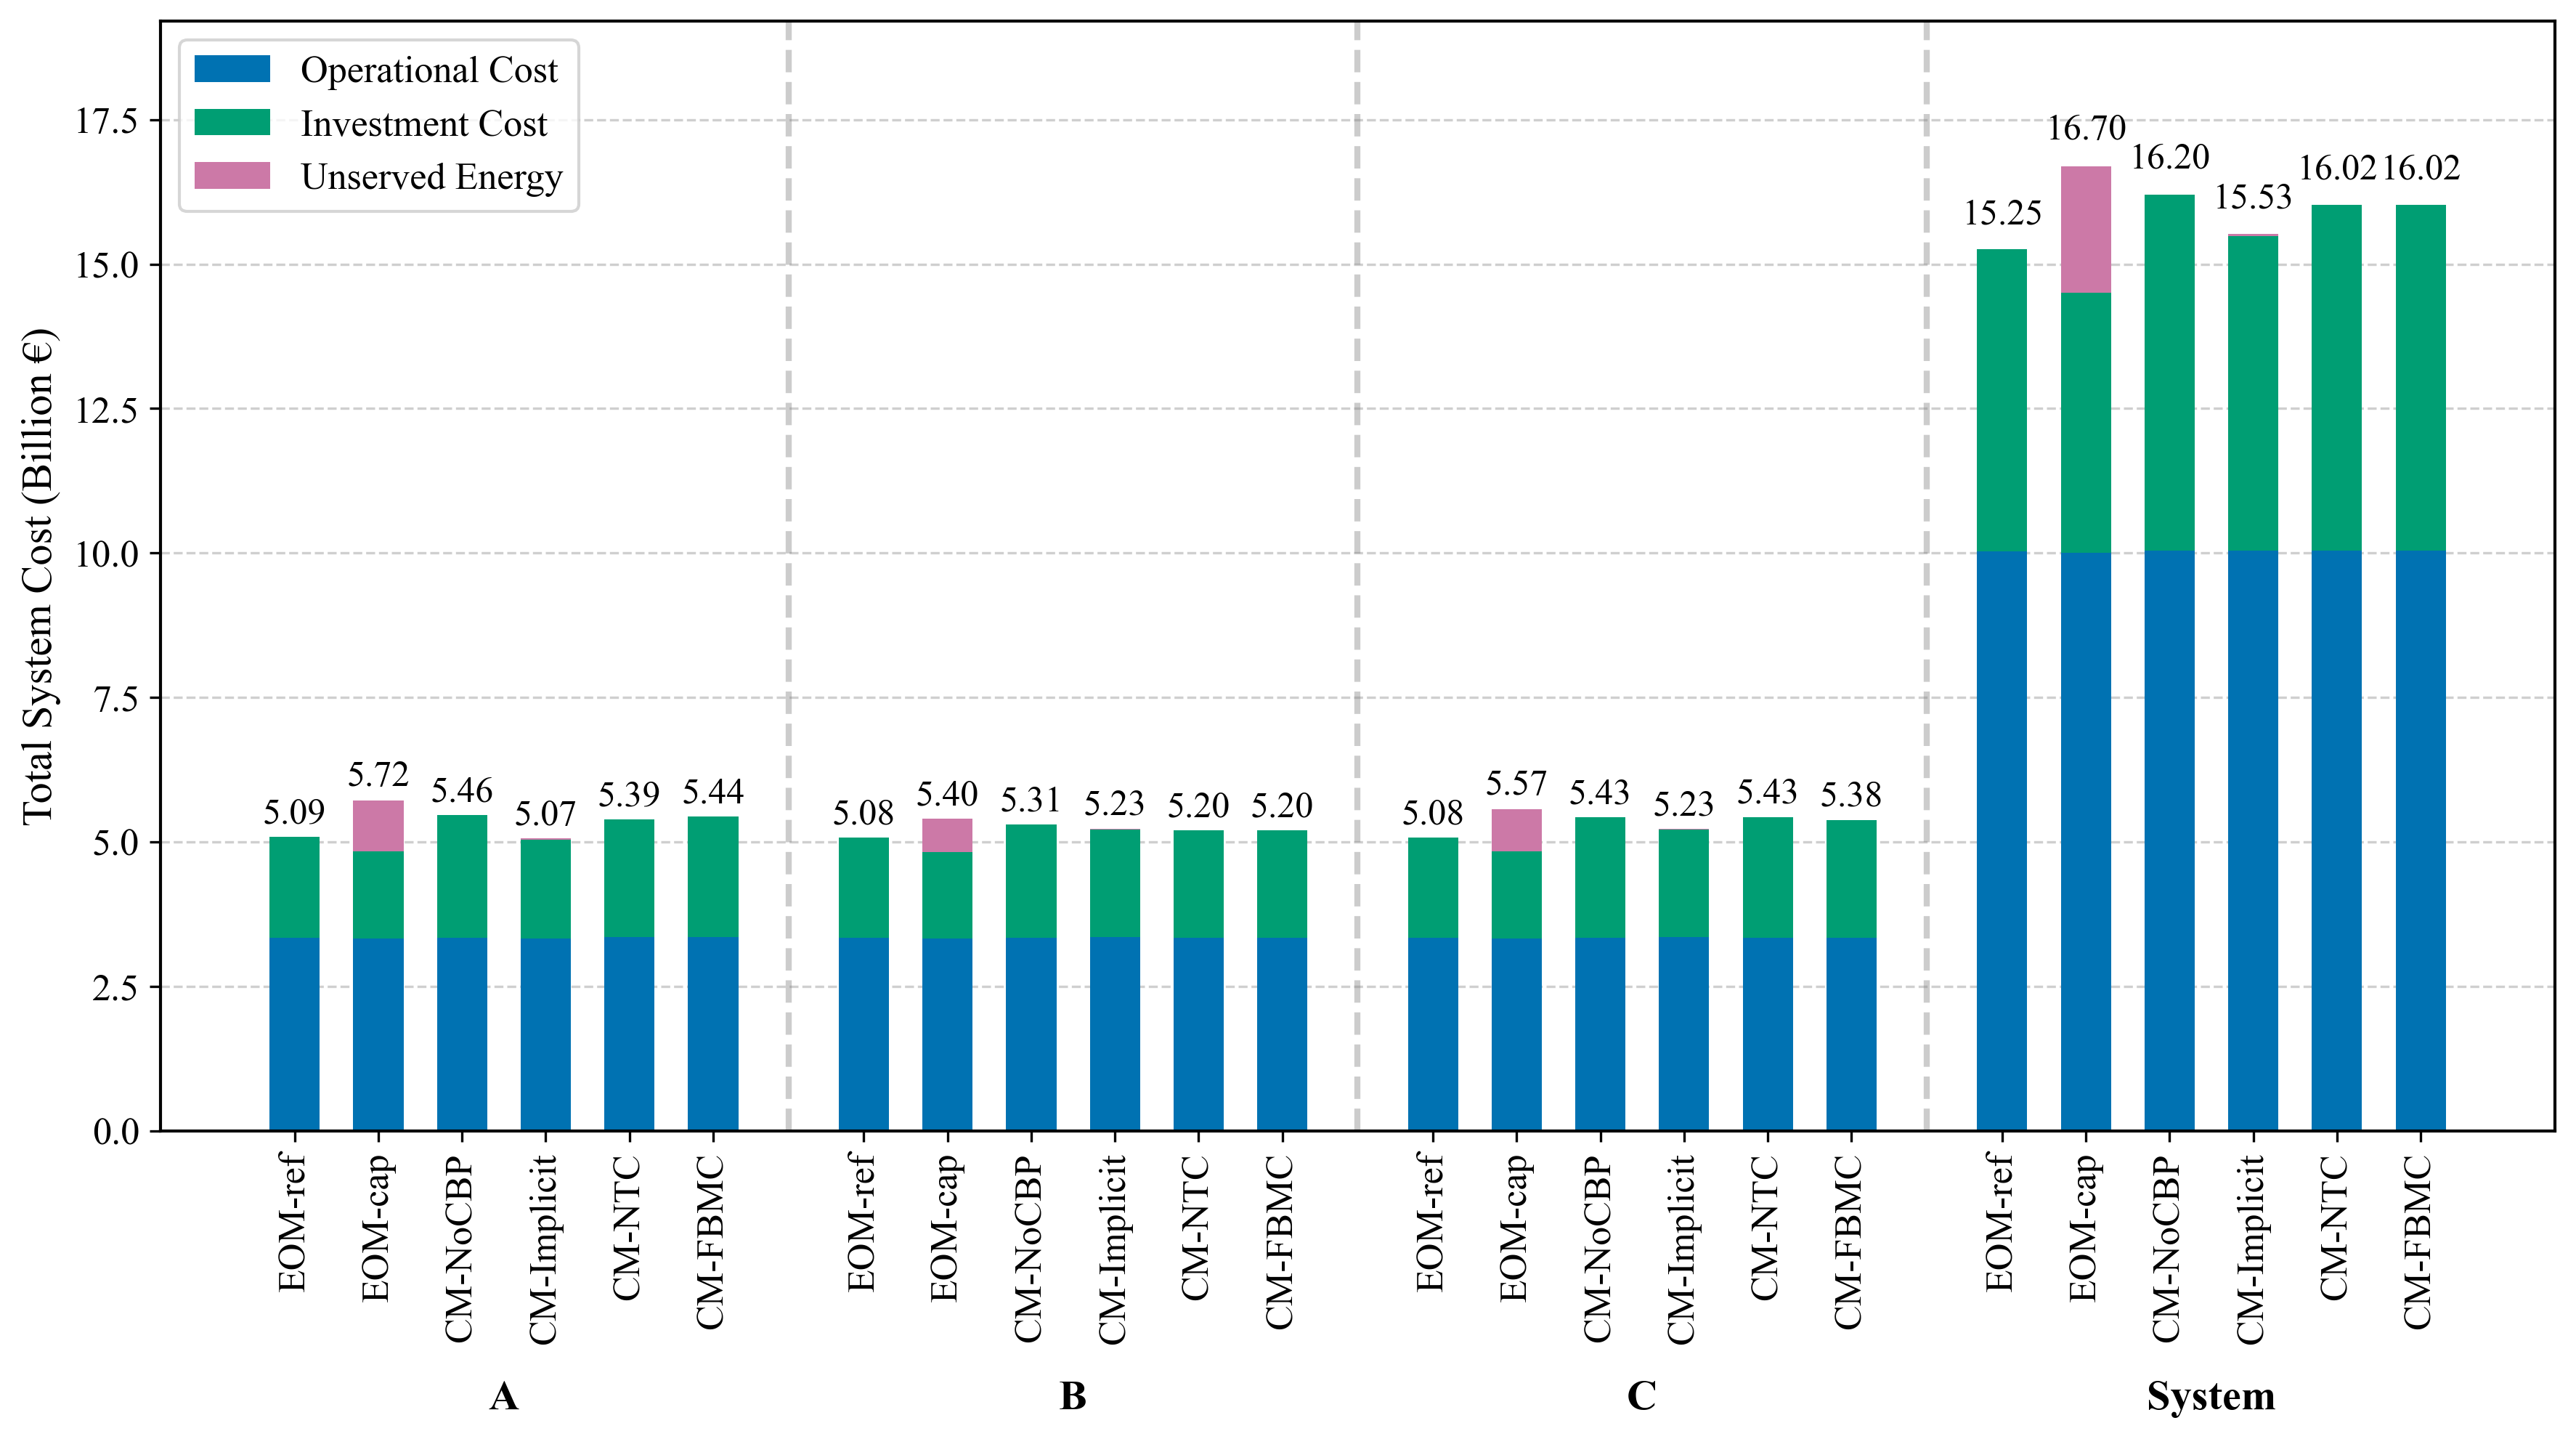

In [61]:
# Compute performance metrics for MCP model
print("=== MCP Performance Metrics ===")
performance_mcp = compute_performance_metrics(analysis_data, inputs, source_type="mcp")
print(performance_mcp)

# Plot
fig, ax = plot_performance_comparison(performance_mcp, source_type="mcp")
plt.show()

=== Planner Performance Metrics ===
      Zone    Design  GenerationCost  InvestmentCost       ENSCost  \
0        A       eom    3.399490e+09    1.748065e+09  0.000000e+00   
1        B       eom    3.399490e+09    1.748065e+09  0.000000e+00   
2        C       eom    3.401187e+09    1.855515e+09  0.000000e+00   
3   System       eom    1.020017e+10    5.351645e+09  0.000000e+00   
4        A  pricecap    3.379775e+09    1.494818e+09  7.507590e+08   
5        B  pricecap    3.379775e+09    1.494818e+09  7.194510e+08   
6        C  pricecap    3.426950e+09    1.692010e+09  5.827404e+08   
7   System  pricecap    1.018650e+10    4.681646e+09  2.052950e+09   
8        A     NoCBP    3.403978e+09    2.132366e+09  0.000000e+00   
9        B     NoCBP    3.403978e+09    1.981067e+09  0.000000e+00   
10       C     NoCBP    3.403978e+09    2.100169e+09  0.000000e+00   
11  System     NoCBP    1.021193e+10    6.213602e+09  0.000000e+00   
12       A  implicit    3.390518e+09    1.731244e+09  

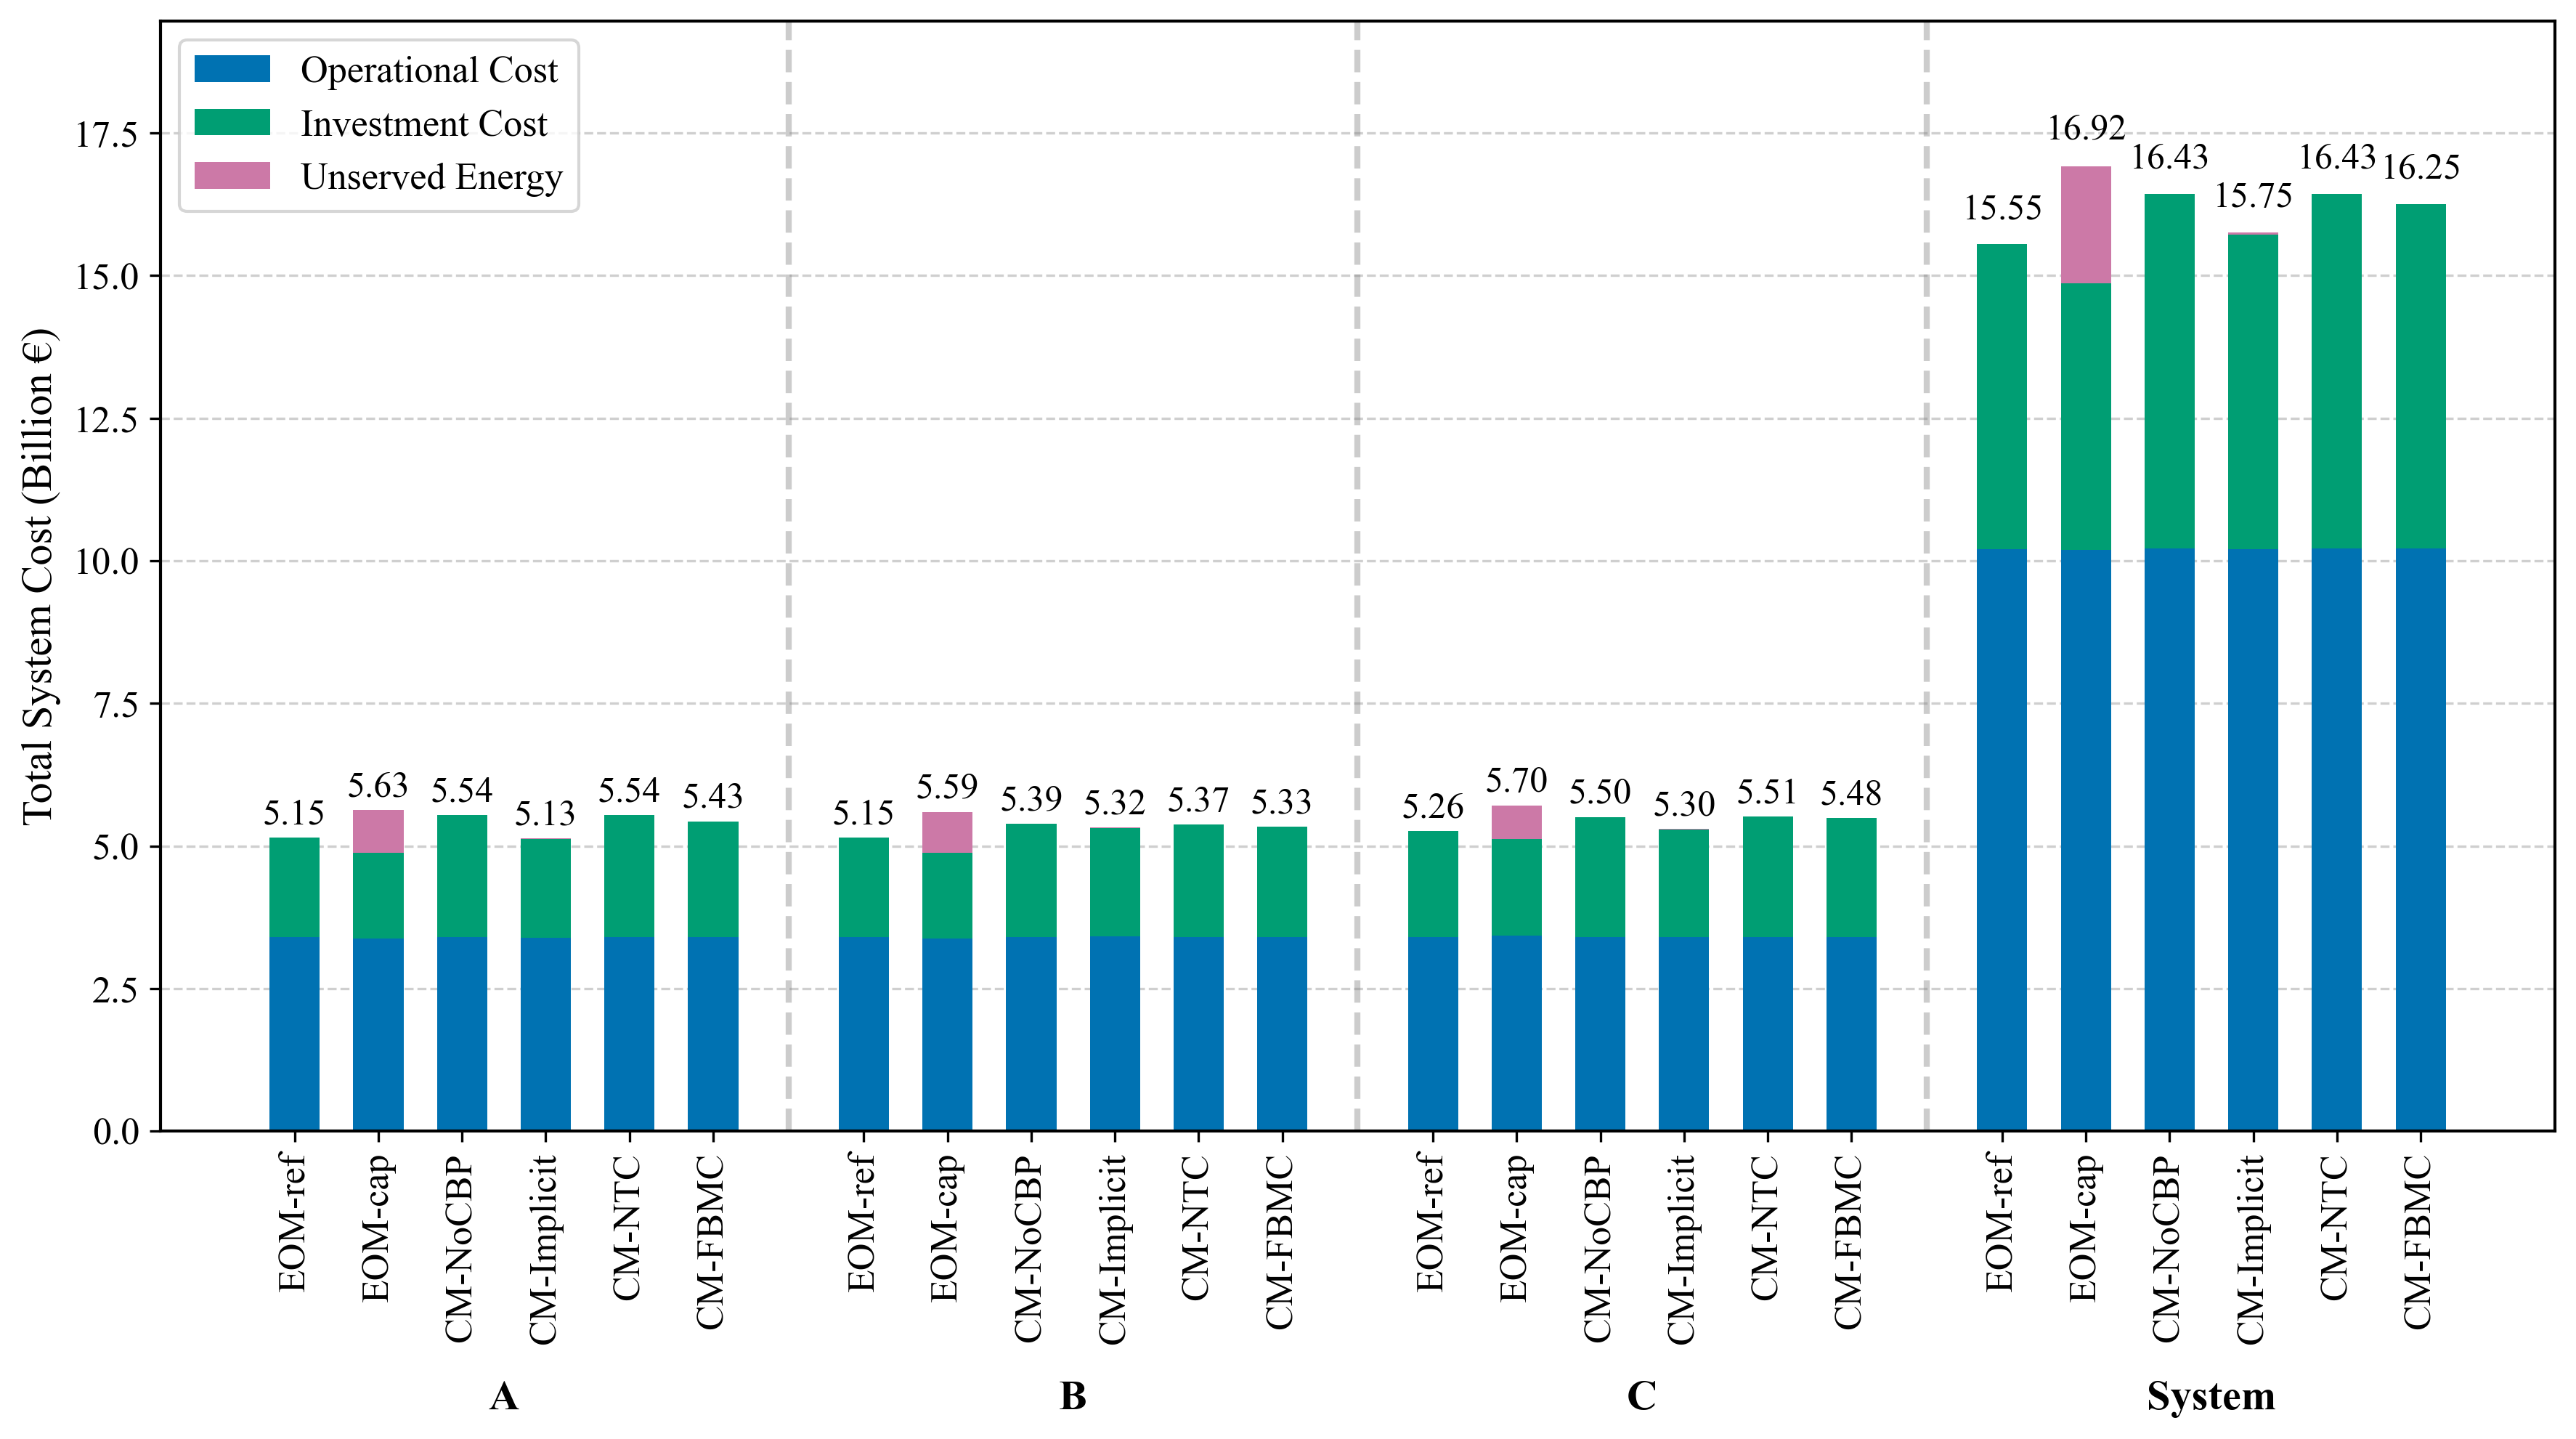

In [62]:
# Compute performance metrics for Planner model
print("=== Planner Performance Metrics ===")
performance_planner = compute_performance_metrics(analysis_data, inputs, source_type="planner")
print(performance_planner)

# Plot
fig, ax = plot_performance_comparison(performance_planner, source_type="planner")
plt.show()

In [63]:
# efficiency comparison between policies in each zone and system-wide relative to EOM
def compute_efficiency_losses(
    analysis_data: Dict[str, pd.DataFrame],
    inputs: dict,
    source_type: str = "mcp"
) -> pd.DataFrame:
    """
    Compute efficiency losses for each policy relative to EOM benchmark.
    Efficiency loss is measured as the percentage increase in total system cost.
    
    Loss % = ((Cost_Policy - Cost_EOM) / Cost_EOM) * 100
    Positive % = efficiency loss (policy is more expensive than EOM)
    Negative % = efficiency gain (policy is cheaper than EOM - rare)
    
    Parameters:
    - analysis_data: Dictionary of dataframes with results
    - inputs: Dictionary with config data and weights
    - source_type: "mcp" or "planner"
    
    Returns:
    - DataFrame with efficiency loss metrics by zone and design
    """
    # First get performance metrics
    performance_df = compute_performance_metrics(analysis_data, inputs, source_type)
    
    zones = ["A", "B", "C", "System"]
    design_keys = ["eom", "pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    records = []
    
    for zone in zones:
        # Get EOM baseline cost for this zone
        eom_row = performance_df[(performance_df["Zone"] == zone) & 
                                 (performance_df["Design"] == "eom")]
        
        if eom_row.empty:
            print(f"Warning: No EOM baseline found for zone {zone}")
            continue
        
        eom_cost = eom_row["TotalCost"].values[0]
        eom_gen_cost = eom_row["GenerationCost"].values[0]
        eom_inv_cost = eom_row["InvestmentCost"].values[0]
        eom_ens_cost = eom_row["ENSCost"].values[0]
        
        # Compare each design to EOM
        for design in design_keys:
            design_row = performance_df[(performance_df["Zone"] == zone) & 
                                       (performance_df["Design"] == design)]
            
            if design_row.empty:
                continue
            
            design_cost = design_row["TotalCost"].values[0]
            design_gen_cost = design_row["GenerationCost"].values[0]
            design_inv_cost = design_row["InvestmentCost"].values[0]
            design_ens_cost = design_row["ENSCost"].values[0]
            
            # Calculate efficiency LOSSES (positive = worse than EOM)
            total_loss = ((design_cost - eom_cost) / eom_cost * 100) if eom_cost > 0 else 0
            gen_loss = ((design_gen_cost - eom_gen_cost) / eom_gen_cost * 100) if eom_gen_cost > 0 else 0
            inv_loss = ((design_inv_cost - eom_inv_cost) / eom_inv_cost * 100) if eom_inv_cost > 0 else 0
            ens_loss = ((design_ens_cost - eom_ens_cost) / eom_ens_cost * 100) if eom_ens_cost > 0 else 0
            
            # Absolute cost differences (in billions for readability)
            total_diff = (design_cost - eom_cost) / 1e9
            gen_diff = (design_gen_cost - eom_gen_cost) / 1e9
            inv_diff = (design_inv_cost - eom_inv_cost) / 1e9
            ens_diff = (design_ens_cost - eom_ens_cost) / 1e9
            
            record = {
                "Zone": zone,
                "Design": design,
                "TotalLoss_pct": total_loss,
                "GenLoss_pct": gen_loss,
                "InvLoss_pct": inv_loss,
                "ENSLoss_pct": ens_loss,
                "TotalCostDiff_B€": total_diff,
                "GenCostDiff_B€": gen_diff,
                "InvCostDiff_B€": inv_diff,
                "ENSCostDiff_B€": ens_diff,
                "EOM_TotalCost": eom_cost,
                "Design_TotalCost": design_cost
            }
            
            records.append(record)
    
    return pd.DataFrame(records)


def plot_efficiency_losses(efficiency_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Plot efficiency losses showing percentage cost increase vs EOM
    Positive bars = efficiency loss (worse than EOM)
    Negative bars = efficiency gain (better than EOM)
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_LARGE)
    
    zones = ["A", "B", "C", "System"]
    design_order = ["pricecap", "NoCBP", "implicit", "NTC", "FBMC"]  # Exclude EOM
    
    # Bar settings
    bar_width = 0.6
    spacing_between_zones = 0.8
    current_x = 0
    x_positions = []
    x_labels = []
    zone_label_positions = []
    zone_boundaries = []
    
    for zone in zones:
        zone_df = efficiency_df[efficiency_df["Zone"] == zone]
        zone_start_x = current_x
        
        for design in design_order:
            row = zone_df[zone_df["Design"].str.lower() == design.lower()]
            if row.empty:
                continue
            
            loss = row["TotalLoss_pct"].values[0]
            
            # Color based on loss (positive = red, negative = green)
            color = "#D55E00" if loss >= 0 else "#009E73"  # Red/Green
            
            # Plot bar
            ax.bar(current_x, loss, width=bar_width, color=color, alpha=0.8)
            
            # Add value label
            label_y = loss + (0.1 if loss >= 0 else -0.1)
            ax.text(current_x, label_y, f"{loss:.2f}%", 
                   ha="center", va="bottom" if loss >= 0 else "top",
                   fontsize=FONT_SIZES['annotation'])
            
            x_positions.append(current_x)
            x_labels.append(map_policy_name(design))
            current_x += 1
        
        # Zone label
        if current_x > zone_start_x:
            mid = (zone_start_x + current_x - 1) / 2
            zone_label_positions.append((mid, f"{zone}"))
            zone_boundaries.append(current_x - 0.5)
            current_x += spacing_between_zones
    
    # X-axis labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZES['tick_label'], rotation=90)
    
    # Zone labels
    for xpos, label in zone_label_positions:
        zone_designs = x_positions[int(xpos - (xpos % len(design_order))):
                                   int(xpos - (xpos % len(design_order)) + len(design_order))]
        if zone_designs:
            midpoint = (zone_designs[0] + zone_designs[-1]) / 2
        else:
            midpoint = xpos
        ax.text(midpoint, -0.25, label, ha='center', transform=ax.get_xaxis_transform(),
               fontsize=FONT_SIZES['zone_label'], fontweight='bold')
    
    # Vertical separators
    for boundary in zone_boundaries[:-1]:
        ax.axvline(x=boundary + spacing_between_zones / 2, color='gray',
                  linestyle='--', alpha=0.4)
    
    # Zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Styling
    ax.set_ylabel('Efficiency Loss vs EOM (%)', fontsize=FONT_SIZES['axis_label'])
    
    # Set symmetric y-limits
    max_abs = max(abs(efficiency_df["TotalLoss_pct"].min()),
                  abs(efficiency_df["TotalLoss_pct"].max()))
    ax.set_ylim(-max_abs * 1.2, max_abs * 1.2)
    
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    
    # Legend
    legend_elements = [
        Patch(facecolor="#D55E00", alpha=0.8, label='Efficiency loss (higher cost)'),
        Patch(facecolor="#009E73", alpha=0.8, label='Efficiency gain (lower cost)')
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=FONT_SIZES['tick_label'])
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    return fig, ax


def print_efficiency_loss_summary(efficiency_df: pd.DataFrame, source_type: str = "mcp"):
    """
    Print a formatted summary table of efficiency loss metrics
    """
    print(f"\n{'='*80}")
    print(f"EFFICIENCY LOSS ANALYSIS vs EOM BASELINE ({source_type.upper()})")
    print(f"{'='*80}\n")
    
    zones = ["A", "B", "C", "System"]
    designs = ["pricecap", "NoCBP", "implicit", "NTC", "FBMC"]
    
    for zone in zones:
        zone_df = efficiency_df[efficiency_df["Zone"] == zone]
        if zone_df.empty:
            continue
        
        print(f"\n{zone}:")
        print(f"{'-'*80}")
        print(f"{'Design':<15} {'Total Loss%':<12} {'Gen Loss%':<12} {'Inv Loss%':<12} {'ENS Loss%':<12} {'Cost Diff (B€)':<15}")
        print(f"{'-'*80}")
        
        for design in designs:
            row = zone_df[zone_df["Design"] == design]
            if row.empty:
                continue
            
            print(f"{map_policy_name(design):<15} "
                  f"{row['TotalLoss_pct'].values[0]:>10.2f}% "
                  f"{row['GenLoss_pct'].values[0]:>10.2f}% "
                  f"{row['InvLoss_pct'].values[0]:>10.2f}% "
                  f"{row['ENSLoss_pct'].values[0]:>10.2f}% "
                  f"{row['TotalCostDiff_B€'].values[0]:>13.3f}")
    
    print(f"\n{'='*80}")
    print("Note: Positive % = efficiency LOSS (policy costs MORE than EOM)")
    print("      Negative % = efficiency GAIN (policy costs LESS than EOM)")
    print(f"{'='*80}\n")


# Usage example
def analyze_efficiency_losses(analysis_data, inputs, source_type="mcp"):
    """
    Complete efficiency loss analysis workflow
    """
    # Compute efficiency loss metrics
    efficiency_losses = compute_efficiency_losses(analysis_data, inputs, source_type)
    
    # Print summary
    print_efficiency_loss_summary(efficiency_losses, source_type)
    
    # Plot comparison
    fig, ax = plot_efficiency_losses(efficiency_losses, source_type)
    plt.show()
    
    return efficiency_losses

=== MCP Model Efficiency Loss Analysis ===

EFFICIENCY LOSS ANALYSIS vs EOM BASELINE (MCP)


A:
--------------------------------------------------------------------------------
Design          Total Loss%  Gen Loss%    Inv Loss%    ENS Loss%    Cost Diff (B€) 
--------------------------------------------------------------------------------
EOM-cap              12.47%      -0.25%     -13.82%       0.00%         0.635
CM-NoCBP              7.39%       0.12%      21.36%       0.00%         0.376
CM-Implicit          -0.42%      -0.36%      -1.68%       0.00%        -0.021
CM-NTC                5.93%       0.14%      17.07%       0.00%         0.302
CM-FBMC               6.89%       0.14%      19.86%       0.00%         0.351

B:
--------------------------------------------------------------------------------
Design          Total Loss%  Gen Loss%    Inv Loss%    ENS Loss%    Cost Diff (B€) 
--------------------------------------------------------------------------------
EOM-cap           

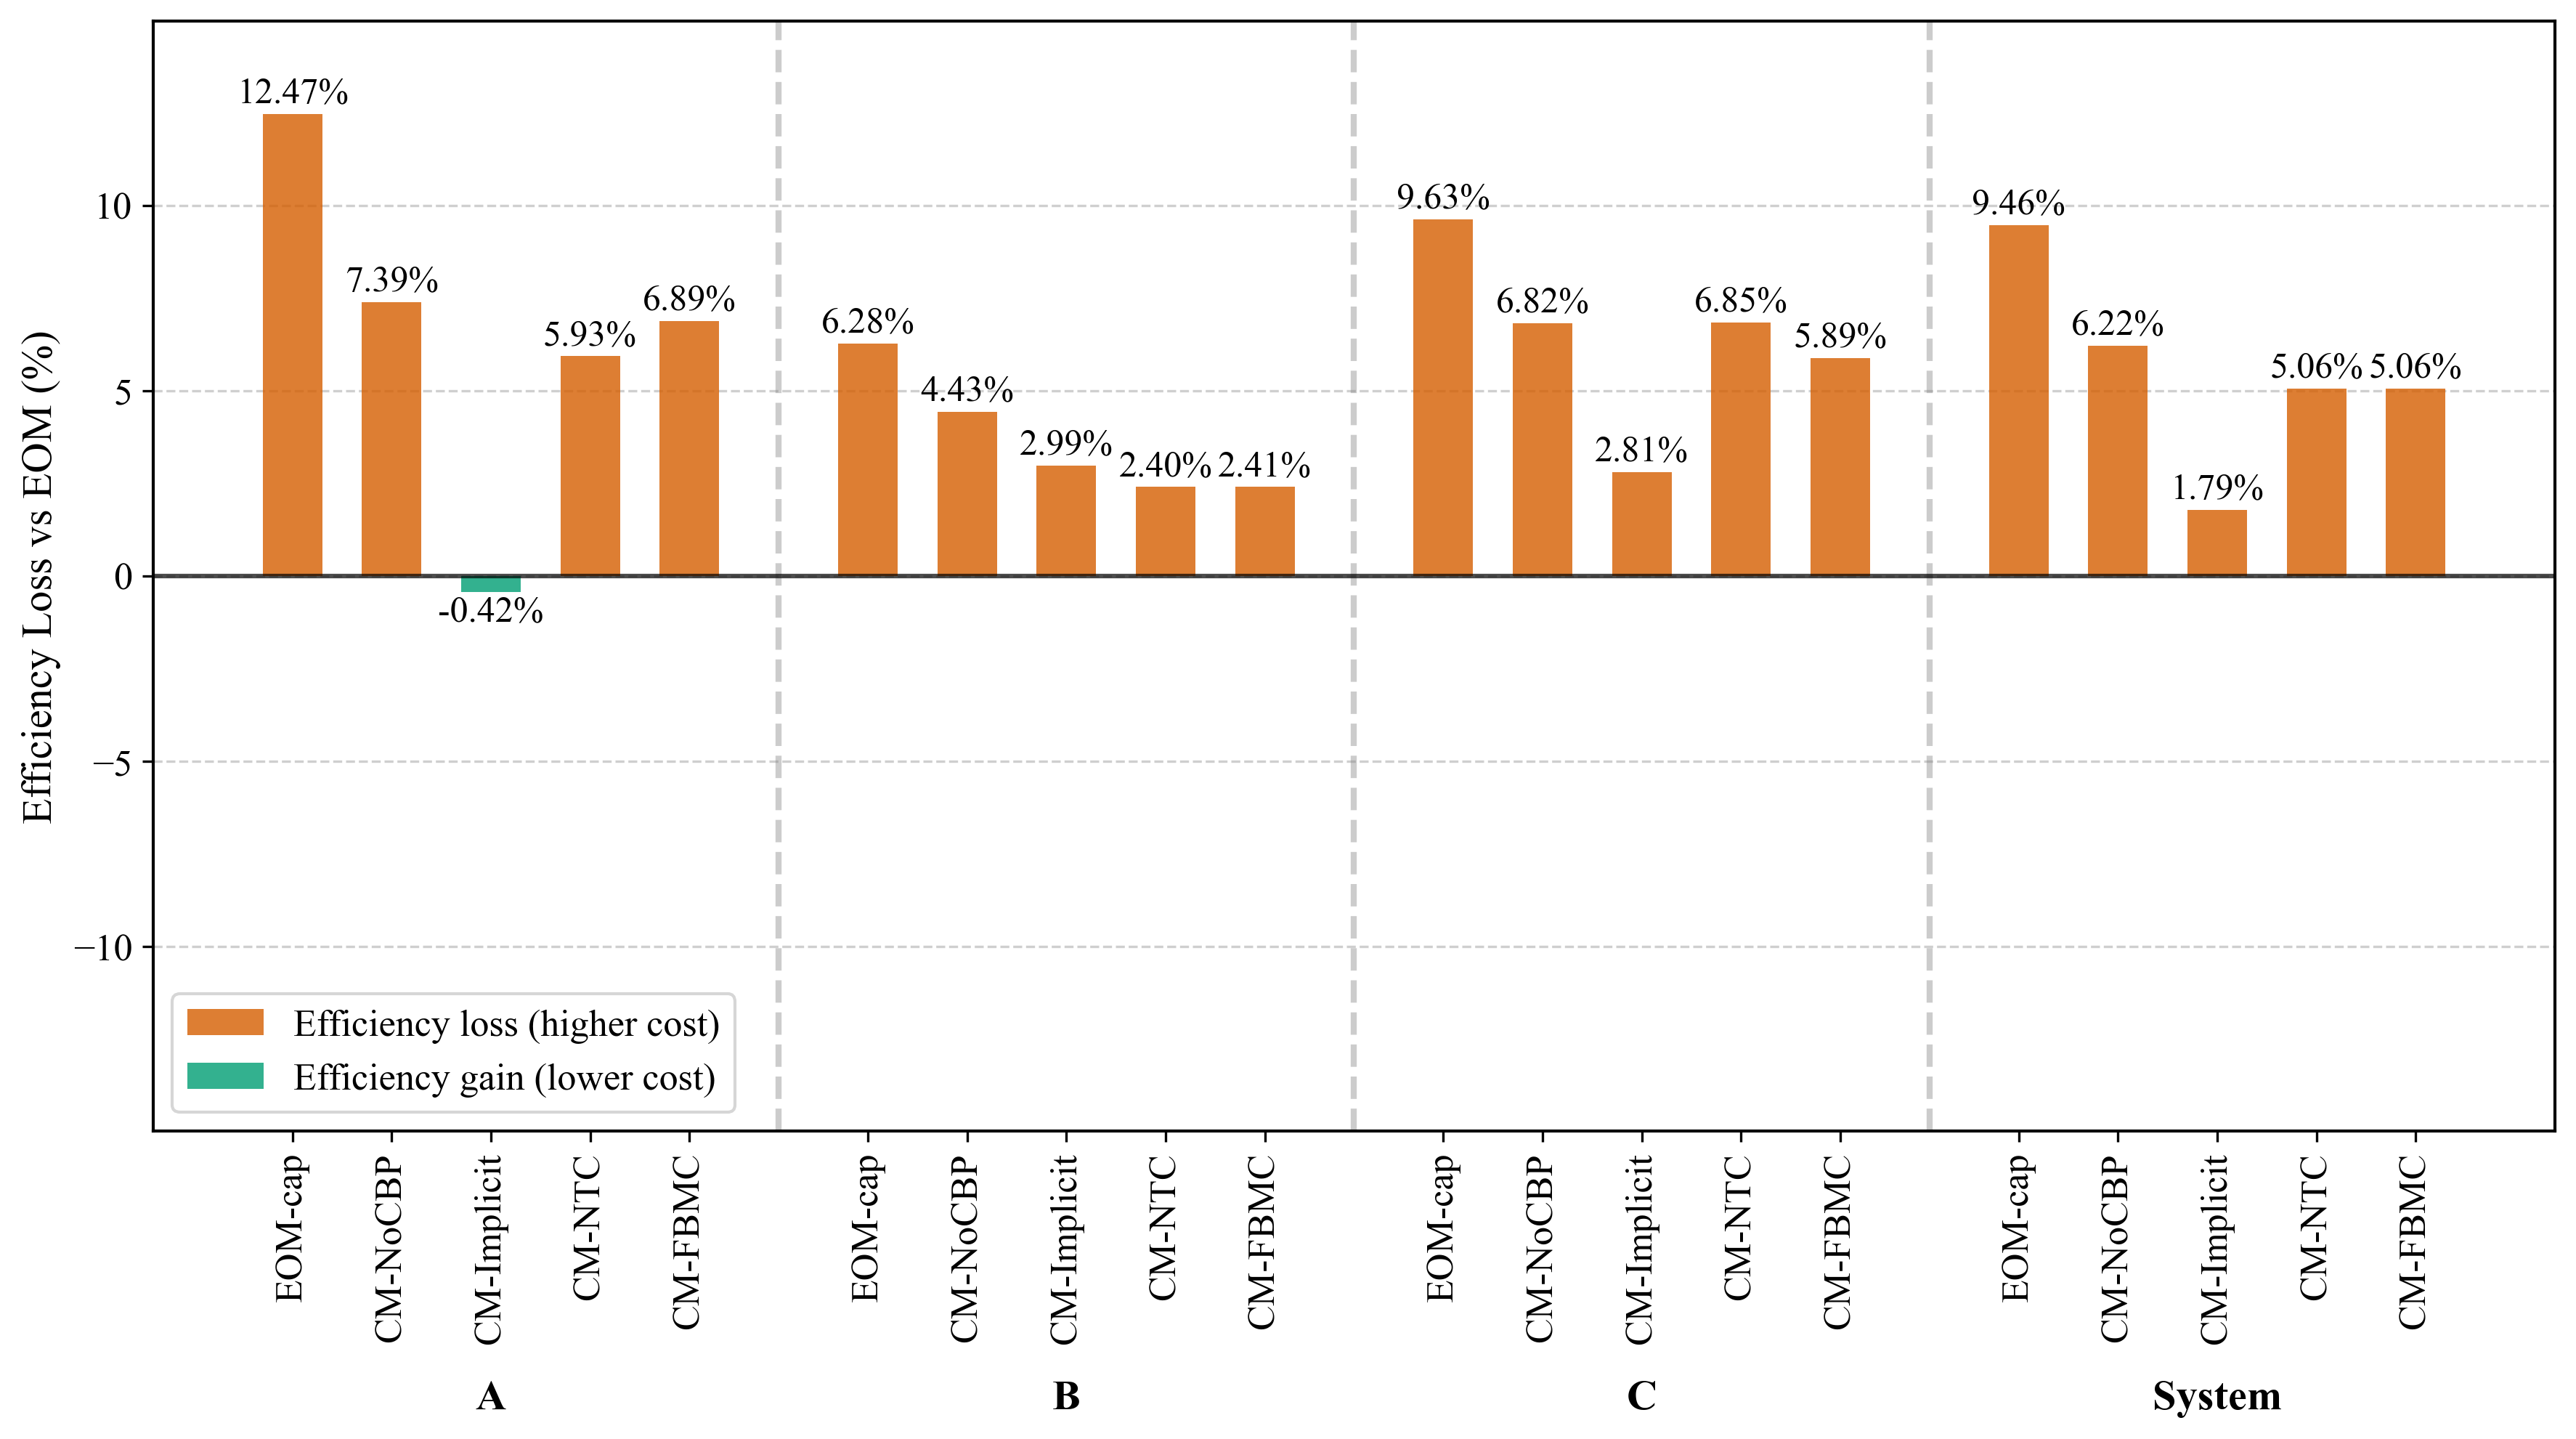

In [64]:
# Analyze efficiency losses for MCP model
print("=== MCP Model Efficiency Loss Analysis ===")
losses_mcp = analyze_efficiency_losses(analysis_data, inputs, source_type="mcp")


=== Planner Model Efficiency Loss Analysis ===

EFFICIENCY LOSS ANALYSIS vs EOM BASELINE (PLANNER)


A:
--------------------------------------------------------------------------------
Design          Total Loss%  Gen Loss%    Inv Loss%    ENS Loss%    Cost Diff (B€) 
--------------------------------------------------------------------------------
EOM-cap               9.28%      -0.58%     -14.49%       0.00%         0.478
CM-NoCBP              7.55%       0.13%      21.98%       0.00%         0.389
CM-Implicit          -0.26%      -0.26%      -0.96%       0.00%        -0.013
CM-NTC                7.62%       0.13%      22.19%       0.00%         0.392
CM-FBMC               5.54%       0.13%      16.06%       0.00%         0.285

B:
--------------------------------------------------------------------------------
Design          Total Loss%  Gen Loss%    Inv Loss%    ENS Loss%    Cost Diff (B€) 
--------------------------------------------------------------------------------
EOM-cap  

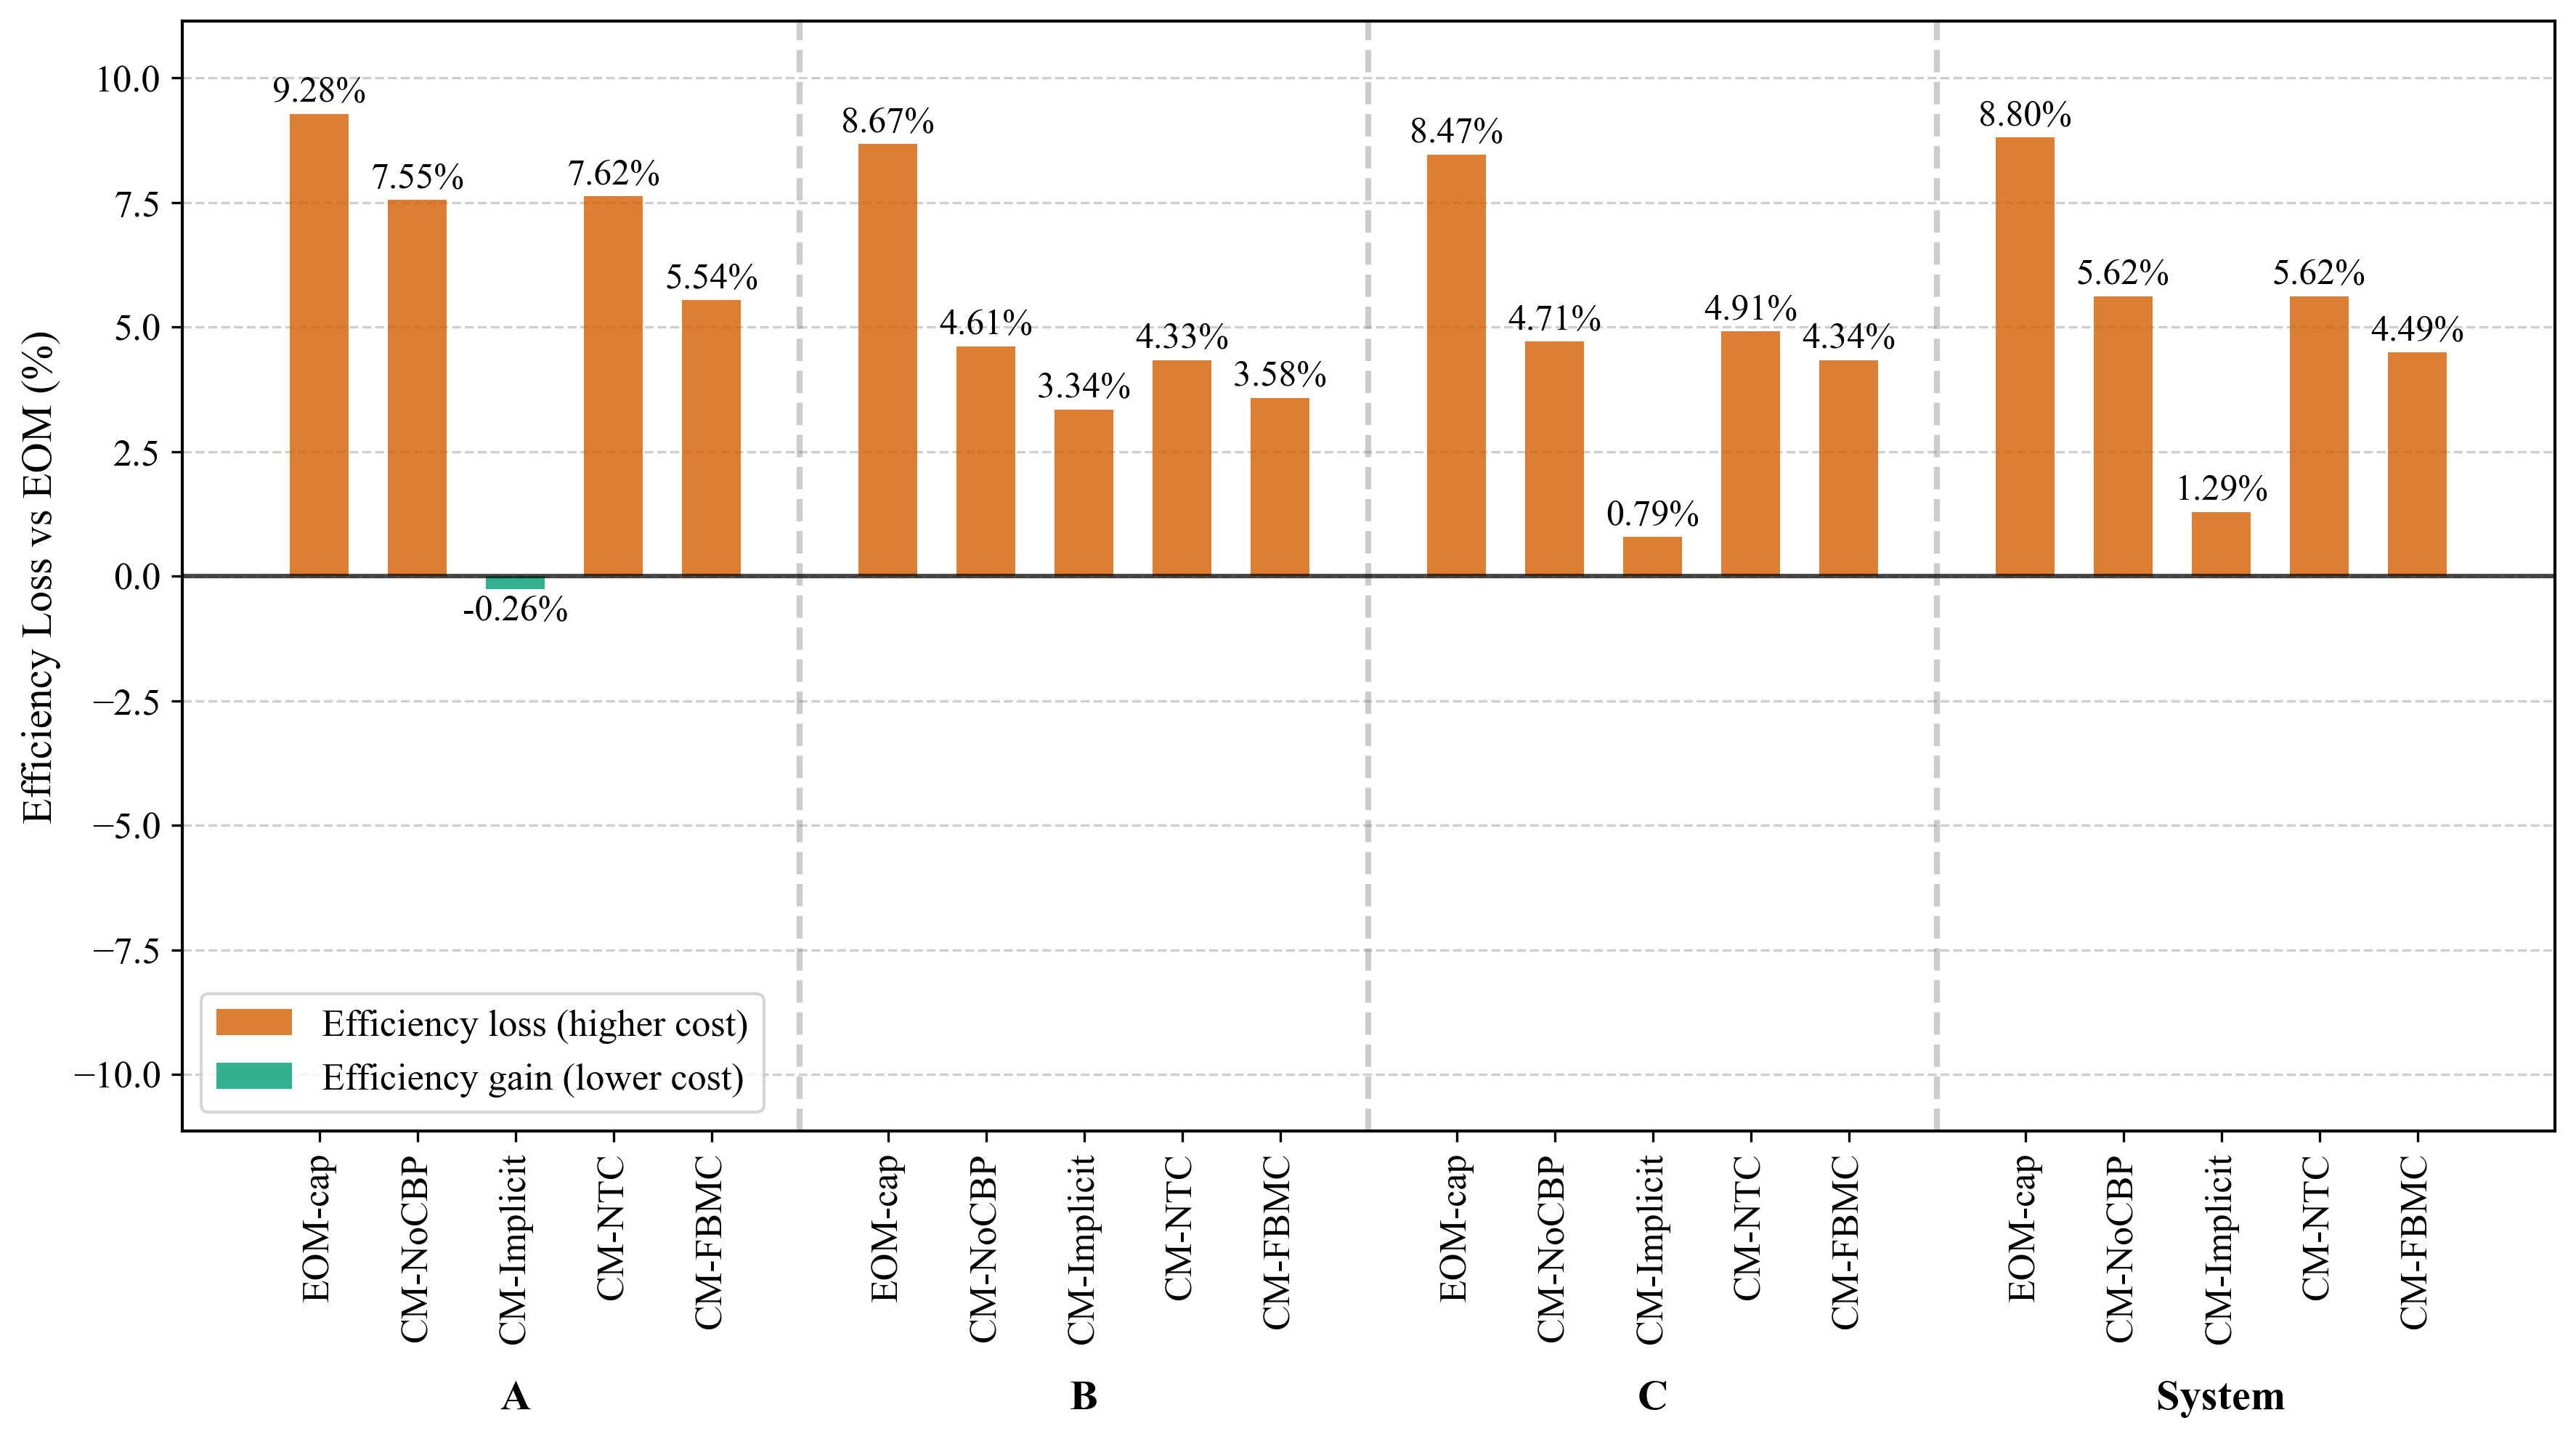

In [65]:

# Analyze efficiency losses for Planner model
print("\n=== Planner Model Efficiency Loss Analysis ===")
losses_planner = analyze_efficiency_losses(analysis_data, inputs, source_type="planner")

### Sensitivity

In [66]:
# sensitivity of average cost to interconnector capacity

In [67]:
# Demand curve

Calibration parameter e: 0.2000
Elasticity at price cap (when Q=D_z): 0.0400 (target: 0.04)

Inelastic demand d_inel: 0.8000 (80.00% of D_z)
Elastic demand at price cap: 0.1600 (16.00% of D_z)

Slope dp/dQ: -100000.00 €/MWh per MW

Verification:
Total demand at price cap: 0.9599 D_z (target: 0.96 D_z)
Elasticity at price cap: 0.0417 (target: 0.04)
Elasticity at w_max: 0.2500 (target: 0.20)
Total demand at p=0: 1.0000 D_z (100.00% of D_z)


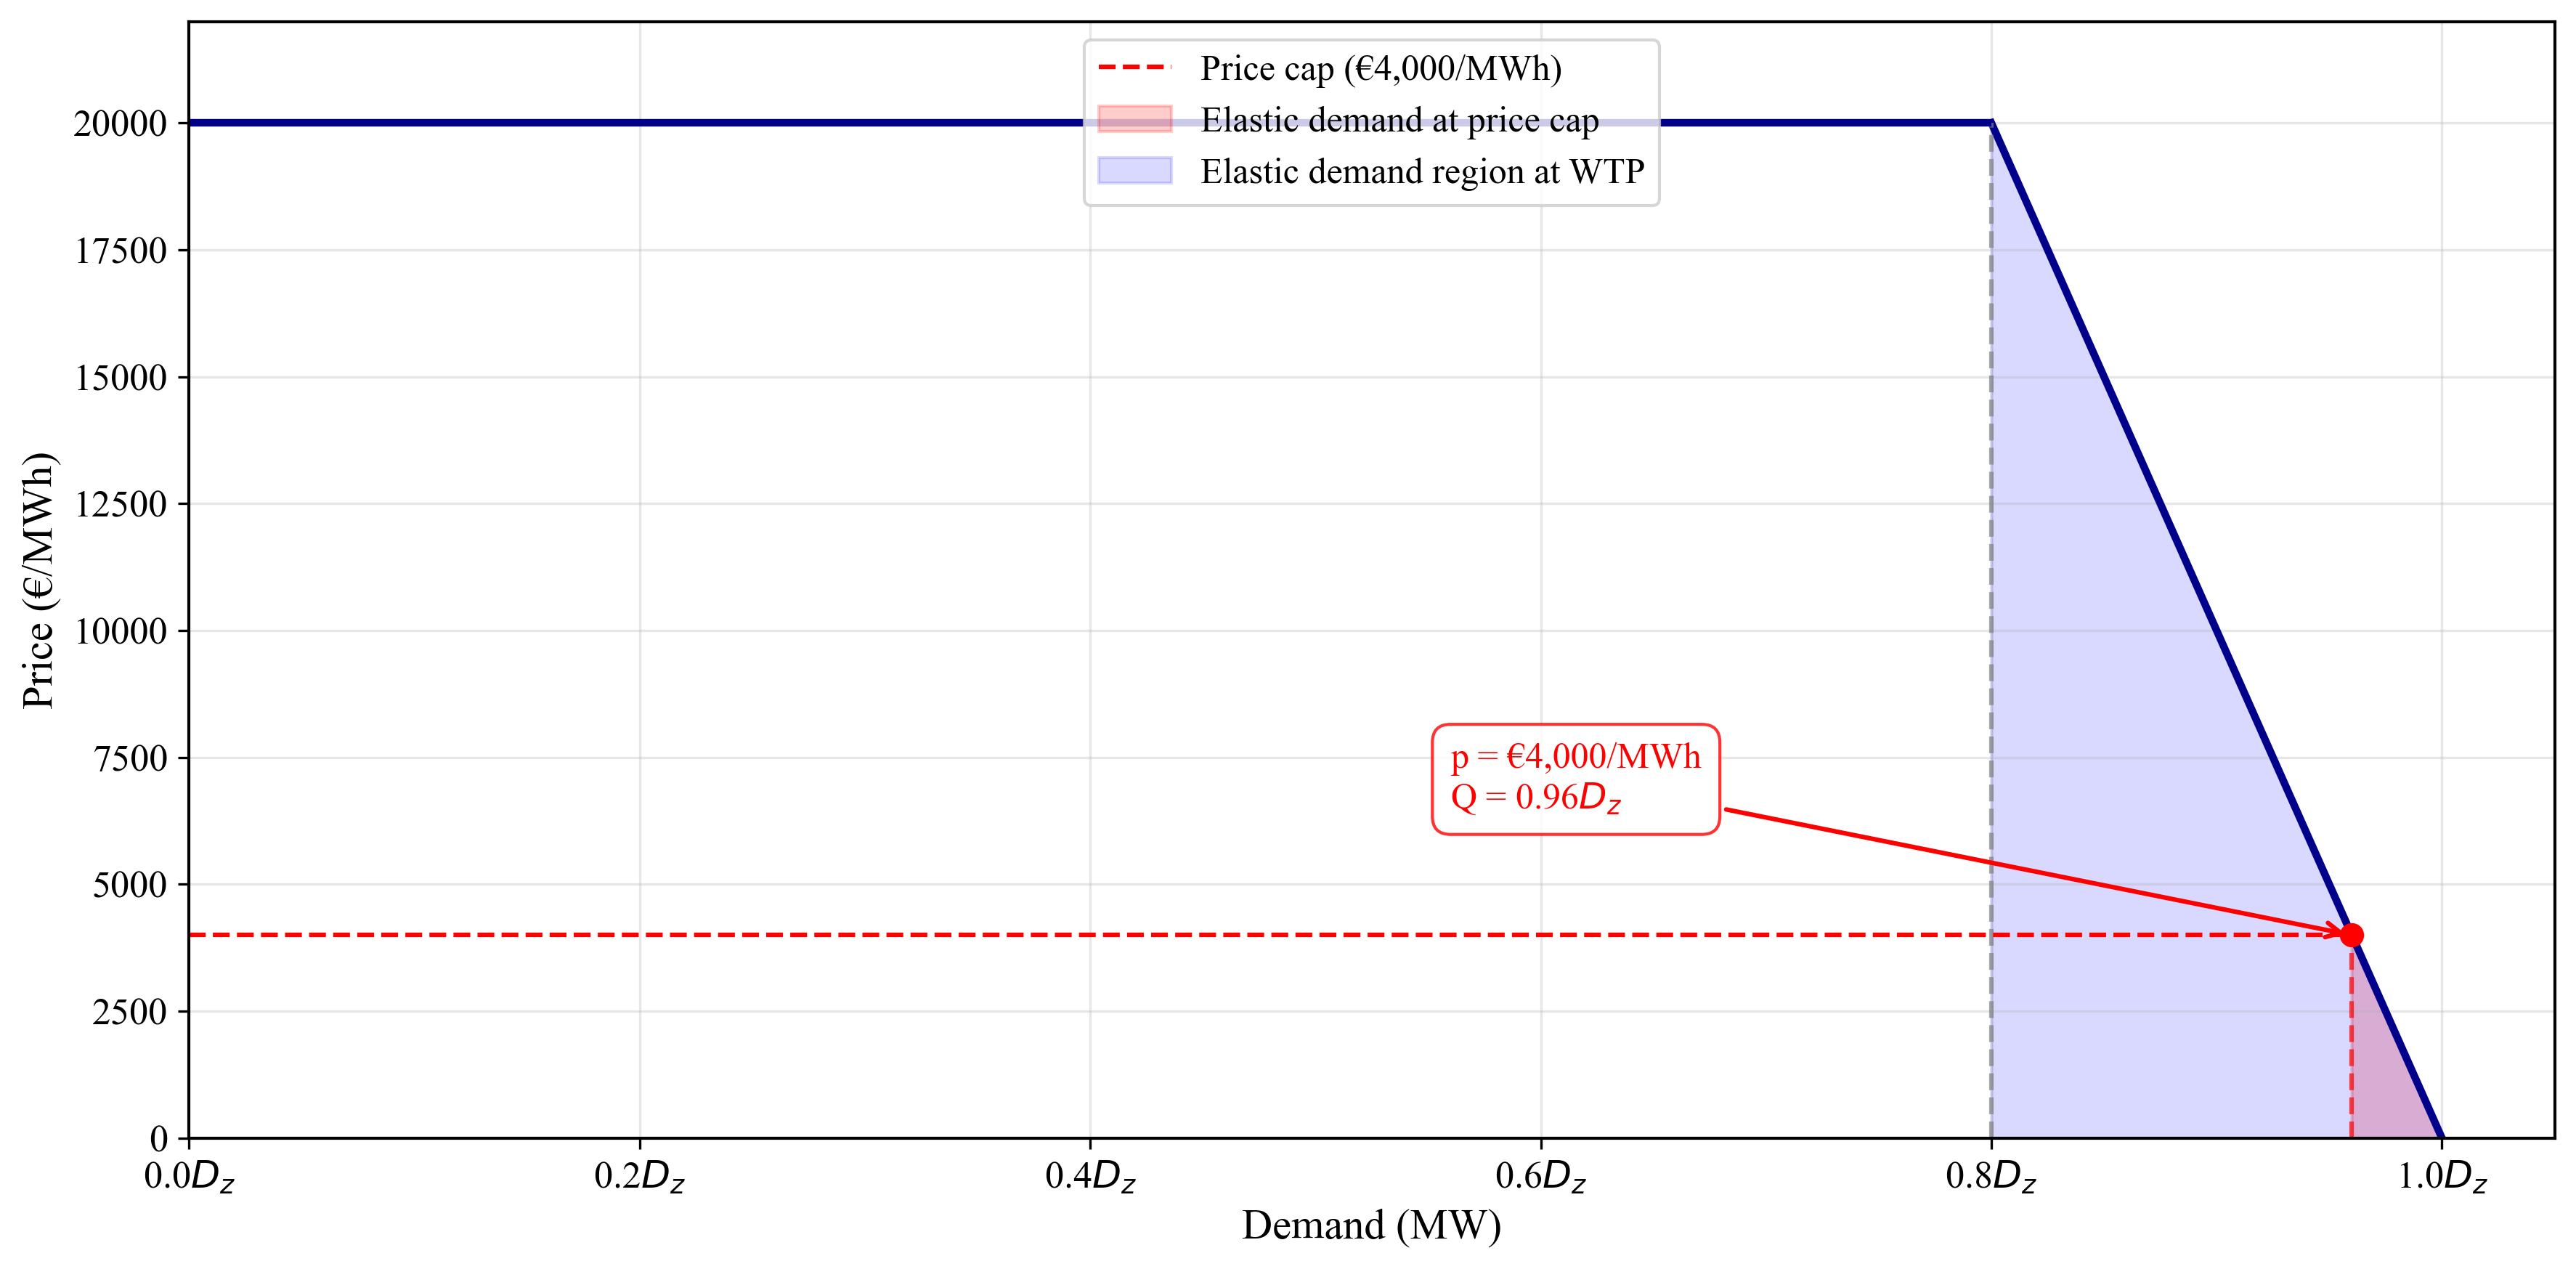


=== Summary ===
Parameter                           Value                Formula
--------------------------------------------------------------------------------
Calibration e                       0.2000                 ε₀(w/p₀)
Inelastic demand (d_inel)           0.8000 D_z (80.0%)  Q_cap - elastic_cap
Demand at price cap                 0.9599 D_z (96.0%)  d_inel + (eD_z/w)(w-p)
Elastic at price cap                0.1600 D_z (16.0%)
Demand at p=0                       1.0000 D_z (100.0%)
Elasticity at w_max                 0.2500                 -e(w/Q)
Elasticity at price cap             0.0417                 -(eD_z/w)(p/Q)
Slope (dp/dQ)                       -100000.00 €/MWh/MW    -w/(eD_z)


In [68]:

# Parameters
w_max = 20000      # Max willingness to pay (€/MWh)
price_cap = 4000   # Price cap (€/MWh)
D_z = 1.0          # Normalized total reference demand

# Target elasticities (absolute values)
epsilon_at_wmax = 0.20    # 20% elasticity at w_max
epsilon_at_cap = 0.04     # 4% elasticity at price_cap

# Step 1: Calibrate e using equation (8): e = -ε(p) * (w/p)
# At p = w_max, we want |ε| = 0.20
# Since we're at the top of the demand curve, let's use this point
e = epsilon_at_wmax * (w_max / w_max)  # This gives e = 0.20
print(f"Calibration parameter e: {e:.4f}")

# Verify: At price_cap, with e = 0.20, what's the elasticity?
# From equation (7): ε(p) = -e * (p/w) when Q = D_z
# At p = 4000: ε = -0.20 * (4000/20000) = -0.04 ✓
epsilon_check_cap = e * (price_cap / w_max)
print(f"Elasticity at price cap (when Q=D_z): {epsilon_check_cap:.4f} (target: 0.04)")

# Step 2: Determine d_inel from the constraint that at price_cap, Q_tot = 0.96*D_z
# From equation (3): Q_tot(p) = d_inel + (e*D_z/w)*(w - p)
# At price_cap: 0.96*D_z = d_inel + (0.20*1.0/20000)*(20000 - 4000)
# Solve for d_inel
Q_at_cap_target = 0.96 * D_z
elastic_at_cap = (e * D_z / w_max) * (w_max - price_cap)
d_inel = Q_at_cap_target - elastic_at_cap
print(f"\nInelastic demand d_inel: {d_inel:.4f} ({d_inel/D_z*100:.2f}% of D_z)")
print(f"Elastic demand at price cap: {elastic_at_cap:.4f} ({elastic_at_cap/D_z*100:.2f}% of D_z)")

# Step 3: Generate the demand curve
# From equation (3): Q_tot(p) = d_inel + (e*D_z/w)*(w - p)
p = np.linspace(0, w_max, 500)
d_elastic = (e * D_z / w_max) * (w_max - p)
d_total = d_inel + d_elastic
d_pct = d_total / D_z

# Step 4: Calculate slope from equation (5)
slope = -w_max / (e * D_z)
print(f"\nSlope dp/dQ: {slope:.2f} €/MWh per MW")

# Step 5: Verify elasticities at key points using equation (6)
cap_idx = np.argmin(np.abs(p - price_cap))
Q_at_cap_actual = d_total[cap_idx]

# Elasticity at price cap using equation (6): ε(p) = -(e*D_z/w) * (p/Q_tot)
elasticity_at_cap = -(e * D_z / w_max) * (price_cap / Q_at_cap_actual)
print(f"\nVerification:")
print(f"Total demand at price cap: {Q_at_cap_actual:.4f} D_z (target: 0.96 D_z)")
print(f"Elasticity at price cap: {abs(elasticity_at_cap):.4f} (target: 0.04)")

# At w_max, only inelastic demand is active
elasticity_at_wmax = -(e * D_z / w_max) * (w_max / d_inel)
print(f"Elasticity at w_max: {abs(elasticity_at_wmax):.4f} (target: 0.20)")
print(f"Total demand at p=0: {d_total[0]:.4f} D_z ({d_total[0]/D_z*100:.2f}% of D_z)")

# Plot
plt.figure(figsize=FIGSIZE_LARGE)

# Total demand curve - inverse demand function
plt.plot(d_pct, p, color='darkblue', linewidth=2.5)

# Inelastic demand line
plt.vlines(x=d_inel/D_z, ymin=0, ymax=w_max, colors='gray', linestyles='--', 
           linewidth=1.5, alpha=0.7)

# Reference lines
plt.hlines(y=w_max, xmin=0, xmax=d_inel/D_z, colors='darkblue', linestyles='-', 
           linewidth=2.5)
plt.hlines(y=price_cap, xmin=0, xmax=d_pct[cap_idx], colors='red', linestyles='--', 
           linewidth=1.5, label=f'Price cap (€{price_cap:,}/MWh)')

# Mark point at price cap
plt.plot(d_pct[cap_idx], price_cap, 'ro', markersize=7)

# Add annotation for price cap point with both p and Q values
plt.annotate(f'p = €{price_cap:,}/MWh\nQ = {Q_at_cap_actual:.2f}$D_z$', 
             xy=(d_pct[cap_idx], price_cap), 
             xytext=(d_pct[cap_idx] - 0.40, price_cap + 2500),
             fontsize=FONT_SIZES['annotation'], color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='red'),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Add vertical line from price cap point to x-axis
plt.vlines(x=d_pct[cap_idx], ymin=0, ymax=price_cap, colors='red', linestyles='--', 
           linewidth=1.5, alpha=0.7)

# Shade elastic demand region at price cap (between vertical line and demand curve)
# Create array of prices from 0 to price_cap
p_fill = np.linspace(0, price_cap, 100)
# Calculate corresponding demand quantities
d_fill = d_inel/D_z + (e * D_z / w_max) * (w_max - p_fill) / D_z
# Shade the region between the vertical line at Q_cap and the demand curve
plt.fill_betweenx(p_fill, d_pct[cap_idx], d_fill, 
                   where=(d_fill >= d_pct[cap_idx]),
                   alpha=0.2, color='red', 
                   label='Elastic demand at price cap')

# Shade elastic region
plt.fill_betweenx(p, d_inel/D_z, d_pct, alpha=0.15, color='blue', 
                   label='Elastic demand region at WTP')

# Axes
plt.xlim(0, max(d_pct) * 1.05)
plt.ylim(0, w_max * 1.1)

# Custom x-axis ticks
x_max = max(d_pct)
x_tick_values = np.arange(0, x_max + 0.2, 0.2)
x_tick_labels = [f'{val:.1f}$D_z$' for val in x_tick_values]
plt.xticks(x_tick_values, x_tick_labels, fontsize=FONT_SIZES['tick_label'])

plt.xlabel('Demand (MW)', fontsize=FONT_SIZES['axis_label'])
plt.ylabel('Price (€/MWh)', fontsize=FONT_SIZES['axis_label'])
# plt.title('Inverse Demand Curve\n' + 
#           r'$p = \bar{w} - \frac{\bar{w}}{e D_z}(Q - d_{\mathrm{inel}})$' + 
#           f'\n$e = {e:.2f}$, $d_{{\\mathrm{{inel}}}} = {d_inel:.4f}D_z$', 
#           fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center', fontsize=FONT_SIZES['annotation'])

# Slope annotation
mid_idx = len(p) // 2
# plt.annotate(f'${slope:.0f}$ €/MWh per MW', 
#              xy=(d_pct[mid_idx], p[mid_idx]), 
#              xytext=(d_pct[mid_idx] + 0.15, p[mid_idx] + 3000),
#              fontsize=FONT_SIZES['tick_label'], color='darkblue',
#              arrowprops=dict(arrowstyle='->', color='darkblue', lw=1))

plt.tight_layout()
plt.show()

# Summary table
print("\n=== Summary ===")
print(f"{'Parameter':<35} {'Value':<20} {'Formula'}")
print("-" * 80)
print(f"{'Calibration e':<35} {e:.4f}{'':<16} ε₀(w/p₀)")
print(f"{'Inelastic demand (d_inel)':<35} {d_inel:.4f} D_z ({d_inel/D_z*100:.1f}%){'':<1} Q_cap - elastic_cap")
print(f"{'Demand at price cap':<35} {Q_at_cap_actual:.4f} D_z ({Q_at_cap_actual/D_z*100:.1f}%){'':<1} d_inel + (eD_z/w)(w-p)")
print(f"{'Elastic at price cap':<35} {elastic_at_cap:.4f} D_z ({elastic_at_cap/D_z*100:.1f}%)")
print(f"{'Demand at p=0':<35} {d_total[0]:.4f} D_z ({d_total[0]/D_z*100:.1f}%)")
print(f"{'Elasticity at w_max':<35} {abs(elasticity_at_wmax):.4f}{'':<16} -e(w/Q)")
print(f"{'Elasticity at price cap':<35} {abs(elasticity_at_cap):.4f}{'':<16} -(eD_z/w)(p/Q)")
print(f"{'Slope (dp/dQ)':<35} {slope:.2f} €/MWh/MW{'':<3} -w/(eD_z)")